# BRCA1 PLM Layer DeltaEmbSAE Analysis

This notebook runs the fixed best-AUC sparse autoencoder setting across every layer of each available sub-1B PLM, then compares inferred fitness to MaveDB functional scores and ClinVar benign/pathogenic classifications. The fixed SAE setting is `DeltaEmbSAE`, `max_pool`, `n_features=12800`, `sparsity_mode="batchtopk"`, `k=64`, matching the best BRCA1 AUC configuration from `real_data_esm_analysis_cpu_sae.ipynb`.

Large PLMs over 1B parameters are kept in the model registry but are excluded from default submission so custom CPU jobs can be handled separately.


In [1]:
from pathlib import Path


In [2]:
import json
import os
import pickle
import re
import subprocess
import sys
from typing import get_args

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "esmDMS.py").exists():
    for parent in Path.cwd().parents:
        if (parent / "esmDMS.py").exists():
            REPO_ROOT = parent
            break
sys.path.insert(0, str(REPO_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".matplotlib_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from esmDMS import CellularDMSInput, ESMDMSConfig, EmbeddingModel, esmDMS

sns.set_theme(style="darkgrid")
REPO_ROOT


PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS')

## Configure Data And Fixed SAE

All new artifacts go under `data/esm_data_analysis/BRCA1_plm_layer_sae`. Cached ClinVar annotations and exact popDMS baseline tables are reused from the existing BRCA1 analysis directory when present.


In [3]:
DATA_DIR = REPO_ROOT / "data" / "mavedb_data"
ANALYSIS_DIR = REPO_ROOT / "data" / "esm_data_analysis" / "BRCA1_plm_layer_sae"
BASELINE_ANALYSIS_DIR = REPO_ROOT / "data" / "esm_data_analysis" / "BRCA1_experimental"
SEQUENCE_DIR = ANALYSIS_DIR / "sequence_data"
FIGURE_DIR = ANALYSIS_DIR / "figures"
TABLE_DIR = ANALYSIS_DIR / "tables"
JOB_DIR = SEQUENCE_DIR / "jobs"

BASELINE_TABLE_DIR = BASELINE_ANALYSIS_DIR / "tables"
BASELINE_SEQUENCE_DIR = BASELINE_ANALYSIS_DIR / "sequence_data"

for directory in (SEQUENCE_DIR, FIGURE_DIR, TABLE_DIR, JOB_DIR):
    directory.mkdir(parents=True, exist_ok=True)

BRCA1_INPUT = CellularDMSInput(
    reference_nuc_path=DATA_DIR / "BRCA1_reference_sequence.dat",
    mavedb_csv_path=DATA_DIR / "BRCA1_counts.csv",
    scores_csv_path=DATA_DIR / "BRCA1_scores.csv",
    reference_kind="protein",
    primary_key="hgvs_nt",
)

DATASET_NAME = "BRCA1"
EMBEDDING_TYPE = "max_pool"
ABSTRACTION_METHOD = "DeltaEmbSAE"
NORM_SCHEME = "none"
FIGURE_DPI = 450

BEST_SAE_PARAMS = {
    "n_features": 12800,
    "sparsity_coeff": 1e-3,
    "sparsity_mode": "batchtopk",
    "k": 64,
    "epochs": 200,
    "batch_size": 64,
    "train_frac": 0.8,
    "lr": 1e-3,
    "seed": 42,
    "norm_scheme": NORM_SCHEME,
    "run_label": "DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42",
}

CLINVAR_ANNOTATION_CACHE_PATH = BASELINE_TABLE_DIR / "BRCA1_clinvar_annotations_by_hgvs.csv"
EXACT_POPDMS_FITNESS_PATH = BASELINE_TABLE_DIR / "BRCA1_exact_popDMS_fitness_values.csv"
EXACT_POPDMS_SELECTION_PATH = BASELINE_SEQUENCE_DIR / "regular_popdms" / "BRCA1_exact_popDMS_selection_coefficients.csv.gz"
ENRICHMENT_RATIO_FITNESS_PATH = TABLE_DIR / "BRCA1_enrichment_ratio_fitness_values.csv"

SPEARMAN_AUC_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_mavedb_spearman_vs_clinvar_auc.csv"
SPEARMAN_AUC_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_mavedb_spearman_vs_clinvar_auc.png"
SPEARMAN_AUC_STAR_TABLE_TEMPLATE = "BRCA1_plm_layer_mavedb_spearman_vs_clinvar_auc_min_{stars}_stars.csv"
SPEARMAN_AUC_STAR_FIGURE_TEMPLATE = "BRCA1_plm_layer_mavedb_spearman_vs_clinvar_auc_min_{stars}_stars.png"
SPEARMAN_AUC_STAR_COMBINED_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_mavedb_spearman_vs_clinvar_auc_by_review_stars.csv"
CLINVAR_REVIEW_STAR_THRESHOLDS = [1, 2, 3, 4]

BEST_SAE_PARAMS


{'n_features': 12800,
 'sparsity_coeff': 0.001,
 'sparsity_mode': 'batchtopk',
 'k': 64,
 'epochs': 200,
 'batch_size': 64,
 'train_frac': 0.8,
 'lr': 0.001,
 'seed': 42,
 'norm_scheme': 'none',
 'run_label': 'DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42'}

## PLM Registry

`ACTIVE_MODELS` excludes models over 1B parameters by default. Toggle `INCLUDE_CUSTOM_LARGE_MODEL_JOBS_IN_ANALYSIS` after custom large-model CPU embeddings and SAE outputs exist.


In [4]:
AVAILABLE_MODEL_NAMES = list(get_args(EmbeddingModel))

MODEL_SIZE_MILLIONS = {
    "facebook/esm2_t6_8M_UR50D": 8,
    "facebook/esm2_t12_35M_UR50D": 35,
    "facebook/esm2_t30_150M_UR50D": 150,
    "facebook/esm2_t33_650M_UR50D": 650,
    "facebook/esm2_t36_3B_UR50D": 3000,
    "biohub/ESMC-300M": 300,
    "biohub/ESMC-600M": 600,
    "biohub/ESMC-6B": 6000,
}
MODEL_LAYER_COUNTS = {
    "biohub/ESMC-300M": 30,
    "biohub/ESMC-600M": 36,
    "biohub/ESMC-6B": 80,
}
MODEL_SHORT_NAMES = {
    "facebook/esm2_t6_8M_UR50D": "ESM2-8M",
    "facebook/esm2_t12_35M_UR50D": "ESM2-35M",
    "facebook/esm2_t30_150M_UR50D": "ESM2-150M",
    "facebook/esm2_t33_650M_UR50D": "ESM2-650M",
    "facebook/esm2_t36_3B_UR50D": "ESM2-3B",
    "biohub/ESMC-300M": "ESMC-300M",
    "biohub/ESMC-600M": "ESMC-600M",
    "biohub/ESMC-6B": "ESMC-6B",
}


def _model_cache_label(model_name):
    return str(model_name).replace("/", "__")


def _safe_file_component(value):
    safe = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_.-")
    return safe or "run"


def _n_transformer_layers(model_name):
    match = re.search(r"esm2_t(\d+)_", model_name)
    if match:
        return int(match.group(1))
    if model_name in MODEL_LAYER_COUNTS:
        return MODEL_LAYER_COUNTS[model_name]
    raise ValueError(f"No layer count registered for {model_name!r}.")


def _model_family(model_name):
    return "ESMC" if "ESMC" in model_name else "ESM2"


def _model_job_defaults(model_name, size_millions):
    is_esmc = "ESMC" in model_name
    large_model = size_millions > 1000
    return {
        "embedding_partition": "big_memory" if large_model else "any_cpu",
        "embedding_gres": None,
        "embedding_constraint": None,
        "embedding_mem": "64G" if (size_millions >= 300 or is_esmc) else "48G",
        "embedding_time": "24:00:00" if large_model else "12:00:00" if (size_millions >= 300 or is_esmc) else "08:00:00",
        "torch_dtype": "float32" if is_esmc else None,
        "allow_cpu_esmc": is_esmc,
        "n_chunks": 40,
    }

MODEL_SPECS = []
for model_name in AVAILABLE_MODEL_NAMES:
    size = MODEL_SIZE_MILLIONS[model_name]
    n_layers = _n_transformer_layers(model_name)
    spec = {
        "model": model_name,
        "model_short": MODEL_SHORT_NAMES.get(model_name, model_name),
        "model_cache_label": _model_cache_label(model_name),
        "family": _model_family(model_name),
        "size_millions": size,
        "n_transformer_layers": n_layers,
        "n_hidden_state_layers": n_layers + 1,
        "layers": list(range(n_layers + 1)),
        "default_include": size <= 1000,
        "requires_custom_large_model_job": size > 1000,
    }
    spec.update(_model_job_defaults(model_name, size))
    MODEL_SPECS.append(spec)

MODEL_SPECS_BY_MODEL = {spec["model"]: spec for spec in MODEL_SPECS}
ACTIVE_MODELS = [spec["model"] for spec in MODEL_SPECS if spec["default_include"]]
CUSTOM_LARGE_MODEL_JOBS = [spec["model"] for spec in MODEL_SPECS if spec["requires_custom_large_model_job"]]
INCLUDE_CUSTOM_LARGE_MODEL_JOBS_IN_ANALYSIS = False
ANALYSIS_MODELS = ACTIVE_MODELS + (CUSTOM_LARGE_MODEL_JOBS if INCLUDE_CUSTOM_LARGE_MODEL_JOBS_IN_ANALYSIS else [])

model_registry_df = pd.DataFrame([{k: v for k, v in spec.items() if k != "layers"} for spec in MODEL_SPECS])
model_registry_df.to_csv(TABLE_DIR / "BRCA1_plm_model_registry.csv", index=False)
display(model_registry_df)
print("Default submitted models:", ACTIVE_MODELS)
print("Large custom CPU models kept available:", CUSTOM_LARGE_MODEL_JOBS)


,model,model_short,model_cache_label,family,size_millions,n_transformer_layers,n_hidden_state_layers,default_include,requires_custom_large_model_job,embedding_partition,embedding_gres,embedding_constraint,embedding_mem,embedding_time,torch_dtype,allow_cpu_esmc,n_chunks
0,facebook/esm2_t6_8M_UR50D,ESM2-8M,facebook__esm2_t6_8M_UR50D,ESM2,8,6,7,True,False,any_cpu,None,None,48G,08:00:00,NaN,False,40
1,facebook/esm2_t12_35M_UR50D,ESM2-35M,facebook__esm2_t12_35M_UR50D,ESM2,35,12,13,True,False,any_cpu,None,None,48G,08:00:00,NaN,False,40
2,facebook/esm2_t30_150M_UR50D,ESM2-150M,facebook__esm2_t30_150M_UR50D,ESM2,150,30,31,True,False,any_cpu,None,None,48G,08:00:00,NaN,False,40
3,facebook/esm2_t33_650M_UR50D,ESM2-650M,facebook__esm2_t33_650M_UR50D,ESM2,650,33,34,True,False,any_cpu,None,None,64G,12:00:00,NaN,False,40
4,facebook/esm2_t36_3B_UR50D,ESM2-3B,facebook__esm2_t36_3B_UR50D,ESM2,3000,36,37,False,True,big_memory,None,None,64G,24:00:00,NaN,False,40
5,biohub/ESMC-300M,ESMC-300M,biohub__ESMC-300M,ESMC,300,30,31,True,False,any_cpu,None,None,64G,12:00:00,float32,True,40
6,biohub/ESMC-600M,ESMC-600M,biohub__ESMC-600M,ESMC,600,36,37,True,False,any_cpu,None,None,64G,12:00:00,float32,True,40
7,biohub/ESMC-6B,ESMC-6B,biohub__ESMC-6B,ESMC,6000,80,81,False,True,big_memory,None,None,64G,24:00:00,float32,True,40


Default submitted models: ['facebook/esm2_t6_8M_UR50D', 'facebook/esm2_t12_35M_UR50D', 'facebook/esm2_t30_150M_UR50D', 'facebook/esm2_t33_650M_UR50D', 'biohub/ESMC-300M', 'biohub/ESMC-600M']
Large custom CPU models kept available: ['facebook/esm2_t36_3B_UR50D', 'biohub/ESMC-6B']


## Process Counts And Scores

The processed BRCA1 sequence/count state is copied into per-model runners so every model shares the same input rows and mutation maps.


In [5]:
def make_runner(model_name, save_dir=SEQUENCE_DIR):
    config = ESMDMSConfig(
        embedding_model=model_name,
        embedding_type=EMBEDDING_TYPE,
        local_or_disk="both",
        save_dir=str(save_dir),
        dataset_name=DATASET_NAME,
    )
    model_runner = esmDMS(input_data=BRCA1_INPUT, config=config)
    if "runner" in globals() and getattr(runner, "sequence_dataframe", None) is not None:
        model_runner.reference_sequence = runner.reference_sequence
        model_runner.sequence_dataframe = runner.sequence_dataframe
        model_runner.sequence_to_mutation_sites = runner.sequence_to_mutation_sites
        model_runner.sequence_to_protein_sequence = runner.sequence_to_protein_sequence
        model_runner.sequence_metadata = runner.sequence_metadata
        model_runner.reference_kind = runner.reference_kind
        model_runner.scores_dataframe = runner.scores_dataframe
    return model_runner

runner = make_runner(ACTIVE_MODELS[0])
runner.process_raw_data(drop_stop_codons=True)
runner.load_functional_scores()

processing_summary = pd.DataFrame([{
    "dataset": DATASET_NAME,
    "reference_kind": runner.reference_kind,
    "count_rows": len(runner.sequence_dataframe),
    "mutation_keys_in_counts": runner.sequence_dataframe["SequenceIndex"].nunique(),
    "protein_sequence_keys": len(runner.sequence_to_protein_sequence),
    "replicates": runner.sequence_dataframe["Replicate"].nunique(),
    "generations": sorted(runner.sequence_dataframe["Generation"].unique()),
    "score_rows": len(runner.scores_dataframe),
    "skipped_counts": runner.sequence_metadata.attrs.get("skipped_counts", {}),
}])
processing_summary.to_csv(TABLE_DIR / "BRCA1_processing_summary.csv", index=False)
processing_summary


,dataset,reference_kind,count_rows,mutation_keys_in_counts,protein_sequence_keys,replicates,generations,score_rows,skipped_counts
0,BRCA1,protein,12624,2104,2105,2,"[0, 1, 2]",3893,{'ambiguous_protein_effect_from_protein_refere...


## Submit Embedding Jobs

One CPU Slurm array is created per default sub-1B model only when its embeddings are incomplete and no matching embedding job is already active. Array throttles are distributed so the total possible active embedding tasks is approximately `GLOBAL_MAX_ACTIVE_EMBEDDING_TASKS` across newly submitted models.


In [6]:
CREATE_EMBEDDING_JOBS = True
SUBMIT_EMBEDDING_JOBS = False
SUBMIT_ONLY_MISSING_EMBEDDING_MODELS = True
SKIP_ACTIVE_EMBEDDING_MODELS = True
GLOBAL_MAX_ACTIVE_EMBEDDING_TASKS = 10
PYTHON_EXECUTABLE = "python3"
SCRATCH_ROOT = "/scr"
HF_HOME = None


def _embedding_job_name(spec):
    return _safe_file_component(f"brca1_{spec['model_short']}_embed")[:48]


def _active_slurm_embedding_jobs(models):
    if not SKIP_ACTIVE_EMBEDDING_MODELS:
        return {}
    wanted_names = {
        _embedding_job_name(MODEL_SPECS_BY_MODEL[model_name]): model_name
        for model_name in models
    }
    user = os.environ.get("USER") or os.environ.get("LOGNAME")
    if not user:
        return {}
    try:
        completed = subprocess.run(
            ["squeue", "-h", "-u", user, "-o", "%j|%T|%i"],
            check=True,
            capture_output=True,
            text=True,
        )
    except (FileNotFoundError, subprocess.CalledProcessError) as exc:
        print(f"Could not query active Slurm jobs with squeue; proceeding without active-job skips: {exc}")
        return {}
    active = {}
    for line in completed.stdout.splitlines():
        if not line.strip():
            continue
        job_name, state, job_id = (line.split("|", 2) + ["", ""])[:3]
        model_name = wanted_names.get(job_name.strip())
        if model_name is None:
            continue
        active.setdefault(model_name, []).append({"job_id": job_id.strip(), "state": state.strip(), "job_name": job_name.strip()})
    return active


def _embedding_cache_complete(model_runner, spec, embedding_type=EMBEDDING_TYPE):
    return all(
        model_runner._embedding_path(layer, embedding_type).is_file()
        for layer in spec["layers"]
    )


def _active_slot_limits(models, total_slots):
    if not models:
        return {}
    if len(models) > total_slots:
        return {model: 1 for model in models}
    base = total_slots // len(models)
    extra = total_slots % len(models)
    return {model: base + (idx < extra) for idx, model in enumerate(models)}

active_embedding_jobs = _active_slurm_embedding_jobs(ACTIVE_MODELS)
models_needing_submission = []
precheck_rows = []
for model_name in ACTIVE_MODELS:
    spec = MODEL_SPECS_BY_MODEL[model_name]
    model_runner = make_runner(model_name)
    cache_complete = _embedding_cache_complete(model_runner, spec)
    active_jobs = active_embedding_jobs.get(model_name, [])
    if active_jobs:
        action = "skip_active"
    elif SUBMIT_ONLY_MISSING_EMBEDDING_MODELS and cache_complete:
        action = "skip_complete"
    else:
        action = "submit" if SUBMIT_EMBEDDING_JOBS else "write_script"
        models_needing_submission.append(model_name)
    precheck_rows.append({
        "model": model_name,
        "model_short": spec["model_short"],
        "cache_complete": cache_complete,
        "active_jobs": json.dumps(active_jobs),
        "action": action,
    })

embedding_active_limits = _active_slot_limits(models_needing_submission, GLOBAL_MAX_ACTIVE_EMBEDDING_TASKS)
embedding_job_rows = []

if CREATE_EMBEDDING_JOBS:
    for precheck in precheck_rows:
        model_name = precheck["model"]
        spec = MODEL_SPECS_BY_MODEL[model_name]
        row = {
            "model": model_name,
            "model_short": spec["model_short"],
            "n_chunks": spec["n_chunks"],
            "max_active_jobs": embedding_active_limits.get(model_name, np.nan),
            "partition": spec["embedding_partition"],
            "gres": spec["embedding_gres"],
            "constraint": spec["embedding_constraint"],
            "mem": spec["embedding_mem"],
            "time": spec["embedding_time"],
            "torch_dtype": spec["torch_dtype"],
            "allow_cpu_esmc": spec["allow_cpu_esmc"],
            "cache_complete": precheck["cache_complete"],
            "active_jobs": precheck["active_jobs"],
            "action": precheck["action"],
            "script_path": "",
            "payload_path": "",
            "job_id": "",
            "submitted": False,
        }
        if precheck["action"] in {"skip_active", "skip_complete"}:
            embedding_job_rows.append(row)
            continue

        model_runner = make_runner(model_name)
        job_dir = JOB_DIR / "embedding_batches" / spec["model_cache_label"]
        job = model_runner.create_embedding_batch_job(
            job_dir=job_dir,
            n_chunks=spec["n_chunks"],
            max_active_jobs=embedding_active_limits[model_name],
            job_name=_embedding_job_name(spec),
            partition=spec["embedding_partition"],
            gres=spec["embedding_gres"],
            constraint=spec["embedding_constraint"],
            cpus_per_task=4,
            mem=spec["embedding_mem"],
            time=spec["embedding_time"],
            python_executable=PYTHON_EXECUTABLE,
            scratch_root=SCRATCH_ROOT,
            hf_home=HF_HOME,
            torch_dtype=spec["torch_dtype"],
            allow_cpu_esmc=spec["allow_cpu_esmc"],
            submit=SUBMIT_EMBEDDING_JOBS,
        )
        row.update({
            "script_path": str(job["script_path"]),
            "payload_path": str(job["payload_path"]),
            "job_id": job["job_id"],
            "submitted": bool(SUBMIT_EMBEDDING_JOBS),
        })
        embedding_job_rows.append(row)

embedding_jobs_df = pd.DataFrame(embedding_job_rows)
embedding_jobs_df.to_csv(TABLE_DIR / "BRCA1_embedding_jobs.csv", index=False)
display(embedding_jobs_df)

custom_large_model_hints = pd.DataFrame([
    {
        "model": model_name,
        "model_short": MODEL_SPECS_BY_MODEL[model_name]["model_short"],
        "n_hidden_state_layers": MODEL_SPECS_BY_MODEL[model_name]["n_hidden_state_layers"],
        "recommended_partition": MODEL_SPECS_BY_MODEL[model_name]["embedding_partition"],
        "recommended_gres": MODEL_SPECS_BY_MODEL[model_name]["embedding_gres"],
        "recommended_constraint": MODEL_SPECS_BY_MODEL[model_name]["embedding_constraint"],
        "recommended_mem": MODEL_SPECS_BY_MODEL[model_name]["embedding_mem"],
        "recommended_time": MODEL_SPECS_BY_MODEL[model_name]["embedding_time"],
        "torch_dtype": MODEL_SPECS_BY_MODEL[model_name]["torch_dtype"],
        "allow_cpu_esmc": MODEL_SPECS_BY_MODEL[model_name]["allow_cpu_esmc"],
        "analysis_flag": "set INCLUDE_CUSTOM_LARGE_MODEL_JOBS_IN_ANALYSIS=True after outputs exist",
    }
    for model_name in CUSTOM_LARGE_MODEL_JOBS
])
custom_large_model_hints.to_csv(TABLE_DIR / "BRCA1_custom_large_model_job_hints.csv", index=False)
display(custom_large_model_hints)


,model,model_short,n_chunks,max_active_jobs,partition,gres,constraint,mem,time,torch_dtype,allow_cpu_esmc,cache_complete,active_jobs,action,script_path,payload_path,job_id,submitted
0,facebook/esm2_t6_8M_UR50D,ESM2-8M,40,NaN,any_cpu,None,None,48G,08:00:00,NaN,False,True,[],skip_complete,,,,False
1,facebook/esm2_t12_35M_UR50D,ESM2-35M,40,NaN,any_cpu,None,None,48G,08:00:00,NaN,False,True,[],skip_complete,,,,False
2,facebook/esm2_t30_150M_UR50D,ESM2-150M,40,NaN,any_cpu,None,None,48G,08:00:00,NaN,False,True,[],skip_complete,,,,False
3,facebook/esm2_t33_650M_UR50D,ESM2-650M,40,NaN,any_cpu,None,None,64G,12:00:00,NaN,False,True,[],skip_complete,,,,False
4,biohub/ESMC-300M,ESMC-300M,40,NaN,any_cpu,None,None,64G,12:00:00,float32,True,True,[],skip_complete,,,,False
5,biohub/ESMC-600M,ESMC-600M,40,NaN,any_cpu,None,None,64G,12:00:00,float32,True,True,[],skip_complete,,,,False


,model,model_short,n_hidden_state_layers,recommended_partition,recommended_gres,recommended_constraint,recommended_mem,recommended_time,torch_dtype,allow_cpu_esmc,analysis_flag
0,facebook/esm2_t36_3B_UR50D,ESM2-3B,37,big_memory,None,None,64G,24:00:00,NaN,False,set INCLUDE_CUSTOM_LARGE_MODEL_JOBS_IN_ANALYSI...
1,biohub/ESMC-6B,ESMC-6B,81,big_memory,None,None,64G,24:00:00,float32,True,set INCLUDE_CUSTOM_LARGE_MODEL_JOBS_IN_ANALYSI...


## Merge Embedding Chunks

Run this after embedding arrays finish. You can either merge in the notebook or create one merge job per model.


In [7]:
MERGE_EMBEDDING_OUTPUTS_LOCALLY = False
CREATE_EMBEDDING_MERGE_JOBS = True
SUBMIT_EMBEDDING_MERGE_JOBS = False

merge_rows = []
if MERGE_EMBEDDING_OUTPUTS_LOCALLY or CREATE_EMBEDDING_MERGE_JOBS:
    for model_name in ANALYSIS_MODELS:
        spec = MODEL_SPECS_BY_MODEL[model_name]
        model_runner = make_runner(model_name)
        job_dir = JOB_DIR / "embedding_batches" / spec["model_cache_label"]
        if MERGE_EMBEDDING_OUTPUTS_LOCALLY:
            model_runner.merge_embedding_batch_outputs(job_dir=job_dir, layer="all", n_chunks=spec["n_chunks"], save_layers=True)
        if CREATE_EMBEDDING_MERGE_JOBS:
            merge_job = model_runner.create_embedding_batch_merge_job(
                job_dir=job_dir,
                layer="all",
                n_chunks=spec["n_chunks"],
                save_layers=True,
                job_name=_safe_file_component(f"brca1_{spec['model_short']}_merge")[:48],
                partition="any_cpu",
                cpus_per_task=1,
                mem="16G",
                time="02:00:00",
                python_executable=PYTHON_EXECUTABLE,
                submit=SUBMIT_EMBEDDING_MERGE_JOBS,
            )
            merge_rows.append({
                "model": model_name,
                "model_short": spec["model_short"],
                "script_path": str(merge_job["script_path"]),
                "payload_path": str(merge_job["payload_path"]),
                "job_id": merge_job["job_id"],
                "submitted": SUBMIT_EMBEDDING_MERGE_JOBS,
            })

embedding_merge_jobs_df = pd.DataFrame(merge_rows)
embedding_merge_jobs_df.to_csv(TABLE_DIR / "BRCA1_embedding_merge_jobs.csv", index=False)
display(embedding_merge_jobs_df)


,model,model_short,script_path,payload_path,job_id,submitted
0,facebook/esm2_t6_8M_UR50D,ESM2-8M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,,False
1,facebook/esm2_t12_35M_UR50D,ESM2-35M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,,False
2,facebook/esm2_t30_150M_UR50D,ESM2-150M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,,False
3,facebook/esm2_t33_650M_UR50D,ESM2-650M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,,False
4,biohub/ESMC-300M,ESMC-300M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,,False
5,biohub/ESMC-600M,ESMC-600M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,,False


## Embedding Cache Status

This table is the gate for the SAE and raw-embedding analysis. Every included model/layer needs a `max_pool` cache.


In [8]:
cache_rows = []
for model_name in ANALYSIS_MODELS:
    spec = MODEL_SPECS_BY_MODEL[model_name]
    model_runner = make_runner(model_name)
    for layer in spec["layers"]:
        path = model_runner._embedding_path(layer, EMBEDDING_TYPE)
        cache_rows.append({
            "model": model_name,
            "model_short": spec["model_short"],
            "layer": layer,
            "embedding_type": EMBEDDING_TYPE,
            "path": str(path),
            "exists": path.is_file(),
        })

embedding_cache_status_df = pd.DataFrame(cache_rows)
embedding_cache_status_df.to_csv(TABLE_DIR / "BRCA1_plm_layer_embedding_cache_status.csv", index=False)
missing_cache_count = int((~embedding_cache_status_df["exists"]).sum())
print(f"Missing {missing_cache_count} of {len(embedding_cache_status_df)} max_pool embedding caches.")
display(embedding_cache_status_df)


Missing 0 of 153 max_pool embedding caches.


,model,model_short,layer,embedding_type,path,exists
0,facebook/esm2_t6_8M_UR50D,ESM2-8M,0,max_pool,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
1,facebook/esm2_t6_8M_UR50D,ESM2-8M,1,max_pool,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
2,facebook/esm2_t6_8M_UR50D,ESM2-8M,2,max_pool,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
3,facebook/esm2_t6_8M_UR50D,ESM2-8M,3,max_pool,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
4,facebook/esm2_t6_8M_UR50D,ESM2-8M,4,max_pool,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
...,...,...,...,...,...,...
148,biohub/ESMC-600M,ESMC-600M,32,max_pool,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
149,biohub/ESMC-600M,ESMC-600M,33,max_pool,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
150,biohub/ESMC-600M,ESMC-600M,34,max_pool,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True
151,biohub/ESMC-600M,ESMC-600M,35,max_pool,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,True


## Submit Fixed DeltaEmbSAE Model-Layer Jobs

This creates one Slurm array over `(model, layer)` tasks and throttles it with `%10` by default. Each task trains the fixed DeltaEmbSAE model and runs popDMS feature inference for that model/layer.


In [9]:
CREATE_SAE_ARRAY_JOB = True
SUBMIT_SAE_ARRAY_JOB = False
GLOBAL_MAX_ACTIVE_SAE_TASKS = 10
SAE_ARRAY_PARTITION = "any_cpu"
SAE_ARRAY_CPUS_PER_TASK = 4
SAE_ARRAY_MEM = "48G"
SAE_ARRAY_TIME = "08:00:00"
FORCE_RECOMPUTE_SAE = False
SAE_TASK_ROOT = JOB_DIR / "fixed_sae_model_layer_array"
SAE_LOG_DIR = SAE_TASK_ROOT / "logs"
SAE_TASK_ROOT.mkdir(parents=True, exist_ok=True)
SAE_LOG_DIR.mkdir(parents=True, exist_ok=True)

sae_tasks = []
for model_name in ANALYSIS_MODELS:
    spec = MODEL_SPECS_BY_MODEL[model_name]
    for layer in spec["layers"]:
        sae_tasks.append({
            "model": model_name,
            "model_short": spec["model_short"],
            "layer": layer,
            "method": ABSTRACTION_METHOD,
            "embedding_type": EMBEDDING_TYPE,
            "params": dict(BEST_SAE_PARAMS),
            "run_label": BEST_SAE_PARAMS["run_label"],
            "sweep_dir": str(SAE_TASK_ROOT / spec["model_cache_label"] / f"Layer_{layer}"),
        })

payload_path = SAE_TASK_ROOT / "BRCA1_fixed_deltaembsae_layer_payload.pkl"
runner_path = SAE_TASK_ROOT / "run_fixed_deltaembsae_layer_task.py"
script_path = SAE_TASK_ROOT / "submit_fixed_deltaembsae_layer_array.sh"

if CREATE_SAE_ARRAY_JOB:
    payload = {
        "input_data": BRCA1_INPUT,
        "dataset_name": DATASET_NAME,
        "save_dir": str(SEQUENCE_DIR),
        "sequence_dataframe": runner.sequence_dataframe,
        "sequence_to_mutation_sites": runner.sequence_to_mutation_sites,
        "sequence_to_protein_sequence": runner.sequence_to_protein_sequence,
        "sequence_metadata": runner.sequence_metadata,
        "scores_dataframe": runner.scores_dataframe,
        "tasks": sae_tasks,
        "force_recompute": FORCE_RECOMPUTE_SAE,
    }
    with payload_path.open("wb") as handle:
        pickle.dump(payload, handle)

    runner_script = r'''
from pathlib import Path
import json
import os
import pickle
import sys

sys.path.insert(0, r"__REPO_ROOT__")

import pandas as pd
import popDMS  # noqa: F401
from esmDMS import ESMDMSConfig, esmDMS


def main(payload_path, task_idx):
    payload_path = Path(payload_path)
    with payload_path.open("rb") as handle:
        payload = pickle.load(handle)
    task = payload["tasks"][task_idx]
    layer = task["layer"]
    model_name = task["model"]
    embedding_type = task["embedding_type"]
    method = task["method"]
    sweep_dir = Path(task["sweep_dir"])
    output_root = sweep_dir / "runs"
    sweep_dir.mkdir(parents=True, exist_ok=True)
    output_root.mkdir(parents=True, exist_ok=True)

    config = ESMDMSConfig(
        embedding_model=model_name,
        embedding_type=embedding_type,
        local_or_disk="both",
        save_dir=payload["save_dir"],
        dataset_name=payload["dataset_name"],
    )
    runner = esmDMS(payload["input_data"], config)
    runner.sequence_dataframe = payload["sequence_dataframe"]
    runner.sequence_to_mutation_sites = payload["sequence_to_mutation_sites"]
    runner.sequence_to_protein_sequence = payload["sequence_to_protein_sequence"]
    runner.sequence_metadata = payload["sequence_metadata"]
    runner.scores_dataframe = payload["scores_dataframe"]

    embedding_path = runner._embedding_path(layer, embedding_type)
    if not embedding_path.is_file():
        raise FileNotFoundError(
            "Missing %s embedding cache for model=%s layer=%s: %s" % (embedding_type, model_name, layer, embedding_path)
        )

    params = dict(task["params"])
    params["run_label"] = task["run_label"]
    single_payload = {
        "input_data": payload["input_data"],
        "config": {
            "embedding_model": model_name,
            "embedding_type": embedding_type,
            "embedding_method": None,
            "local_or_disk": "both",
            "save_dir": payload["save_dir"],
            "dataset_name": payload["dataset_name"],
        },
        "sequence_dataframe": payload["sequence_dataframe"],
        "sequence_to_mutation_sites": payload["sequence_to_mutation_sites"],
        "sequence_to_protein_sequence": payload["sequence_to_protein_sequence"],
        "sequence_metadata": payload["sequence_metadata"],
        "scores_dataframe": payload["scores_dataframe"],
        "layer": layer,
        "method": method,
        "embedding_type": embedding_type,
        "embedding_path": str(embedding_path),
        "output_root": str(output_root),
        "sweep_dir": str(sweep_dir),
        "configs": [{"run_label": task["run_label"], "params": params}],
        "gpus": 1,
        "max_parallel_runs": 1,
        "run_inference": True,
        "force_recompute": bool(payload.get("force_recompute", False)),
        "require_cuda": False,
    }

    result = esmDMS._run_sae_sweep_config_safe(single_payload, config_idx=0, gpu_idx=None, scratch_dir=os.environ.get("TMPDIR"))
    result.update({
        "task_idx": task_idx,
        "model": model_name,
        "model_short": task["model_short"],
        "layer_index": layer,
        "model_label": "%s Layer_%s %s" % (task["model_short"], layer, task["run_label"]),
    })
    pd.DataFrame([result]).to_csv(sweep_dir / "sae_sweep_results.csv", index=False)
    with (sweep_dir / "task_result.json").open("w") as handle:
        json.dump(result, handle, indent=2)
    if result.get("status") != "ok":
        raise RuntimeError("SAE task failed for %s layer %s: %s" % (model_name, layer, result.get("error")))


if __name__ == "__main__":
    main(Path(sys.argv[1]), int(sys.argv[2]))
'''.replace("__REPO_ROOT__", str(REPO_ROOT))
    runner_path.write_text(runner_script)
    runner_path.chmod(0o755)

    array_spec = f"0-{len(sae_tasks) - 1}%{GLOBAL_MAX_ACTIVE_SAE_TASKS}"
    slurm_script = f'''#!/bin/bash
#SBATCH --job-name=brca1_fixed_sae_layers
#SBATCH -p {SAE_ARRAY_PARTITION}
#SBATCH --cpus-per-task={SAE_ARRAY_CPUS_PER_TASK}
#SBATCH --time={SAE_ARRAY_TIME}
#SBATCH --mem={SAE_ARRAY_MEM}
#SBATCH --array={array_spec}
#SBATCH --output={SAE_TASK_ROOT}/logs/slurm-%A_%a.out
#SBATCH --error={SAE_TASK_ROOT}/logs/slurm-%A_%a.err

set -euo pipefail
cd {REPO_ROOT}
mkdir -p {SAE_TASK_ROOT}/logs

SCRDIR={SCRATCH_ROOT}/${{SLURM_JOB_ID}}_${{SLURM_ARRAY_TASK_ID}}_fixed_sae
mkdir -p "$SCRDIR"
export TMPDIR="$SCRDIR"
export MPLCONFIGDIR="$SCRDIR/mplconfig"
export OMP_NUM_THREADS={SAE_ARRAY_CPUS_PER_TASK}
export MKL_NUM_THREADS={SAE_ARRAY_CPUS_PER_TASK}
export NUMEXPR_NUM_THREADS={SAE_ARRAY_CPUS_PER_TASK}
mkdir -p "$MPLCONFIGDIR"

{PYTHON_EXECUTABLE} {runner_path} {payload_path} $SLURM_ARRAY_TASK_ID
'''
    script_path.write_text(slurm_script)
    script_path.chmod(0o755)

sae_array_job_id = ""
if SUBMIT_SAE_ARRAY_JOB:
    completed = subprocess.run(["sbatch", str(script_path)], check=True, capture_output=True, text=True)
    sae_array_job_id = completed.stdout.strip()

sae_task_df = pd.DataFrame(sae_tasks)
sae_task_df.to_csv(TABLE_DIR / "BRCA1_fixed_deltaembsae_layer_tasks.csv", index=False)
print(f"SAE tasks: {len(sae_tasks)}")
print(f"Array script: {script_path}")
print(f"Array spec: 0-{len(sae_tasks)-1}%{GLOBAL_MAX_ACTIVE_SAE_TASKS}")
print(f"Submitted: {SUBMIT_SAE_ARRAY_JOB} {sae_array_job_id}")
display(sae_task_df.head())


SAE tasks: 153
Array script: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/fixed_sae_model_layer_array/submit_fixed_deltaembsae_layer_array.sh
Array spec: 0-152%10
Submitted: False 


,model,model_short,layer,method,embedding_type,params,run_label,sweep_dir
0,facebook/esm2_t6_8M_UR50D,ESM2-8M,0,DeltaEmbSAE,max_pool,"{'n_features': 12800, 'sparsity_coeff': 0.001,...",DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,facebook/esm2_t6_8M_UR50D,ESM2-8M,1,DeltaEmbSAE,max_pool,"{'n_features': 12800, 'sparsity_coeff': 0.001,...",DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
2,facebook/esm2_t6_8M_UR50D,ESM2-8M,2,DeltaEmbSAE,max_pool,"{'n_features': 12800, 'sparsity_coeff': 0.001,...",DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
3,facebook/esm2_t6_8M_UR50D,ESM2-8M,3,DeltaEmbSAE,max_pool,"{'n_features': 12800, 'sparsity_coeff': 0.001,...",DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
4,facebook/esm2_t6_8M_UR50D,ESM2-8M,4,DeltaEmbSAE,max_pool,"{'n_features': 12800, 'sparsity_coeff': 0.001,...",DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


## Collect SAE Results And Plot Reconstruction/Sparsity

Run after the SAE array completes. The plot shows reconstruction R2 and activation sparsity by model and layer.


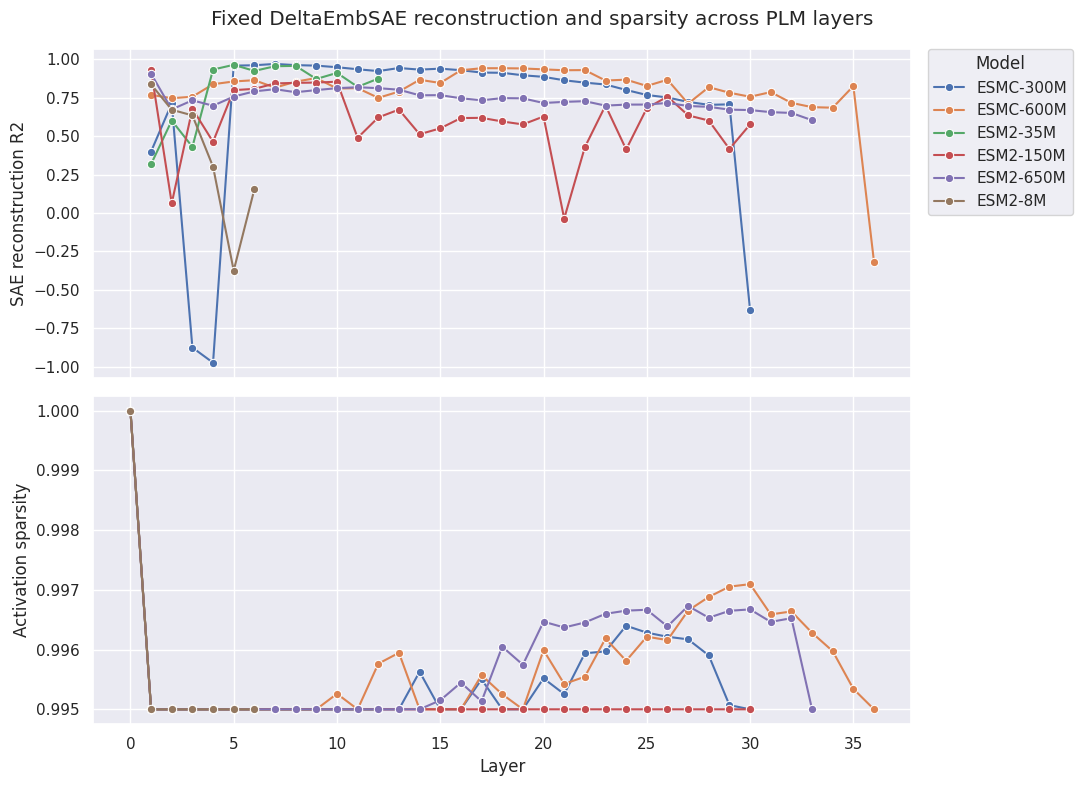

,status,config_idx,run_label,gpu_idx,feature_status,inference_status,elapsed_seconds,method,embedding_type,layer,...,layer_index,model_label,reconstruction_mse,reconstruction_r2,activation_sparsity,activation_density,n_active_features,active_feature_fraction,final_train_loss,final_test_loss
0,ok,0,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,NaN,trained,ran,3262.645,DeltaEmbSAE,max_pool,Layer_0,...,0,ESMC-300M Layer_0 DeltaEmbSAE_max_pool_batchto...,0.000000,NaN,1.000,0.000,12800,1.000000,0.000000e+00,0.000000
1,ok,0,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,NaN,trained,ran,2685.317,DeltaEmbSAE,max_pool,Layer_1,...,1,ESMC-300M Layer_1 DeltaEmbSAE_max_pool_batchto...,0.000038,0.400772,0.995,0.005,11033,0.861953,5.352910e-07,0.000034
2,ok,0,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,NaN,trained,ran,784.144,DeltaEmbSAE,max_pool,Layer_10,...,10,ESMC-300M Layer_10 DeltaEmbSAE_max_pool_batcht...,0.000654,0.949315,0.995,0.005,3764,0.294063,1.013392e-04,0.000658
3,ok,0,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,NaN,trained,ran,893.998,DeltaEmbSAE,max_pool,Layer_11,...,11,ESMC-300M Layer_11 DeltaEmbSAE_max_pool_batcht...,0.000892,0.936002,0.995,0.005,4602,0.359531,2.079056e-04,0.000900
4,ok,0,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,NaN,trained,ran,744.899,DeltaEmbSAE,max_pool,Layer_12,...,12,ESMC-300M Layer_12 DeltaEmbSAE_max_pool_batcht...,0.001365,0.924082,0.995,0.005,2901,0.226641,1.807994e-04,0.001378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,ok,0,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,NaN,trained,ran,462.315,DeltaEmbSAE,max_pool,Layer_2,...,2,ESM2-8M Layer_2 DeltaEmbSAE_max_pool_batchtopk...,0.000079,0.672499,0.995,0.005,3396,0.265313,2.482161e-06,0.000078
149,ok,0,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,NaN,trained,ran,446.898,DeltaEmbSAE,max_pool,Layer_3,...,3,ESM2-8M Layer_3 DeltaEmbSAE_max_pool_batchtopk...,0.000404,0.635778,0.995,0.005,4454,0.347969,1.858138e-05,0.000402
150,ok,0,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,NaN,trained,ran,537.229,DeltaEmbSAE,max_pool,Layer_4,...,4,ESM2-8M Layer_4 DeltaEmbSAE_max_pool_batchtopk...,0.001802,0.301645,0.995,0.005,7488,0.585000,5.300187e-05,0.001783
151,ok,0,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42,NaN,trained,ran,671.367,DeltaEmbSAE,max_pool,Layer_5,...,5,ESM2-8M Layer_5 DeltaEmbSAE_max_pool_batchtopk...,0.005452,-0.374217,0.995,0.005,9721,0.759453,1.120525e-04,0.005414


In [10]:
def _as_existing_path(value):
    if value is None or pd.isna(value):
        return None
    path = Path(value)
    return path if path.is_file() else None


def _load_pickle(path):
    with Path(path).open("rb") as handle:
        return pickle.load(handle)


def _reconstruction_metrics(viz_path):
    viz_path = _as_existing_path(viz_path)
    if viz_path is None:
        return {
            "reconstruction_mse": np.nan,
            "reconstruction_r2": np.nan,
            "activation_sparsity": np.nan,
            "activation_density": np.nan,
            "n_active_features": np.nan,
            "active_feature_fraction": np.nan,
            "final_train_loss": np.nan,
            "final_test_loss": np.nan,
        }
    viz = _load_pickle(viz_path)
    X = np.asarray(viz["X_original"], dtype=float)
    X_recon = np.asarray(viz["X_reconstructed"], dtype=float)
    test_idx = np.asarray(viz.get("test_idx") or [], dtype=int)
    eval_idx = test_idx if len(test_idx) else np.arange(X.shape[0])
    X_eval = X[eval_idx]
    X_recon_eval = X_recon[eval_idx]
    residual = X_eval - X_recon_eval
    mse = float(np.mean(residual ** 2))
    sse = float(np.sum(residual ** 2))
    centered = X_eval - X_eval.mean(axis=0, keepdims=True)
    sst = float(np.sum(centered ** 2))
    r2 = 1.0 - (sse / sst) if sst > 0 else np.nan
    Z_all = np.asarray(viz["Z_all"])
    activation_density = float((Z_all > 0).mean())
    active_mask = np.asarray(viz["active_mask"], dtype=bool)
    train_losses = viz.get("train_losses") or []
    test_losses = viz.get("test_losses") or []
    return {
        "reconstruction_mse": mse,
        "reconstruction_r2": r2,
        "activation_sparsity": 1.0 - activation_density,
        "activation_density": activation_density,
        "n_active_features": int(active_mask.sum()),
        "active_feature_fraction": float(active_mask.mean()),
        "final_train_loss": float(train_losses[-1]) if train_losses else np.nan,
        "final_test_loss": float(test_losses[-1]) if test_losses else np.nan,
    }

result_paths = sorted(SAE_TASK_ROOT.glob("*/Layer_*/sae_sweep_results.csv"))
if not result_paths:
    print(f"No SAE result CSVs found under {SAE_TASK_ROOT}. Run the SAE array first.")
    sae_layer_metrics = pd.DataFrame()
else:
    result_frames = [pd.read_csv(path) for path in result_paths]
    sae_layer_metrics = pd.concat(result_frames, ignore_index=True, sort=False)
    if "layer_index" not in sae_layer_metrics.columns and "layer" in sae_layer_metrics.columns:
        sae_layer_metrics["layer_index"] = sae_layer_metrics["layer"].astype(str).str.replace("Layer_", "", regex=False).astype(int)
    for column in ["n_features", "k", "elapsed_seconds", "feature_count", "feature_dim"]:
        if column in sae_layer_metrics.columns:
            sae_layer_metrics[column] = pd.to_numeric(sae_layer_metrics[column], errors="coerce")
    metric_rows = []
    for _, row in sae_layer_metrics.iterrows():
        metric_rows.append(_reconstruction_metrics(row.get("viz_path")))
    sae_layer_metrics = pd.concat([sae_layer_metrics.reset_index(drop=True), pd.DataFrame(metric_rows)], axis=1)
    sae_layer_metrics.to_csv(TABLE_DIR / "BRCA1_fixed_deltaembsae_layer_metrics.csv", index=False)

    plot_df = sae_layer_metrics[sae_layer_metrics["status"].eq("ok")].copy()
    if not plot_df.empty:
        fig, axes = plt.subplots(2, 1, figsize=(11.0, 8.0), sharex=True)
        sns.lineplot(data=plot_df, x="layer_index", y="reconstruction_r2", hue="model_short", marker="o", linewidth=1.5, ax=axes[0])
        axes[0].set_ylabel("SAE reconstruction R2")
        axes[0].set_xlabel("")
        axes[0].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
        sns.lineplot(data=plot_df, x="layer_index", y="activation_sparsity", hue="model_short", marker="o", linewidth=1.5, ax=axes[1], legend=False)
        axes[1].set_ylabel("Activation sparsity")
        axes[1].set_xlabel("Layer")
        fig.suptitle("Fixed DeltaEmbSAE reconstruction and sparsity across PLM layers")
        fig.tight_layout()
        fig.savefig(FIGURE_DIR / "BRCA1_fixed_deltaembsae_reconstruction_sparsity_by_model_layer.png", dpi=FIGURE_DPI)
        plt.show()

display(sae_layer_metrics)


## ClinVar And Fitness Helpers

These helpers use the cached ClinVar annotations with review-star filters. Pathogenic is treated as the positive class and `-fitness` as the classifier score.


In [11]:
PATHOGENICITY_LABELS = {"benign", "pathogenic"}


def _clinvar_annotation_table():
    if not CLINVAR_ANNOTATION_CACHE_PATH.is_file():
        raise FileNotFoundError(
            f"Missing cached ClinVar annotation table: {CLINVAR_ANNOTATION_CACHE_PATH}. "
            "Run the annotation section of real_data_esm_analysis_cpu_sae.ipynb first."
        )
    annotations = pd.read_csv(CLINVAR_ANNOTATION_CACHE_PATH)
    annotations["SequenceIndex"] = annotations[BRCA1_INPUT.primary_key].astype(str)
    annotations["stars"] = pd.to_numeric(annotations.get("stars", 0), errors="coerce").fillna(0)
    return annotations


def _clinvar_binary_annotation_map(min_review_stars=0):
    annotations = _clinvar_annotation_table()
    keep = annotations["annotation"].isin(PATHOGENICITY_LABELS)
    if min_review_stars > 0:
        keep = keep & annotations["stars"].ge(min_review_stars)
    annotations = annotations[keep].copy()
    return dict(zip(annotations["SequenceIndex"], annotations["annotation"]))


def _classification_metrics_for_fitness(fitness_df):
    binary_df = fitness_df[fitness_df["annotation"].isin(PATHOGENICITY_LABELS)].dropna(subset=["fitness"]).copy()
    if binary_df.empty:
        return {"auc": np.nan, "n_benign": 0, "n_pathogenic": 0, "n_variants": 0}
    labels = binary_df["annotation"].eq("pathogenic").to_numpy()
    scores = -pd.to_numeric(binary_df["fitness"], errors="coerce").to_numpy(dtype=float)
    finite = np.isfinite(scores)
    labels = labels[finite]
    scores = scores[finite]
    n_pos = int(labels.sum())
    n_neg = int((~labels).sum())
    if n_pos == 0 or n_neg == 0:
        auc = np.nan
    else:
        ranks = pd.Series(scores).rank(method="average").to_numpy()
        auc = float((ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))
    return {"auc": auc, "n_benign": int(n_neg), "n_pathogenic": int(n_pos), "n_variants": int(len(labels))}


def _spearman_for_fitness_dataframe(fitness_df, score_col="score"):
    if runner.scores_dataframe is None:
        runner.load_functional_scores()
    score_df = runner.scores_dataframe[["SequenceIndex", score_col]].dropna().copy()
    score_df["SequenceIndex"] = score_df["SequenceIndex"].astype(str)
    comparison_df = fitness_df.merge(score_df, on="SequenceIndex", how="inner")
    fitness = pd.to_numeric(comparison_df["fitness"], errors="coerce").to_numpy(dtype=float)
    scores = pd.to_numeric(comparison_df[score_col], errors="coerce").to_numpy(dtype=float)
    finite = np.isfinite(fitness) & np.isfinite(scores)
    if finite.sum() < 3:
        return np.nan, int(finite.sum())
    rho = spearmanr(fitness[finite], scores[finite]).statistic
    return float(rho), int(finite.sum())


def _fitness_for_feature_mapping(seq_to_features, inference_result, annotation_map, norm_scheme=NORM_SCHEME):
    _, seq_to_features = esmDMS._drop_missing_features(None, seq_to_features, "Fitness scoring")
    esmDMS._require_vector_features(seq_to_features, "Fitness scoring")
    seq_ids = list(seq_to_features)
    features = np.asarray([seq_to_features[seq_id] for seq_id in seq_ids], dtype=float)
    if norm_scheme is not None and norm_scheme != "none":
        features = esmDMS._normalize_features(features, norm_scheme)
    if getattr(inference_result, "s_joint", None) is not None:
        fitness = 1.0 + features @ inference_result.s_joint
    else:
        fitness = 1.0 + np.asarray([features @ inference_result.s[rep_idx] for rep_idx in range(inference_result.s.shape[0])]).mean(axis=0)
    return pd.DataFrame({
        "SequenceIndex": [str(seq_id) for seq_id in seq_ids],
        "fitness": fitness,
        "annotation": [annotation_map.get(str(seq_id)) for seq_id in seq_ids],
    })


def _metrics_row_from_fitness(
    fitness_df,
    annotation_map,
    model_label,
    model_group,
    benchmark,
    method,
    embedding_type,
    model="",
    model_short="",
    layer=np.nan,
    n_features=np.nan,
    k=np.nan,
    feature_path="",
    inference_path="",
    plot_group=None,
):
    if "annotation" not in fitness_df.columns:
        fitness_df = fitness_df.copy()
        fitness_df["annotation"] = fitness_df["SequenceIndex"].astype(str).map(annotation_map)
    spearman_rho, n_score_sequences = _spearman_for_fitness_dataframe(fitness_df)
    auc_metrics = _classification_metrics_for_fitness(fitness_df)
    return {
        "dataset": DATASET_NAME,
        "model": model,
        "model_short": model_short,
        "layer": layer,
        "model_label": model_label,
        "model_group": model_group,
        "benchmark": benchmark,
        "method": method,
        "embedding_type": embedding_type,
        "n_features": n_features,
        "k": k,
        "spearman_rho": spearman_rho,
        "n_score_sequences": n_score_sequences,
        "feature_path": str(feature_path) if feature_path else "",
        "inference_path": str(inference_path) if inference_path else "",
        "method_pool": f"{method} / {embedding_type}",
        "plot_group": plot_group or model_group,
        **auc_metrics,
    }


## Build Benchmark Rows

Raw embedding benchmarks are restricted to `max_pool` and are evaluated by model and layer. Fixed DeltaEmbSAE rows are loaded from the SAE array outputs.


In [12]:
RUN_RAW_MAX_POOL_BENCHMARKS = True
RUN_FIXED_SAE_BENCHMARKS = True
RUN_BASELINE_BENCHMARKS = True
PYTHON_EXECUTABLE = globals().get("PYTHON_EXECUTABLE", "python3")
SCRATCH_ROOT = globals().get("SCRATCH_ROOT", "/scr")
CREATE_BENCHMARK_ANALYSIS_JOB = True
SUBMIT_BENCHMARK_ANALYSIS_JOB = False
COLLECT_BENCHMARK_ANALYSIS_RESULTS = True
GLOBAL_MAX_ACTIVE_BENCHMARK_TASKS = 12
BENCHMARK_ANALYSIS_PARTITION = "any_cpu"
BENCHMARK_ANALYSIS_CPUS_PER_TASK = 4
BENCHMARK_ANALYSIS_MEM = "32G"
BENCHMARK_ANALYSIS_TIME = "06:00:00"
BENCHMARK_ANALYSIS_ROOT = JOB_DIR / "benchmark_row_analysis"
BENCHMARK_ANALYSIS_RESULT_DIR = BENCHMARK_ANALYSIS_ROOT / "results"
BENCHMARK_ANALYSIS_FITNESS_DIR = BENCHMARK_ANALYSIS_ROOT / "fitness"
BENCHMARK_ANALYSIS_LOG_DIR = BENCHMARK_ANALYSIS_ROOT / "logs"
for directory in (BENCHMARK_ANALYSIS_ROOT, BENCHMARK_ANALYSIS_RESULT_DIR, BENCHMARK_ANALYSIS_FITNESS_DIR, BENCHMARK_ANALYSIS_LOG_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def _functional_score_fitness_dataframe(annotation_map, score_col="score"):
    score_df = runner.scores_dataframe[["SequenceIndex", score_col]].dropna().copy()
    score_df["SequenceIndex"] = score_df["SequenceIndex"].astype(str)
    score_df["fitness"] = pd.to_numeric(score_df[score_col], errors="coerce")
    score_df["annotation"] = score_df["SequenceIndex"].map(annotation_map)
    return score_df[["SequenceIndex", "fitness", "annotation"]]


def _enrichment_ratio_fitness_dataframe(annotation_map=None, pseudocount=0.5):
    counts_df = pd.read_csv(BRCA1_INPUT.mavedb_csv_path).copy()
    primary_key = BRCA1_INPUT.primary_key
    counts_df["SequenceIndex"] = counts_df[primary_key].astype(str)
    day_count_cols = []
    for column in counts_df.columns:
        match = re.fullmatch(r"count_day(?P<day>\d+)_rep(?P<rep>\d+)", str(column))
        if match:
            day_count_cols.append((int(match.group("day")), int(match.group("rep")), column))
    if not day_count_cols:
        raise ValueError("No count_day<day>_rep<rep> columns were found for enrichment ratio baseline.")
    final_day = max(day for day, _, _ in day_count_cols)
    final_cols = [(rep, column) for day, rep, column in day_count_cols if day == final_day]
    day0_cols = {rep: column for day, rep, column in day_count_cols if day == 0}
    n_rows = len(counts_df)
    replicate_scores = []
    for rep, final_col in sorted(final_cols):
        initial_col = day0_cols.get(rep, "count_library")
        initial_counts = pd.to_numeric(counts_df[initial_col], errors="coerce").fillna(0.0)
        final_counts = pd.to_numeric(counts_df[final_col], errors="coerce").fillna(0.0)
        initial_freq = (initial_counts + pseudocount) / (initial_counts.sum() + pseudocount * n_rows)
        final_freq = (final_counts + pseudocount) / (final_counts.sum() + pseudocount * n_rows)
        replicate_scores.append(np.log2(final_freq / initial_freq))
    enrichment = pd.concat(replicate_scores, axis=1).mean(axis=1)
    fitness_df = pd.DataFrame({"SequenceIndex": counts_df["SequenceIndex"], "fitness": enrichment})
    if annotation_map is not None:
        fitness_df["annotation"] = fitness_df["SequenceIndex"].map(annotation_map)
    fitness_df.to_csv(ENRICHMENT_RATIO_FITNESS_PATH, index=False)
    return fitness_df


def _regular_popdms_fitness_dataframe(annotation_map):
    if not EXACT_POPDMS_FITNESS_PATH.is_file():
        raise FileNotFoundError(f"Missing exact popDMS fitness table: {EXACT_POPDMS_FITNESS_PATH}")
    fitness_df = pd.read_csv(EXACT_POPDMS_FITNESS_PATH)
    fitness_df["SequenceIndex"] = fitness_df["SequenceIndex"].astype(str)
    fitness_df["annotation"] = fitness_df["SequenceIndex"].map(annotation_map)
    return fitness_df[["SequenceIndex", "fitness", "annotation"]]


def _raw_max_pool_fitness_dataframe(model_name, layer, annotation_map):
    model_runner = make_runner(model_name)
    inference_path = model_runner._inference_path("none", layer, NORM_SCHEME, EMBEDDING_TYPE)
    if not inference_path.is_file():
        raise FileNotFoundError(
            f"Missing raw {EMBEDDING_TYPE} inference results for {model_name} layer {layer}: {inference_path}. "
            "Run the benchmark analysis jobs first."
        )
    return model_runner.fitness_dataframe(
        layer=layer,
        abstraction_method="none",
        abstraction_params={"norm_scheme": NORM_SCHEME},
        embedding_type=EMBEDDING_TYPE,
        norm_scheme=NORM_SCHEME,
    ).assign(annotation=lambda df: df["SequenceIndex"].astype(str).map(annotation_map))


def _fixed_sae_fitness_dataframe(row, annotation_map):
    feature_path = _as_existing_path(row.get("feature_path"))
    inference_path = _as_existing_path(row.get("inference_path"))
    if feature_path is None or inference_path is None:
        raise FileNotFoundError(f"Missing fixed SAE artifacts for {row.get('model_label', 'row')}")
    return _fitness_for_feature_mapping(_load_pickle(feature_path), _load_pickle(inference_path), annotation_map)


def _fixed_sae_metric_source_dataframe():
    metrics_path = TABLE_DIR / "BRCA1_fixed_deltaembsae_layer_metrics.csv"
    if "sae_layer_metrics" in globals() and isinstance(sae_layer_metrics, pd.DataFrame) and not sae_layer_metrics.empty:
        return sae_layer_metrics.copy()
    if metrics_path.is_file():
        return pd.read_csv(metrics_path)
    return pd.DataFrame()


def _build_benchmark_analysis_tasks():
    tasks = []

    def add_task(task):
        task = dict(task)
        task["task_idx"] = len(tasks)
        safe_label = _safe_file_component(task["model_label"])[:96]
        task["result_path"] = str(BENCHMARK_ANALYSIS_RESULT_DIR / f"{task['task_idx']:04d}_{safe_label}.csv")
        task["fitness_path"] = str(BENCHMARK_ANALYSIS_FITNESS_DIR / f"{task['task_idx']:04d}_{safe_label}_fitness.csv")
        tasks.append(task)

    if RUN_BASELINE_BENCHMARKS:
        add_task({
            "task_type": "dms_functional_score",
            "model_label": "DMS functional score",
            "model_group": "benchmark",
            "benchmark": "DMS functional score",
            "method": "DMS functional score",
            "embedding_type": "score",
            "plot_group": "Raw max-pool baseline",
        })
        add_task({
            "task_type": "enrichment_ratio",
            "model_label": "Enrichment ratio",
            "model_group": "Enrichment ratio",
            "benchmark": "Enrichment ratio",
            "method": "enrichment ratio",
            "embedding_type": "day11 / day0 counts",
            "plot_group": "Enrichment ratio",
        })
        if EXACT_POPDMS_FITNESS_PATH.is_file():
            add_task({
                "task_type": "regular_popdms",
                "model_label": "Regular popDMS",
                "model_group": "Regular popDMS",
                "benchmark": "Regular popDMS",
                "method": "regular popDMS",
                "embedding_type": "amino-acid haplotype frequencies",
                "inference_path": str(EXACT_POPDMS_SELECTION_PATH),
                "plot_group": "Regular popDMS",
            })
        else:
            print(f"Skipping regular popDMS baseline: missing {EXACT_POPDMS_FITNESS_PATH}")

    if RUN_RAW_MAX_POOL_BENCHMARKS:
        for model_name in ANALYSIS_MODELS:
            spec = MODEL_SPECS_BY_MODEL[model_name]
            model_runner = make_runner(model_name)
            for layer in spec["layers"]:
                embedding_path = model_runner._embedding_path(layer, EMBEDDING_TYPE)
                if not embedding_path.is_file():
                    continue
                add_task({
                    "task_type": "raw_max_pool",
                    "model": model_name,
                    "model_short": spec["model_short"],
                    "layer": layer,
                    "model_label": f"{spec['model_short']} Layer_{layer} raw max_pool",
                    "model_group": "benchmark",
                    "benchmark": "Raw embeddings",
                    "method": "raw ESM",
                    "embedding_type": EMBEDDING_TYPE,
                    "feature_path": str(embedding_path),
                    "inference_path": str(model_runner._inference_path("none", layer, NORM_SCHEME, EMBEDDING_TYPE)),
                    "plot_group": "Raw max-pool baseline",
                })

    if RUN_FIXED_SAE_BENCHMARKS:
        fixed_metrics_df = _fixed_sae_metric_source_dataframe()
        if fixed_metrics_df.empty:
            print("No fixed SAE metrics found; run and collect the SAE array before plotting fixed SAE points.")
        else:
            fixed_metrics_df = fixed_metrics_df[fixed_metrics_df["status"].eq("ok")].copy()
            for _, row in fixed_metrics_df.iterrows():
                add_task({
                    "task_type": "fixed_deltaembsae",
                    "model": row.get("model", ""),
                    "model_short": row.get("model_short", ""),
                    "layer": row.get("layer_index", np.nan),
                    "model_label": row.get("model_label", f"{row.get('model_short')} Layer_{row.get('layer_index')} fixed DeltaEmbSAE"),
                    "model_group": "Fixed DeltaEmbSAE",
                    "benchmark": "Fixed DeltaEmbSAE",
                    "method": "DeltaEmbSAE",
                    "embedding_type": EMBEDDING_TYPE,
                    "n_features": row.get("n_features", BEST_SAE_PARAMS["n_features"]),
                    "k": row.get("k", BEST_SAE_PARAMS["k"]),
                    "feature_path": row.get("feature_path", ""),
                    "inference_path": row.get("inference_path", ""),
                    "plot_group": "Fixed DeltaEmbSAE",
                })
    return tasks


benchmark_analysis_tasks = _build_benchmark_analysis_tasks()
benchmark_payload_path = BENCHMARK_ANALYSIS_ROOT / "BRCA1_benchmark_row_analysis_payload.pkl"
benchmark_runner_path = BENCHMARK_ANALYSIS_ROOT / "run_benchmark_row_analysis_task.py"
benchmark_script_path = BENCHMARK_ANALYSIS_ROOT / "submit_benchmark_row_analysis_array.sh"
benchmark_analysis_job_id = ""

if CREATE_BENCHMARK_ANALYSIS_JOB and benchmark_analysis_tasks:
    benchmark_payload = {
        "input_data": BRCA1_INPUT,
        "dataset_name": DATASET_NAME,
        "save_dir": str(SEQUENCE_DIR),
        "sequence_dataframe": runner.sequence_dataframe,
        "sequence_to_mutation_sites": runner.sequence_to_mutation_sites,
        "sequence_to_protein_sequence": runner.sequence_to_protein_sequence,
        "sequence_metadata": runner.sequence_metadata,
        "scores_dataframe": runner.scores_dataframe,
        "tasks": benchmark_analysis_tasks,
        "annotation_map": _clinvar_binary_annotation_map(min_review_stars=0),
        "norm_scheme": NORM_SCHEME,
        "embedding_type": EMBEDDING_TYPE,
        "mavedb_csv_path": str(BRCA1_INPUT.mavedb_csv_path),
        "primary_key": BRCA1_INPUT.primary_key,
        "exact_popdms_fitness_path": str(EXACT_POPDMS_FITNESS_PATH),
        "enrichment_ratio_fitness_path": str(ENRICHMENT_RATIO_FITNESS_PATH),
    }
    with benchmark_payload_path.open("wb") as handle:
        pickle.dump(benchmark_payload, handle)

    benchmark_runner_script = r'''
from pathlib import Path
import pickle
import re
import sys

sys.path.insert(0, r"__REPO_ROOT__")

import numpy as np
import pandas as pd
import popDMS  # noqa: F401
from scipy.stats import spearmanr
from esmDMS import ESMDMSConfig, esmDMS

PATHOGENICITY_LABELS = {"benign", "pathogenic"}


def _load_pickle(path):
    with Path(path).open("rb") as handle:
        return pickle.load(handle)


def _save_fitness(fitness_df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    out = fitness_df.copy()
    out["SequenceIndex"] = out["SequenceIndex"].astype(str)
    out.to_csv(path, index=False)


def _classification_metrics_for_fitness(fitness_df):
    binary_df = fitness_df[fitness_df["annotation"].isin(PATHOGENICITY_LABELS)].dropna(subset=["fitness"]).copy()
    if binary_df.empty:
        return {"auc": np.nan, "n_benign": 0, "n_pathogenic": 0, "n_variants": 0}
    labels = binary_df["annotation"].eq("pathogenic").to_numpy()
    scores = -pd.to_numeric(binary_df["fitness"], errors="coerce").to_numpy(dtype=float)
    finite = np.isfinite(scores)
    labels = labels[finite]
    scores = scores[finite]
    n_pos = int(labels.sum())
    n_neg = int((~labels).sum())
    if n_pos == 0 or n_neg == 0:
        auc = np.nan
    else:
        ranks = pd.Series(scores).rank(method="average").to_numpy()
        auc = float((ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))
    return {"auc": auc, "n_benign": int(n_neg), "n_pathogenic": int(n_pos), "n_variants": int(len(labels))}


def _spearman_for_fitness_dataframe(fitness_df, scores_dataframe, score_col="score"):
    score_df = scores_dataframe[["SequenceIndex", score_col]].dropna().copy()
    score_df["SequenceIndex"] = score_df["SequenceIndex"].astype(str)
    comparison_df = fitness_df.merge(score_df, on="SequenceIndex", how="inner")
    fitness = pd.to_numeric(comparison_df["fitness"], errors="coerce").to_numpy(dtype=float)
    scores = pd.to_numeric(comparison_df[score_col], errors="coerce").to_numpy(dtype=float)
    finite = np.isfinite(fitness) & np.isfinite(scores)
    if finite.sum() < 3:
        return np.nan, int(finite.sum())
    rho = spearmanr(fitness[finite], scores[finite]).statistic
    return float(rho), int(finite.sum())


def _metrics_row_from_fitness(fitness_df, payload, task):
    spearman_rho, n_score_sequences = _spearman_for_fitness_dataframe(fitness_df, payload["scores_dataframe"])
    auc_metrics = _classification_metrics_for_fitness(fitness_df)
    return {
        "dataset": payload["dataset_name"],
        "model": task.get("model", ""),
        "model_short": task.get("model_short", ""),
        "layer": task.get("layer", np.nan),
        "model_label": task["model_label"],
        "model_group": task["model_group"],
        "benchmark": task["benchmark"],
        "method": task["method"],
        "embedding_type": task["embedding_type"],
        "n_features": task.get("n_features", np.nan),
        "k": task.get("k", np.nan),
        "spearman_rho": spearman_rho,
        "n_score_sequences": n_score_sequences,
        "feature_path": str(task.get("feature_path", "") or ""),
        "inference_path": str(task.get("inference_path", "") or ""),
        "fitness_path": str(task["fitness_path"]),
        "method_pool": f"{task['method']} / {task['embedding_type']}",
        "plot_group": task.get("plot_group") or task["model_group"],
        **auc_metrics,
    }


def _functional_score_fitness_dataframe(payload, score_col="score"):
    score_df = payload["scores_dataframe"][["SequenceIndex", score_col]].dropna().copy()
    score_df["SequenceIndex"] = score_df["SequenceIndex"].astype(str)
    score_df["fitness"] = pd.to_numeric(score_df[score_col], errors="coerce")
    score_df["annotation"] = score_df["SequenceIndex"].map(payload["annotation_map"])
    return score_df[["SequenceIndex", "fitness", "annotation"]]


def _enrichment_ratio_fitness_dataframe(payload, pseudocount=0.5):
    counts_df = pd.read_csv(payload["mavedb_csv_path"]).copy()
    counts_df["SequenceIndex"] = counts_df[payload["primary_key"]].astype(str)
    day_count_cols = []
    for column in counts_df.columns:
        match = re.fullmatch(r"count_day(?P<day>\d+)_rep(?P<rep>\d+)", str(column))
        if match:
            day_count_cols.append((int(match.group("day")), int(match.group("rep")), column))
    if not day_count_cols:
        raise ValueError("No count_day<day>_rep<rep> columns were found for enrichment ratio baseline.")
    final_day = max(day for day, _, _ in day_count_cols)
    final_cols = [(rep, column) for day, rep, column in day_count_cols if day == final_day]
    day0_cols = {rep: column for day, rep, column in day_count_cols if day == 0}
    n_rows = len(counts_df)
    replicate_scores = []
    for rep, final_col in sorted(final_cols):
        initial_col = day0_cols.get(rep, "count_library")
        initial_counts = pd.to_numeric(counts_df[initial_col], errors="coerce").fillna(0.0)
        final_counts = pd.to_numeric(counts_df[final_col], errors="coerce").fillna(0.0)
        initial_freq = (initial_counts + pseudocount) / (initial_counts.sum() + pseudocount * n_rows)
        final_freq = (final_counts + pseudocount) / (final_counts.sum() + pseudocount * n_rows)
        replicate_scores.append(np.log2(final_freq / initial_freq))
    enrichment = pd.concat(replicate_scores, axis=1).mean(axis=1)
    fitness_df = pd.DataFrame({"SequenceIndex": counts_df["SequenceIndex"], "fitness": enrichment})
    fitness_df["annotation"] = fitness_df["SequenceIndex"].map(payload["annotation_map"])
    return fitness_df


def _regular_popdms_fitness_dataframe(payload):
    fitness_df = pd.read_csv(payload["exact_popdms_fitness_path"])
    fitness_df["SequenceIndex"] = fitness_df["SequenceIndex"].astype(str)
    fitness_df["annotation"] = fitness_df["SequenceIndex"].map(payload["annotation_map"])
    return fitness_df[["SequenceIndex", "fitness", "annotation"]]


def _make_runner(payload, model_name):
    config = ESMDMSConfig(
        embedding_model=model_name,
        embedding_type=payload["embedding_type"],
        local_or_disk="both",
        save_dir=payload["save_dir"],
        dataset_name=payload["dataset_name"],
    )
    runner = esmDMS(payload["input_data"], config)
    runner.sequence_dataframe = payload["sequence_dataframe"]
    runner.sequence_to_mutation_sites = payload["sequence_to_mutation_sites"]
    runner.sequence_to_protein_sequence = payload["sequence_to_protein_sequence"]
    runner.sequence_metadata = payload["sequence_metadata"]
    runner.scores_dataframe = payload["scores_dataframe"]
    return runner


def _raw_max_pool_fitness_dataframe(payload, task):
    runner = _make_runner(payload, task["model"])
    layer = int(task["layer"])
    inference_path = Path(task["inference_path"])
    if not inference_path.is_file():
        runner.run_feature_inference(
            layer=layer,
            abstraction_method="none",
            abstraction_params={"norm_scheme": payload["norm_scheme"]},
            embedding_type=payload["embedding_type"],
        )
    return runner.fitness_dataframe(
        layer=layer,
        abstraction_method="none",
        abstraction_params={"norm_scheme": payload["norm_scheme"]},
        embedding_type=payload["embedding_type"],
        norm_scheme=payload["norm_scheme"],
    ).assign(annotation=lambda df: df["SequenceIndex"].astype(str).map(payload["annotation_map"]))


def _fitness_for_feature_mapping(seq_to_features, inference_result, annotation_map, norm_scheme="none"):
    _, seq_to_features = esmDMS._drop_missing_features(None, seq_to_features, "Fitness scoring")
    esmDMS._require_vector_features(seq_to_features, "Fitness scoring")
    seq_ids = list(seq_to_features)
    features = np.asarray([seq_to_features[seq_id] for seq_id in seq_ids], dtype=float)
    if norm_scheme is not None and norm_scheme != "none":
        features = esmDMS._normalize_features(features, norm_scheme)
    if getattr(inference_result, "s_joint", None) is not None:
        fitness = 1.0 + features @ inference_result.s_joint
    else:
        fitness = 1.0 + np.asarray([features @ inference_result.s[rep_idx] for rep_idx in range(inference_result.s.shape[0])]).mean(axis=0)
    return pd.DataFrame({
        "SequenceIndex": [str(seq_id) for seq_id in seq_ids],
        "fitness": fitness,
        "annotation": [annotation_map.get(str(seq_id)) for seq_id in seq_ids],
    })


def _fixed_sae_fitness_dataframe(payload, task):
    return _fitness_for_feature_mapping(
        _load_pickle(task["feature_path"]),
        _load_pickle(task["inference_path"]),
        payload["annotation_map"],
        payload["norm_scheme"],
    )


def _fitness_for_task(payload, task):
    task_type = task["task_type"]
    if task_type == "dms_functional_score":
        return _functional_score_fitness_dataframe(payload)
    if task_type == "enrichment_ratio":
        return _enrichment_ratio_fitness_dataframe(payload)
    if task_type == "regular_popdms":
        return _regular_popdms_fitness_dataframe(payload)
    if task_type == "raw_max_pool":
        return _raw_max_pool_fitness_dataframe(payload, task)
    if task_type == "fixed_deltaembsae":
        return _fixed_sae_fitness_dataframe(payload, task)
    raise ValueError(f"Unsupported benchmark task type: {task_type}")


def main(payload_path, task_idx):
    with Path(payload_path).open("rb") as handle:
        payload = pickle.load(handle)
    task = payload["tasks"][task_idx]
    fitness_df = _fitness_for_task(payload, task)
    _save_fitness(fitness_df, task["fitness_path"])
    result = _metrics_row_from_fitness(fitness_df, payload, task)
    result_path = Path(task["result_path"])
    result_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame([result]).to_csv(result_path, index=False)
    print(f"Wrote benchmark row: {result_path}")


if __name__ == "__main__":
    main(Path(sys.argv[1]), int(sys.argv[2]))
'''.replace("__REPO_ROOT__", str(REPO_ROOT))
    benchmark_runner_path.write_text(benchmark_runner_script)
    benchmark_runner_path.chmod(0o755)

    array_spec = f"0-{len(benchmark_analysis_tasks) - 1}%{GLOBAL_MAX_ACTIVE_BENCHMARK_TASKS}"
    benchmark_slurm_script = f'''#!/bin/bash
#SBATCH --job-name=brca1_benchmark_rows
#SBATCH -p {BENCHMARK_ANALYSIS_PARTITION}
#SBATCH --cpus-per-task={BENCHMARK_ANALYSIS_CPUS_PER_TASK}
#SBATCH --time={BENCHMARK_ANALYSIS_TIME}
#SBATCH --mem={BENCHMARK_ANALYSIS_MEM}
#SBATCH --array={array_spec}
#SBATCH --output={BENCHMARK_ANALYSIS_LOG_DIR}/slurm-%A_%a.out
#SBATCH --error={BENCHMARK_ANALYSIS_LOG_DIR}/slurm-%A_%a.err

set -euo pipefail
cd {REPO_ROOT}
mkdir -p {BENCHMARK_ANALYSIS_LOG_DIR}

SCRDIR={SCRATCH_ROOT}/${{SLURM_JOB_ID}}_${{SLURM_ARRAY_TASK_ID}}_benchmark_rows
mkdir -p "$SCRDIR"
export TMPDIR="$SCRDIR"
export MPLCONFIGDIR="$SCRDIR/mplconfig"
export OMP_NUM_THREADS={BENCHMARK_ANALYSIS_CPUS_PER_TASK}
export MKL_NUM_THREADS={BENCHMARK_ANALYSIS_CPUS_PER_TASK}
export NUMEXPR_NUM_THREADS={BENCHMARK_ANALYSIS_CPUS_PER_TASK}
mkdir -p "$MPLCONFIGDIR"

{PYTHON_EXECUTABLE} {benchmark_runner_path} {benchmark_payload_path} $SLURM_ARRAY_TASK_ID
'''
    benchmark_script_path.write_text(benchmark_slurm_script)
    benchmark_script_path.chmod(0o755)

    if SUBMIT_BENCHMARK_ANALYSIS_JOB:
        completed = subprocess.run(["sbatch", str(benchmark_script_path)], check=True, capture_output=True, text=True)
        benchmark_analysis_job_id = completed.stdout.strip()

benchmark_task_df = pd.DataFrame(benchmark_analysis_tasks)
benchmark_task_df.to_csv(TABLE_DIR / "BRCA1_benchmark_row_analysis_tasks.csv", index=False)
print(f"Benchmark analysis tasks: {len(benchmark_analysis_tasks)}")
if benchmark_analysis_tasks:
    print(f"Array script: {benchmark_script_path}")
    print(f"Array spec: 0-{len(benchmark_analysis_tasks)-1}%{GLOBAL_MAX_ACTIVE_BENCHMARK_TASKS}")
    print(f"Submitted: {SUBMIT_BENCHMARK_ANALYSIS_JOB} {benchmark_analysis_job_id}")

def _collect_benchmark_analysis_results():
    expected_paths = [Path(task["result_path"]) for task in benchmark_analysis_tasks]
    result_paths = [path for path in expected_paths if path.is_file()]
    if result_paths:
        missing_count = len(expected_paths) - len(result_paths)
        if missing_count:
            print(f"Collected {len(result_paths)} of {len(expected_paths)} benchmark result CSVs; {missing_count} task(s) are still missing.")
        return pd.concat([pd.read_csv(path) for path in result_paths], ignore_index=True, sort=False)
    if SPEARMAN_AUC_TABLE_PATH.is_file():
        print(f"No per-task benchmark result CSVs found; loading existing table {SPEARMAN_AUC_TABLE_PATH}.")
        return pd.read_csv(SPEARMAN_AUC_TABLE_PATH)
    print(f"No benchmark result CSVs found under {BENCHMARK_ANALYSIS_RESULT_DIR}. Run the benchmark analysis array first.")
    return pd.DataFrame()

spearman_auc_df = _collect_benchmark_analysis_results() if COLLECT_BENCHMARK_ANALYSIS_RESULTS else pd.DataFrame()
if not spearman_auc_df.empty:
    spearman_auc_df.to_csv(SPEARMAN_AUC_TABLE_PATH, index=False)
    display(spearman_auc_df.sort_values(["plot_group", "auc", "spearman_rho"], ascending=[True, False, False]))
else:
    display(benchmark_task_df.head())


Benchmark analysis tasks: 309
Array script: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/benchmark_row_analysis/submit_benchmark_row_analysis_array.sh
Array spec: 0-308%12
Submitted: False 


,dataset,model,model_short,layer,model_label,model_group,benchmark,method,embedding_type,n_features,...,n_score_sequences,feature_path,inference_path,fitness_path,method_pool,plot_group,auc,n_benign,n_pathogenic,n_variants
1,BRCA1,NaN,NaN,NaN,Enrichment ratio,Enrichment ratio,Enrichment ratio,enrichment ratio,day11 / day0 counts,NaN,...,3893,NaN,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,enrichment ratio / day11 / day0 counts,Enrichment ratio,0.919791,598,460,1058
217,BRCA1,biohub/ESMC-600M,ESMC-600M,36.0,ESMC-600M Layer_36 DeltaEmbSAE_max_pool_batcht...,Fixed DeltaEmbSAE,Fixed DeltaEmbSAE,DeltaEmbSAE,max_pool,12800.0,...,2104,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,DeltaEmbSAE / max_pool,Fixed DeltaEmbSAE,0.961201,338,158,496
180,BRCA1,biohub/ESMC-300M,ESMC-300M,30.0,ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batcht...,Fixed DeltaEmbSAE,Fixed DeltaEmbSAE,DeltaEmbSAE,max_pool,12800.0,...,2104,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,DeltaEmbSAE / max_pool,Fixed DeltaEmbSAE,0.951567,338,158,496
178,BRCA1,biohub/ESMC-300M,ESMC-300M,29.0,ESMC-300M Layer_29 DeltaEmbSAE_max_pool_batcht...,Fixed DeltaEmbSAE,Fixed DeltaEmbSAE,DeltaEmbSAE,max_pool,12800.0,...,2104,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,DeltaEmbSAE / max_pool,Fixed DeltaEmbSAE,0.946839,338,158,496
231,BRCA1,facebook/esm2_t12_35M_UR50D,ESM2-35M,4.0,ESM2-35M Layer_4 DeltaEmbSAE_max_pool_batchtop...,Fixed DeltaEmbSAE,Fixed DeltaEmbSAE,DeltaEmbSAE,max_pool,12800.0,...,2104,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,DeltaEmbSAE / max_pool,Fixed DeltaEmbSAE,0.943281,338,158,496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23,BRCA1,facebook/esm2_t30_150M_UR50D,ESM2-150M,0.0,ESM2-150M Layer_0 raw max_pool,benchmark,Raw embeddings,raw ESM,max_pool,NaN,...,2104,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,raw ESM / max_pool,Raw max-pool baseline,0.500000,338,158,496
54,BRCA1,facebook/esm2_t33_650M_UR50D,ESM2-650M,0.0,ESM2-650M Layer_0 raw max_pool,benchmark,Raw embeddings,raw ESM,max_pool,NaN,...,2104,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,raw ESM / max_pool,Raw max-pool baseline,0.500000,338,158,496
88,BRCA1,biohub/ESMC-300M,ESMC-300M,0.0,ESMC-300M Layer_0 raw max_pool,benchmark,Raw embeddings,raw ESM,max_pool,NaN,...,2104,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,raw ESM / max_pool,Raw max-pool baseline,0.500000,338,158,496
119,BRCA1,biohub/ESMC-600M,ESMC-600M,0.0,ESMC-600M Layer_0 raw max_pool,benchmark,Raw embeddings,raw ESM,max_pool,NaN,...,2104,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,raw ESM / max_pool,Raw max-pool baseline,0.500000,338,158,496


## Functional Score Agreement Vs ClinVar Classification

This reproduces the MaveDB Spearman-vs-ClinVar AUC plot and repeats it for ClinVar review-star thresholds.


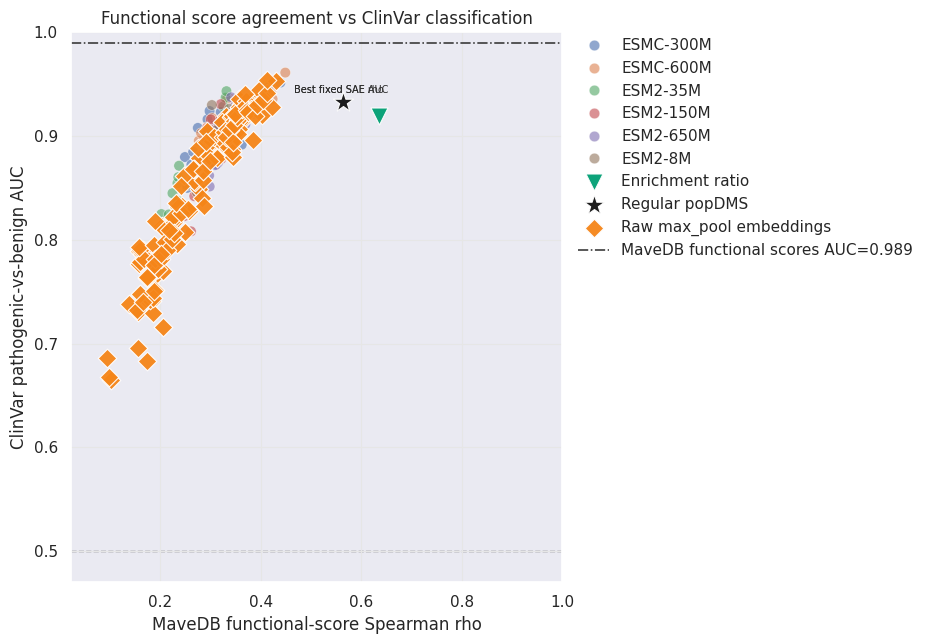

,review_filter,best_raw_max_pool_auc,best_fixed_sae_auc,mavedb_functional_auc,popdms_auc,n_benign_annotations,n_pathogenic_annotations
0,all binary annotations,0.954,0.961,0.989,0.933,598,460


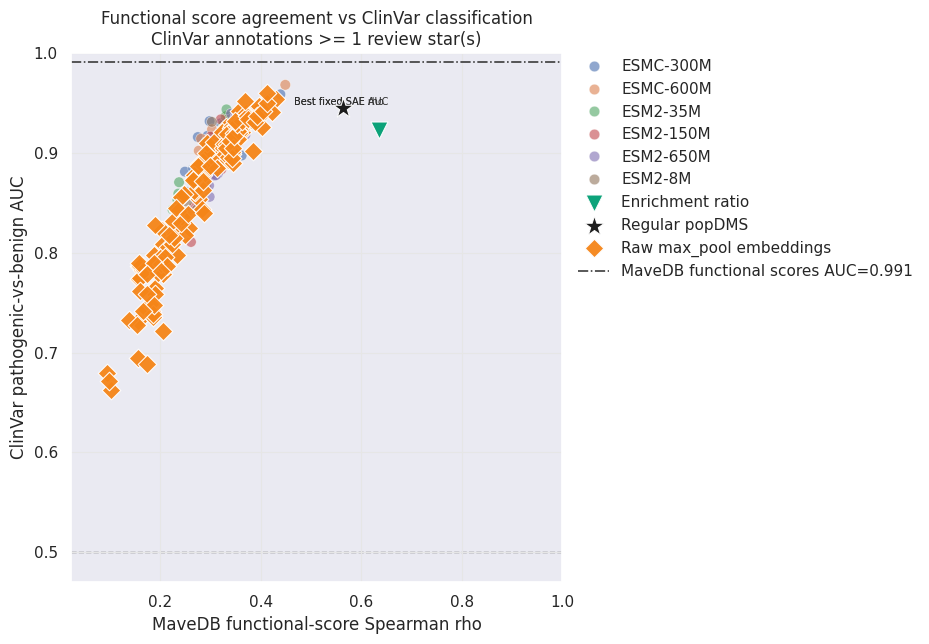

,review_filter,best_raw_max_pool_auc,best_fixed_sae_auc,mavedb_functional_auc,popdms_auc,n_benign_annotations,n_pathogenic_annotations
0,>= 1 star(s),0.96,0.968,0.991,0.945,595,452


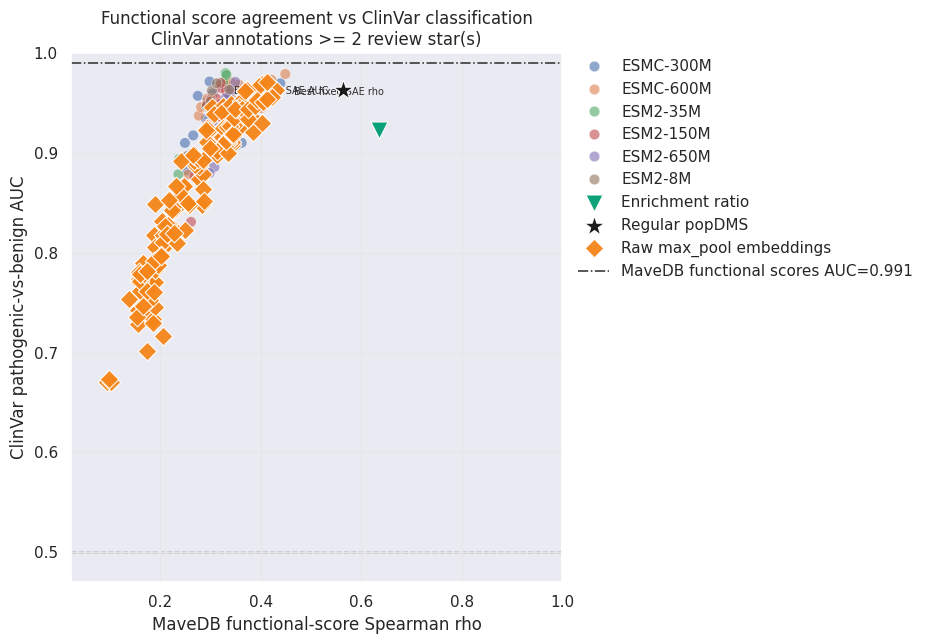

,review_filter,best_raw_max_pool_auc,best_fixed_sae_auc,mavedb_functional_auc,popdms_auc,n_benign_annotations,n_pathogenic_annotations
0,>= 2 star(s),0.971,0.98,0.991,0.963,286,348


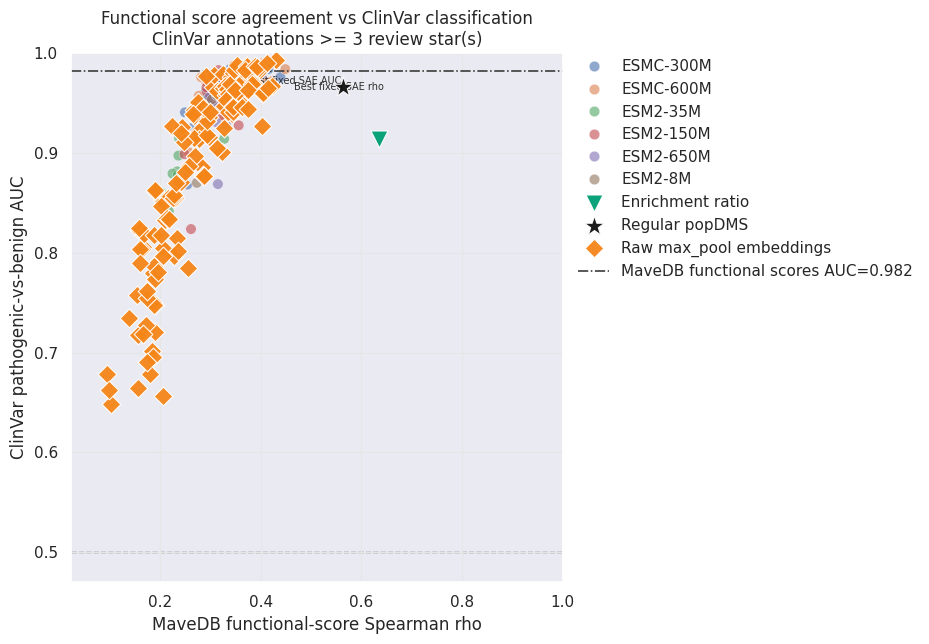

,review_filter,best_raw_max_pool_auc,best_fixed_sae_auc,mavedb_functional_auc,popdms_auc,n_benign_annotations,n_pathogenic_annotations
0,>= 3 star(s),0.993,0.99,0.982,0.966,107,159


No finite Spearman/AUC pairs were available to plot.


,dataset,model,model_short,layer,model_label,model_group,benchmark,method,embedding_type,n_features,...,feature_path,inference_path,fitness_path,method_pool,plot_group,auc,n_benign,n_pathogenic,n_variants,min_review_stars
1,BRCA1,NaN,NaN,NaN,Enrichment ratio,Enrichment ratio,Enrichment ratio,enrichment ratio,day11 / day0 counts,NaN,...,NaN,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,enrichment ratio / day11 / day0 counts,Enrichment ratio,0.922905,595,452,1047,1
217,BRCA1,biohub/ESMC-600M,ESMC-600M,36.0,ESMC-600M Layer_36 DeltaEmbSAE_max_pool_batcht...,Fixed DeltaEmbSAE,Fixed DeltaEmbSAE,DeltaEmbSAE,max_pool,12800.0,...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,DeltaEmbSAE / max_pool,Fixed DeltaEmbSAE,0.968245,337,154,491,1
180,BRCA1,biohub/ESMC-300M,ESMC-300M,30.0,ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batcht...,Fixed DeltaEmbSAE,Fixed DeltaEmbSAE,DeltaEmbSAE,max_pool,12800.0,...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,DeltaEmbSAE / max_pool,Fixed DeltaEmbSAE,0.958736,337,154,491,1
178,BRCA1,biohub/ESMC-300M,ESMC-300M,29.0,ESMC-300M Layer_29 DeltaEmbSAE_max_pool_batcht...,Fixed DeltaEmbSAE,Fixed DeltaEmbSAE,DeltaEmbSAE,max_pool,12800.0,...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,DeltaEmbSAE / max_pool,Fixed DeltaEmbSAE,0.954025,337,154,491,1
213,BRCA1,biohub/ESMC-600M,ESMC-600M,32.0,ESMC-600M Layer_32 DeltaEmbSAE_max_pool_batcht...,Fixed DeltaEmbSAE,Fixed DeltaEmbSAE,DeltaEmbSAE,max_pool,12800.0,...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,DeltaEmbSAE / max_pool,Fixed DeltaEmbSAE,0.949940,337,154,491,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,BRCA1,facebook/esm2_t30_150M_UR50D,ESM2-150M,0.0,ESM2-150M Layer_0 raw max_pool,benchmark,Raw embeddings,raw ESM,max_pool,NaN,...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,raw ESM / max_pool,Raw max-pool baseline,NaN,0,0,0,4
981,BRCA1,facebook/esm2_t33_650M_UR50D,ESM2-650M,0.0,ESM2-650M Layer_0 raw max_pool,benchmark,Raw embeddings,raw ESM,max_pool,NaN,...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,raw ESM / max_pool,Raw max-pool baseline,NaN,0,0,0,4
1015,BRCA1,biohub/ESMC-300M,ESMC-300M,0.0,ESMC-300M Layer_0 raw max_pool,benchmark,Raw embeddings,raw ESM,max_pool,NaN,...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,raw ESM / max_pool,Raw max-pool baseline,NaN,0,0,0,4
1046,BRCA1,biohub/ESMC-600M,ESMC-600M,0.0,ESMC-600M Layer_0 raw max_pool,benchmark,Raw embeddings,raw ESM,max_pool,NaN,...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,raw ESM / max_pool,Raw max-pool baseline,NaN,0,0,0,4


In [13]:
def _fitness_dataframe_for_metrics_row(row, annotation_map):
    fitness_path = _as_existing_path(row.get("fitness_path", ""))
    if fitness_path is not None:
        fitness_df = pd.read_csv(fitness_path)
        fitness_df["SequenceIndex"] = fitness_df["SequenceIndex"].astype(str)
        fitness_df["annotation"] = fitness_df["SequenceIndex"].map(annotation_map)
        return fitness_df

    benchmark = row.get("benchmark", "")
    if benchmark == "DMS functional score":
        return _functional_score_fitness_dataframe(annotation_map, score_col="score")
    if benchmark == "Enrichment ratio":
        return _enrichment_ratio_fitness_dataframe(annotation_map)
    if benchmark == "Regular popDMS":
        return _regular_popdms_fitness_dataframe(annotation_map)
    if benchmark == "Raw embeddings":
        return _raw_max_pool_fitness_dataframe(row["model"], int(row["layer"]), annotation_map)
    if benchmark == "Fixed DeltaEmbSAE":
        return _fixed_sae_fitness_dataframe(row, annotation_map)
    raise ValueError(f"Unsupported benchmark row: {benchmark}")


def _recompute_auc_for_annotation_map(base_metrics_df, annotation_map):
    rows = []
    for _, row in base_metrics_df.iterrows():
        try:
            fitness_df = _fitness_dataframe_for_metrics_row(row, annotation_map)
        except Exception as exc:
            print(f"Skipping {row.get('model_label', 'model')} for star-filtered AUC: {exc}")
            continue
        row_dict = row.to_dict()
        row_dict.update(_classification_metrics_for_fitness(fitness_df))
        rows.append(row_dict)
    return pd.DataFrame(rows)


def _plot_mavedb_spearman_vs_clinvar_auc(comparison_df, output_path, functional_score_auc=np.nan, title_suffix=""):
    plot_df = comparison_df[np.isfinite(comparison_df["spearman_rho"]) & np.isfinite(comparison_df["auc"])].copy()
    if plot_df.empty:
        print("No finite Spearman/AUC pairs were available to plot.")
        return None
    fig, ax = plt.subplots(figsize=(9.5, 6.6))
    fixed_df = plot_df[plot_df["plot_group"].eq("Fixed DeltaEmbSAE")].copy()
    if not fixed_df.empty:
        sns.scatterplot(data=fixed_df, x="spearman_rho", y="auc", hue="model_short", s=58, alpha=0.62, edgecolor="white", linewidth=0.45, ax=ax)
        best_auc_row = fixed_df.loc[fixed_df["auc"].idxmax()]
        best_rho_row = fixed_df.loc[fixed_df["spearman_rho"].idxmax()]
        for label, row in [("Best fixed SAE AUC", best_auc_row), ("Best fixed SAE rho", best_rho_row)]:
            ax.annotate(label, (row["spearman_rho"], row["auc"]), xytext=(6, -9), textcoords="offset points", fontsize=7, ha="left", va="top", color="0.18")

    marker_specs = {
        "Raw embeddings": {"marker": "D", "size": 90, "color": "#f58518", "label": "Raw max_pool embeddings"},
        "Regular popDMS": {"marker": "*", "size": 230, "color": "#111111", "label": "Regular popDMS"},
        "Enrichment ratio": {"marker": "v", "size": 150, "color": "#009e73", "label": "Enrichment ratio"},
    }
    baseline_df = plot_df[~plot_df["plot_group"].eq("Fixed DeltaEmbSAE") & ~plot_df["benchmark"].eq("DMS functional score")].copy()
    for benchmark, group_df in baseline_df.groupby("benchmark", sort=False):
        spec = marker_specs.get(benchmark, {"marker": "o", "size": 90, "color": "0.5", "label": benchmark})
        ax.scatter(group_df["spearman_rho"], group_df["auc"], s=spec["size"], marker=spec["marker"], color=spec["color"], alpha=0.95, edgecolors="white", linewidths=0.8, label=spec["label"], zorder=5)

    if np.isfinite(functional_score_auc):
        ax.axhline(functional_score_auc, color="0.20", linestyle="-.", linewidth=1.15, label=f"MaveDB functional scores AUC={functional_score_auc:.3f}", zorder=1)
    ax.axhline(0.5, color="0.35", linestyle="--", linewidth=1.0, zorder=0)
    ax.axvline(0.0, color="0.72", linestyle=":", linewidth=1.0, zorder=0)
    x_values = plot_df["spearman_rho"].to_numpy(dtype=float)
    y_values = plot_df["auc"].to_numpy(dtype=float)
    if np.isfinite(functional_score_auc):
        y_values = np.append(y_values, functional_score_auc)
    x_pad = max(0.025, 0.08 * (np.nanmax(x_values) - np.nanmin(x_values)))
    y_pad = max(0.025, 0.08 * (np.nanmax(y_values) - np.nanmin(y_values)))
    ax.set_xlim(max(-1.0, np.nanmin(x_values) - x_pad), min(1.0, np.nanmax(x_values) + x_pad))
    ax.set_ylim(max(0.0, min(np.nanmin(y_values) - y_pad, 0.47)), min(1.0, max(np.nanmax(y_values) + y_pad, 0.53)))
    ax.set_xlabel("MaveDB functional-score Spearman rho")
    ax.set_ylabel("ClinVar pathogenic-vs-benign AUC")
    title = "Functional score agreement vs ClinVar classification"
    if title_suffix:
        title = f"{title}\n{title_suffix}"
    ax.set_title(title)
    ax.grid(axis="both", color="0.90", linewidth=0.8)
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    unique = []
    for handle, label in zip(handles, labels):
        if label not in seen:
            seen.add(label)
            unique.append((handle, label))
    if unique:
        ax.legend([handle for handle, _ in unique], [label for _, label in unique], bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, borderaxespad=0)
    fig.tight_layout()
    fig.savefig(output_path, dpi=FIGURE_DPI)
    return fig


def _clinvar_agreement_summary_table(metrics_df, functional_score_auc_metrics, min_review_stars=None):
    def best_auc(mask):
        values = pd.to_numeric(metrics_df.loc[mask, "auc"], errors="coerce")
        values = values[np.isfinite(values)]
        return np.nan if values.empty else float(values.max())
    summary = pd.DataFrame([{
        "review_filter": "all binary annotations" if min_review_stars is None else f">= {min_review_stars} star(s)",
        "best_raw_max_pool_auc": best_auc(metrics_df["benchmark"].eq("Raw embeddings")),
        "best_fixed_sae_auc": best_auc(metrics_df["plot_group"].eq("Fixed DeltaEmbSAE")),
        "mavedb_functional_auc": functional_score_auc_metrics.get("auc", np.nan),
        "popdms_auc": best_auc(metrics_df["benchmark"].eq("Regular popDMS")),
        "n_benign_annotations": int(functional_score_auc_metrics.get("n_benign", 0) or 0),
        "n_pathogenic_annotations": int(functional_score_auc_metrics.get("n_pathogenic", 0) or 0),
    }])
    for column in ["best_raw_max_pool_auc", "best_fixed_sae_auc", "mavedb_functional_auc", "popdms_auc"]:
        summary[column] = pd.to_numeric(summary[column], errors="coerce").round(3)
    return summary

annotation_map = _clinvar_binary_annotation_map(min_review_stars=0)
functional_score_auc_metrics = _classification_metrics_for_fitness(_functional_score_fitness_dataframe(annotation_map))
if "spearman_auc_df" not in globals() or spearman_auc_df.empty:
    if SPEARMAN_AUC_TABLE_PATH.is_file():
        spearman_auc_df = pd.read_csv(SPEARMAN_AUC_TABLE_PATH)
    else:
        spearman_auc_df = pd.DataFrame()
        print("No benchmark metrics table found. Run and collect the benchmark analysis jobs before plotting.")

if not spearman_auc_df.empty:
    spearman_auc_df.to_csv(SPEARMAN_AUC_TABLE_PATH, index=False)

    fig = _plot_mavedb_spearman_vs_clinvar_auc(spearman_auc_df, SPEARMAN_AUC_FIGURE_PATH, functional_score_auc=functional_score_auc_metrics["auc"])
    if fig is not None:
        plt.show()
        display(_clinvar_agreement_summary_table(spearman_auc_df, functional_score_auc_metrics, min_review_stars=None))

    star_threshold_frames = []
    for min_review_stars in CLINVAR_REVIEW_STAR_THRESHOLDS:
        threshold_annotation_map = _clinvar_binary_annotation_map(min_review_stars)
        threshold_metrics_df = _recompute_auc_for_annotation_map(spearman_auc_df, threshold_annotation_map)
        if threshold_metrics_df.empty:
            print(f"No models could be plotted for ClinVar annotations >= {min_review_stars} star(s).")
            continue
        threshold_metrics_df["min_review_stars"] = min_review_stars
        threshold_metrics_df.to_csv(TABLE_DIR / SPEARMAN_AUC_STAR_TABLE_TEMPLATE.format(stars=min_review_stars), index=False)
        threshold_functional_score_auc = _classification_metrics_for_fitness(_functional_score_fitness_dataframe(threshold_annotation_map))
        threshold_fig = _plot_mavedb_spearman_vs_clinvar_auc(
            threshold_metrics_df,
            FIGURE_DIR / SPEARMAN_AUC_STAR_FIGURE_TEMPLATE.format(stars=min_review_stars),
            functional_score_auc=threshold_functional_score_auc["auc"],
            title_suffix=f"ClinVar annotations >= {min_review_stars} review star(s)",
        )
        if threshold_fig is not None:
            plt.show()
            display(_clinvar_agreement_summary_table(threshold_metrics_df, threshold_functional_score_auc, min_review_stars=min_review_stars))
        star_threshold_frames.append(threshold_metrics_df)

    if star_threshold_frames:
        spearman_auc_by_review_stars_df = pd.concat(star_threshold_frames, ignore_index=True, sort=False)
        spearman_auc_by_review_stars_df.to_csv(SPEARMAN_AUC_STAR_COMBINED_TABLE_PATH, index=False)
        display(spearman_auc_by_review_stars_df.sort_values(["min_review_stars", "plot_group", "auc", "spearman_rho"], ascending=[True, True, False, False]))


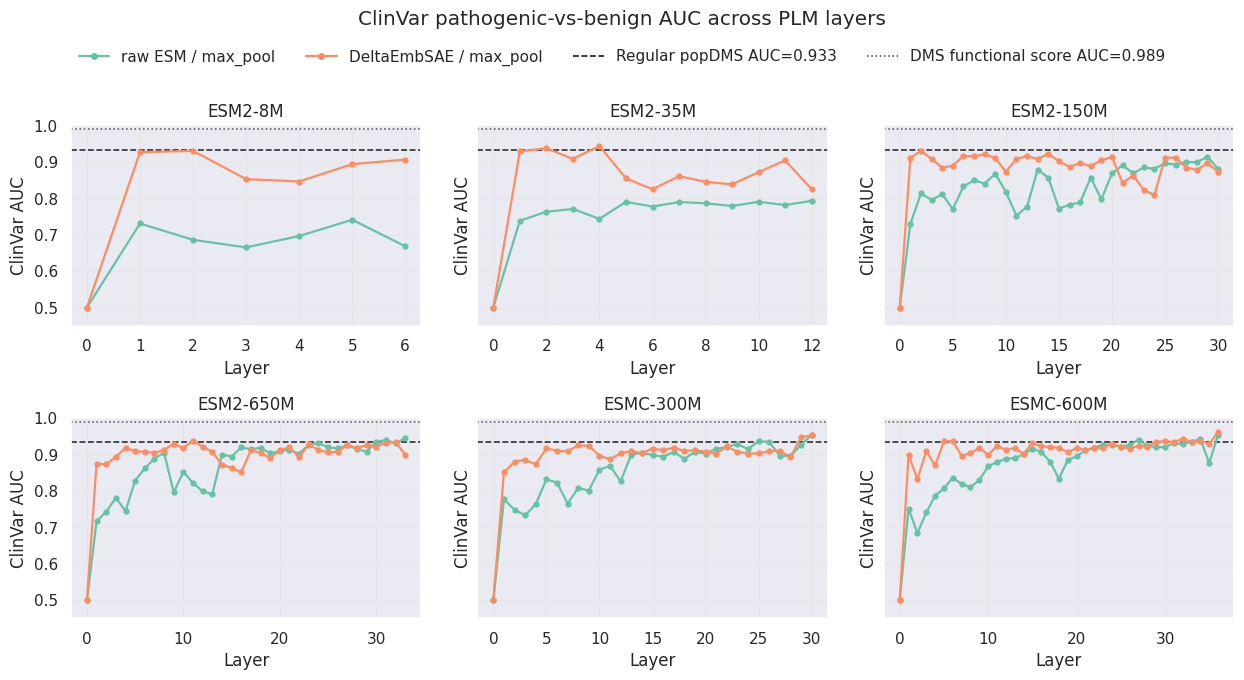

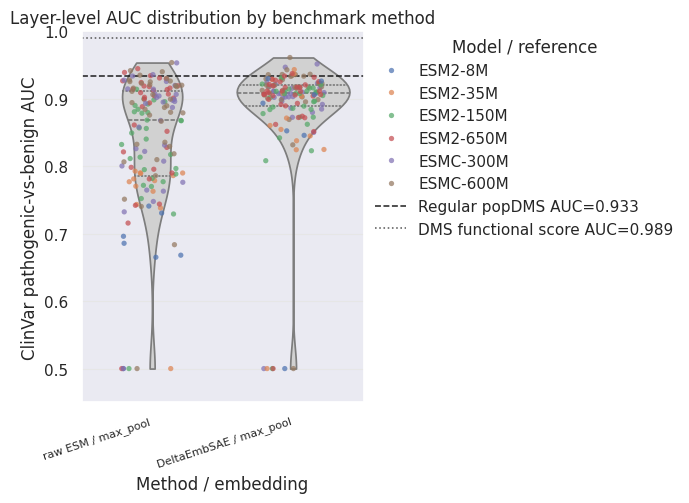

,benchmark,method_pool,n_layers,mean_auc,median_auc,max_auc
0,Fixed DeltaEmbSAE,DeltaEmbSAE / max_pool,153,0.887562,0.908115,0.961201
1,Raw embeddings,raw ESM / max_pool,153,0.837377,0.868006,0.953693


In [14]:
from matplotlib.lines import Line2D

AUC_BY_LAYER_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_auc_by_model_layer.png"
AUC_METHOD_VIOLIN_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_auc_distribution_by_method.png"
AUC_METHOD_SUMMARY_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_auc_method_summary.csv"


def _load_auc_metrics_for_plotting():
    if "spearman_auc_df" in globals() and isinstance(spearman_auc_df, pd.DataFrame) and not spearman_auc_df.empty:
        metrics_df = spearman_auc_df.copy()
    elif SPEARMAN_AUC_TABLE_PATH.is_file():
        metrics_df = pd.read_csv(SPEARMAN_AUC_TABLE_PATH)
    else:
        raise FileNotFoundError(f"Missing benchmark metrics table: {SPEARMAN_AUC_TABLE_PATH}")

    metrics_df["auc"] = pd.to_numeric(metrics_df["auc"], errors="coerce")
    metrics_df["layer"] = pd.to_numeric(metrics_df["layer"], errors="coerce")
    if "method_pool" not in metrics_df.columns:
        metrics_df["method_pool"] = metrics_df["method"].astype(str) + " / " + metrics_df["embedding_type"].astype(str)
    return metrics_df


def _auc_reference_specs(metrics_df):
    specs = []
    for benchmark, label, color, linestyle in [
        ("Regular popDMS", "Regular popDMS", "#111111", "--"),
        ("DMS functional score", "DMS functional score", "#4c4c4c", ":"),
    ]:
        values = pd.to_numeric(metrics_df.loc[metrics_df["benchmark"].eq(benchmark), "auc"], errors="coerce")
        values = values[np.isfinite(values)]
        if not values.empty:
            specs.append({"label": label, "auc": float(values.iloc[0]), "color": color, "linestyle": linestyle})
    return specs


def _add_auc_reference_lines(ax, reference_specs, labeled=False):
    for ref in reference_specs:
        label = f"{ref['label']} AUC={ref['auc']:.3f}" if labeled else None
        ax.axhline(ref["auc"], color=ref["color"], linestyle=ref["linestyle"], linewidth=1.15, alpha=0.9, label=label, zorder=1)


def _auc_ylim(values, reference_specs):
    ref_values = np.asarray([ref["auc"] for ref in reference_specs], dtype=float)
    all_values = np.concatenate([np.asarray(values, dtype=float), ref_values]) if len(ref_values) else np.asarray(values, dtype=float)
    all_values = all_values[np.isfinite(all_values)]
    if len(all_values) == 0:
        return (0.45, 1.0)
    return (max(0.0, min(0.45, float(all_values.min()) - 0.03)), min(1.0, max(0.55, float(all_values.max()) + 0.03)))


auc_metrics_for_plots = _load_auc_metrics_for_plotting()
auc_reference_specs = _auc_reference_specs(auc_metrics_for_plots)
auc_layer_plot_df = auc_metrics_for_plots[
    auc_metrics_for_plots["benchmark"].isin(["Raw embeddings", "Fixed DeltaEmbSAE"])
    & np.isfinite(auc_metrics_for_plots["auc"])
    & np.isfinite(auc_metrics_for_plots["layer"])
].copy()

if auc_layer_plot_df.empty:
    print("No finite model/layer AUC rows were available for additional AUC plots.")
else:
    auc_layer_plot_df["layer"] = auc_layer_plot_df["layer"].astype(int)
    model_order = [model for model in MODEL_SHORT_NAMES.values() if model in set(auc_layer_plot_df["model_short"])]
    model_order += [model for model in sorted(auc_layer_plot_df["model_short"].dropna().unique()) if model not in model_order]
    preferred_methods = ["raw ESM / max_pool", "DeltaEmbSAE / max_pool"]
    method_order = [method for method in preferred_methods if method in set(auc_layer_plot_df["method_pool"])]
    method_order += [method for method in sorted(auc_layer_plot_df["method_pool"].dropna().unique()) if method not in method_order]
    palette = dict(zip(method_order, sns.color_palette("Set2", n_colors=max(len(method_order), 1))))

    ncols = min(3, max(1, len(model_order)))
    nrows = int(np.ceil(len(model_order) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), sharey=True, squeeze=False)
    axes_flat = axes.ravel()

    for ax, model_short in zip(axes_flat, model_order):
        model_df = auc_layer_plot_df[auc_layer_plot_df["model_short"].eq(model_short)]
        for method in method_order:
            method_df = model_df[model_df["method_pool"].eq(method)].sort_values("layer")
            if method_df.empty:
                continue
            ax.plot(method_df["layer"], method_df["auc"], marker="o", linewidth=1.6, markersize=3.5, color=palette[method], label=method)
        _add_auc_reference_lines(ax, auc_reference_specs)
        ax.set_title(model_short)
        ax.set_xlabel("Layer")
        ax.set_ylabel("ClinVar AUC")
        ax.set_ylim(*_auc_ylim(auc_layer_plot_df["auc"], auc_reference_specs))
        ax.grid(axis="both", color="0.90", linewidth=0.8)

    for ax in axes_flat[len(model_order):]:
        ax.axis("off")

    handles = [Line2D([0], [0], color=palette[method], marker="o", linewidth=1.6, markersize=4, label=method) for method in method_order]
    handles += [Line2D([0], [0], color=ref["color"], linestyle=ref["linestyle"], linewidth=1.15, label=f"{ref['label']} AUC={ref['auc']:.3f}") for ref in auc_reference_specs]
    fig.legend(handles=handles, loc="upper center", ncol=min(len(handles), 4), frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle("ClinVar pathogenic-vs-benign AUC across PLM layers", y=1.06)
    fig.tight_layout()
    fig.savefig(AUC_BY_LAYER_FIGURE_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(max(7.0, 1.9 * len(method_order)), 5.2))
    sns.violinplot(data=auc_layer_plot_df, x="method_pool", y="auc", order=method_order, inner="quartile", cut=0, color="0.82", ax=ax)
    sns.stripplot(data=auc_layer_plot_df, x="method_pool", y="auc", order=method_order, hue="model_short", dodge=False, jitter=0.22, size=3.8, alpha=0.72, ax=ax)
    _add_auc_reference_lines(ax, auc_reference_specs, labeled=True)
    ax.set_xlabel("Method / embedding")
    ax.set_ylabel("ClinVar pathogenic-vs-benign AUC")
    ax.set_title("Layer-level AUC distribution by benchmark method")
    ax.set_ylim(*_auc_ylim(auc_layer_plot_df["auc"], auc_reference_specs))
    ax.tick_params(axis="x", labelsize=8, rotation=18)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    ax.grid(axis="y", color="0.90", linewidth=0.8)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, title="Model / reference", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, borderaxespad=0)
    fig.tight_layout()
    fig.savefig(AUC_METHOD_VIOLIN_FIGURE_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

    auc_method_summary_df = (
        auc_layer_plot_df.groupby(["benchmark", "method_pool"], dropna=False)
        .agg(n_layers=("auc", "size"), mean_auc=("auc", "mean"), median_auc=("auc", "median"), max_auc=("auc", "max"))
        .reset_index()
    )
    auc_method_summary_df.to_csv(AUC_METHOD_SUMMARY_TABLE_PATH, index=False)
    display(auc_method_summary_df.sort_values(["median_auc", "max_auc"], ascending=[False, False]))


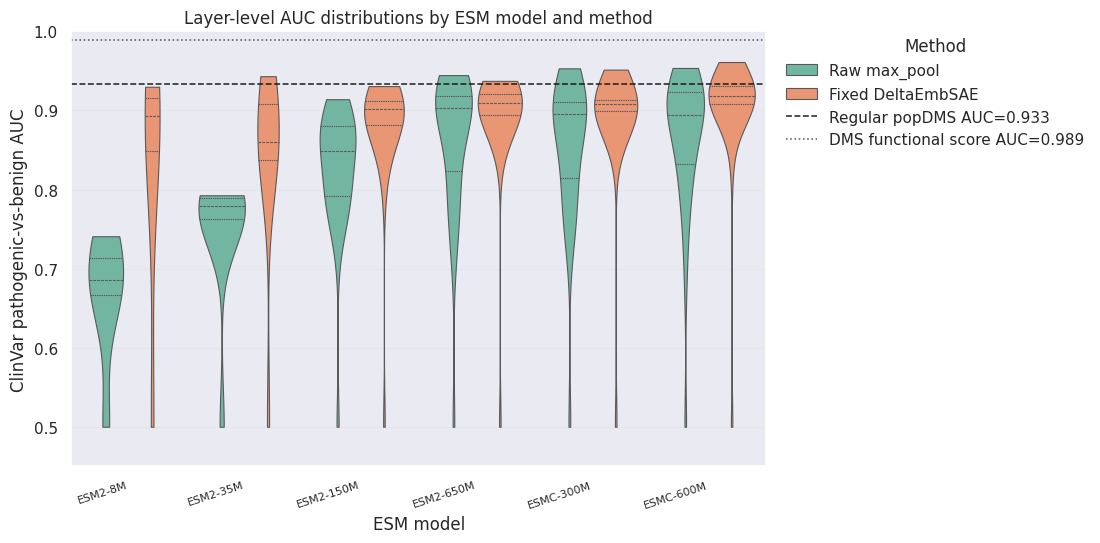

,model_short,method_label,n_layers,mean_auc,median_auc,max_auc
10,ESMC-600M,Fixed DeltaEmbSAE,37,0.905987,0.917815,0.961201
4,ESM2-650M,Fixed DeltaEmbSAE,34,0.894567,0.909913,0.937383
8,ESMC-300M,Fixed DeltaEmbSAE,31,0.892921,0.907891,0.951567
0,ESM2-150M,Fixed DeltaEmbSAE,31,0.880220,0.901749,0.930773
6,ESM2-8M,Fixed DeltaEmbSAE,7,0.836267,0.893472,0.929930
2,ESM2-35M,Fixed DeltaEmbSAE,13,0.849145,0.860413,0.943281
5,ESM2-650M,Raw max_pool,34,0.863995,0.903350,0.944648
9,ESMC-300M,Raw max_pool,31,0.855161,0.895083,0.953224
11,ESMC-600M,Raw max_pool,37,0.867294,0.894334,0.953693
1,ESM2-150M,Raw max_pool,31,0.827620,0.849281,0.914182


In [15]:
AUC_MODEL_METHOD_VIOLIN_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_auc_distribution_by_model_method.png"
AUC_MODEL_METHOD_SUMMARY_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_auc_model_method_summary.csv"


def _load_model_method_auc_plot_data():
    if "auc_metrics_for_plots" in globals() and isinstance(auc_metrics_for_plots, pd.DataFrame) and not auc_metrics_for_plots.empty:
        metrics_df = auc_metrics_for_plots.copy()
    elif "spearman_auc_df" in globals() and isinstance(spearman_auc_df, pd.DataFrame) and not spearman_auc_df.empty:
        metrics_df = spearman_auc_df.copy()
    elif SPEARMAN_AUC_TABLE_PATH.is_file():
        metrics_df = pd.read_csv(SPEARMAN_AUC_TABLE_PATH)
    else:
        raise FileNotFoundError(f"Missing benchmark metrics table: {SPEARMAN_AUC_TABLE_PATH}")

    metrics_df["auc"] = pd.to_numeric(metrics_df["auc"], errors="coerce")
    metrics_df["layer"] = pd.to_numeric(metrics_df["layer"], errors="coerce")
    if "method_pool" not in metrics_df.columns:
        metrics_df["method_pool"] = metrics_df["method"].astype(str) + " / " + metrics_df["embedding_type"].astype(str)

    plot_df = metrics_df[
        metrics_df["benchmark"].isin(["Raw embeddings", "Fixed DeltaEmbSAE"])
        & np.isfinite(metrics_df["auc"])
        & np.isfinite(metrics_df["layer"])
        & metrics_df["model_short"].notna()
    ].copy()
    method_labels = {
        "raw ESM / max_pool": "Raw max_pool",
        "DeltaEmbSAE / max_pool": "Fixed DeltaEmbSAE",
    }
    plot_df["method_label"] = plot_df["method_pool"].map(method_labels).fillna(plot_df["method_pool"])
    plot_df["model_short"] = plot_df["model_short"].astype(str)
    return plot_df, metrics_df


if "_auc_reference_specs" not in globals():
    def _auc_reference_specs(metrics_df):
        specs = []
        for benchmark, label, color, linestyle in [
            ("Regular popDMS", "Regular popDMS", "#111111", "--"),
            ("DMS functional score", "DMS functional score", "#4c4c4c", ":"),
        ]:
            values = pd.to_numeric(metrics_df.loc[metrics_df["benchmark"].eq(benchmark), "auc"], errors="coerce")
            values = values[np.isfinite(values)]
            if not values.empty:
                specs.append({"label": label, "auc": float(values.iloc[0]), "color": color, "linestyle": linestyle})
        return specs


if "_add_auc_reference_lines" not in globals():
    def _add_auc_reference_lines(ax, reference_specs, labeled=False):
        for ref in reference_specs:
            label = f"{ref['label']} AUC={ref['auc']:.3f}" if labeled else None
            ax.axhline(ref["auc"], color=ref["color"], linestyle=ref["linestyle"], linewidth=1.15, alpha=0.9, label=label, zorder=1)


if "_auc_ylim" not in globals():
    def _auc_ylim(values, reference_specs):
        ref_values = np.asarray([ref["auc"] for ref in reference_specs], dtype=float)
        all_values = np.concatenate([np.asarray(values, dtype=float), ref_values]) if len(ref_values) else np.asarray(values, dtype=float)
        all_values = all_values[np.isfinite(all_values)]
        if len(all_values) == 0:
            return (0.45, 1.0)
        return (max(0.0, min(0.45, float(all_values.min()) - 0.03)), min(1.0, max(0.55, float(all_values.max()) + 0.03)))


auc_model_method_plot_df, auc_model_method_metrics_df = _load_model_method_auc_plot_data()
auc_model_method_reference_specs = _auc_reference_specs(auc_model_method_metrics_df)
if auc_model_method_plot_df.empty:
    print("No finite model/method AUC rows were available for the model-by-method violin plot.")
else:
    model_order = [model for model in MODEL_SHORT_NAMES.values() if model in set(auc_model_method_plot_df["model_short"])]
    model_order += [model for model in sorted(auc_model_method_plot_df["model_short"].unique()) if model not in model_order]
    method_order = [method for method in ["Raw max_pool", "Fixed DeltaEmbSAE"] if method in set(auc_model_method_plot_df["method_label"])]
    method_order += [method for method in sorted(auc_model_method_plot_df["method_label"].unique()) if method not in method_order]
    palette = dict(zip(method_order, sns.color_palette("Set2", n_colors=max(len(method_order), 1))))

    fig_width = max(9.0, min(15.0, 1.45 * len(model_order) + 2.5))
    fig, ax = plt.subplots(figsize=(fig_width, 5.6))
    sns.violinplot(
        data=auc_model_method_plot_df,
        x="model_short",
        y="auc",
        hue="method_label",
        order=model_order,
        hue_order=method_order,
        palette=palette,
        inner="quartile",
        cut=0,
        linewidth=0.8,
        ax=ax,
    )
    _add_auc_reference_lines(ax, auc_model_method_reference_specs, labeled=True)
    ax.set_xlabel("ESM model")
    ax.set_ylabel("ClinVar pathogenic-vs-benign AUC")
    ax.set_title("Layer-level AUC distributions by ESM model and method")
    ax.set_ylim(*_auc_ylim(auc_model_method_plot_df["auc"], auc_model_method_reference_specs))
    ax.tick_params(axis="x", labelsize=8, rotation=18)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    ax.grid(axis="y", color="0.90", linewidth=0.8)
    ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, borderaxespad=0)
    fig.tight_layout()
    fig.savefig(AUC_MODEL_METHOD_VIOLIN_FIGURE_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

    auc_model_method_summary_df = (
        auc_model_method_plot_df.groupby(["model_short", "method_label"], dropna=False)
        .agg(n_layers=("auc", "size"), mean_auc=("auc", "mean"), median_auc=("auc", "median"), max_auc=("auc", "max"))
        .reset_index()
    )
    auc_model_method_summary_df.to_csv(AUC_MODEL_METHOD_SUMMARY_TABLE_PATH, index=False)
    display(auc_model_method_summary_df.sort_values(["method_label", "median_auc", "max_auc"], ascending=[True, False, False]))


In [16]:
BEST_MODEL_LAYER_AUC_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_best_model_layer_auc.csv"


def _load_best_model_layer_auc_metrics():
    if "auc_metrics_for_plots" in globals() and isinstance(auc_metrics_for_plots, pd.DataFrame) and not auc_metrics_for_plots.empty:
        metrics_df = auc_metrics_for_plots.copy()
    elif "spearman_auc_df" in globals() and isinstance(spearman_auc_df, pd.DataFrame) and not spearman_auc_df.empty:
        metrics_df = spearman_auc_df.copy()
    elif SPEARMAN_AUC_TABLE_PATH.is_file():
        metrics_df = pd.read_csv(SPEARMAN_AUC_TABLE_PATH)
    else:
        raise FileNotFoundError(f"Missing benchmark metrics table: {SPEARMAN_AUC_TABLE_PATH}")

    metrics_df["auc"] = pd.to_numeric(metrics_df["auc"], errors="coerce")
    metrics_df["layer"] = pd.to_numeric(metrics_df["layer"], errors="coerce")
    metrics_df["spearman_rho"] = pd.to_numeric(metrics_df.get("spearman_rho", np.nan), errors="coerce")
    return metrics_df


def _best_model_layer_auc_rows(metrics_df):
    specs = [
        (
            "Raw max_pool",
            metrics_df["benchmark"].eq("Raw embeddings")
            & metrics_df["method"].eq("raw ESM")
            & metrics_df["embedding_type"].eq("max_pool"),
        ),
        (
            "Fixed DeltaEmbSAE",
            metrics_df["benchmark"].eq("Fixed DeltaEmbSAE")
            & metrics_df["method"].eq("DeltaEmbSAE")
            & metrics_df["embedding_type"].eq("max_pool"),
        ),
    ]
    rows = []
    for method_label, mask in specs:
        method_df = metrics_df.loc[mask].copy()
        method_df = method_df[np.isfinite(method_df["auc"]) & np.isfinite(method_df["layer"])]
        if method_df.empty:
            rows.append({
                "method_label": method_label,
                "model_short": "",
                "model": "",
                "layer": np.nan,
                "clinvar_auc": np.nan,
                "spearman_rho": np.nan,
                "n_variants": np.nan,
                "model_label": "",
            })
            continue
        best = method_df.sort_values(["auc", "spearman_rho"], ascending=[False, False]).iloc[0]
        n_variants = pd.to_numeric(pd.Series([best.get("n_variants", np.nan)]), errors="coerce").iloc[0]
        rows.append({
            "method_label": method_label,
            "model_short": best.get("model_short", ""),
            "model": best.get("model", ""),
            "layer": int(best["layer"]),
            "clinvar_auc": float(best["auc"]),
            "spearman_rho": best.get("spearman_rho", np.nan),
            "n_variants": int(n_variants) if pd.notna(n_variants) else np.nan,
            "model_label": best.get("model_label", ""),
        })
    return pd.DataFrame(rows)


best_model_layer_auc_metrics_df = _load_best_model_layer_auc_metrics()
best_model_layer_auc_df = _best_model_layer_auc_rows(best_model_layer_auc_metrics_df)
best_model_layer_auc_df.to_csv(BEST_MODEL_LAYER_AUC_TABLE_PATH, index=False)

best_model_layer_display_df = best_model_layer_auc_df.copy()
for column in ["clinvar_auc", "spearman_rho"]:
    best_model_layer_display_df[column] = pd.to_numeric(best_model_layer_display_df[column], errors="coerce").round(3)
display(best_model_layer_display_df)


,method_label,model_short,model,layer,clinvar_auc,spearman_rho,n_variants,model_label
0,Raw max_pool,ESMC-600M,biohub/ESMC-600M,36,0.954,0.413,496,ESMC-600M Layer_36 raw max_pool
1,Fixed DeltaEmbSAE,ESMC-600M,biohub/ESMC-600M,36,0.961,0.449,496,ESMC-600M Layer_36 DeltaEmbSAE_max_pool_batcht...


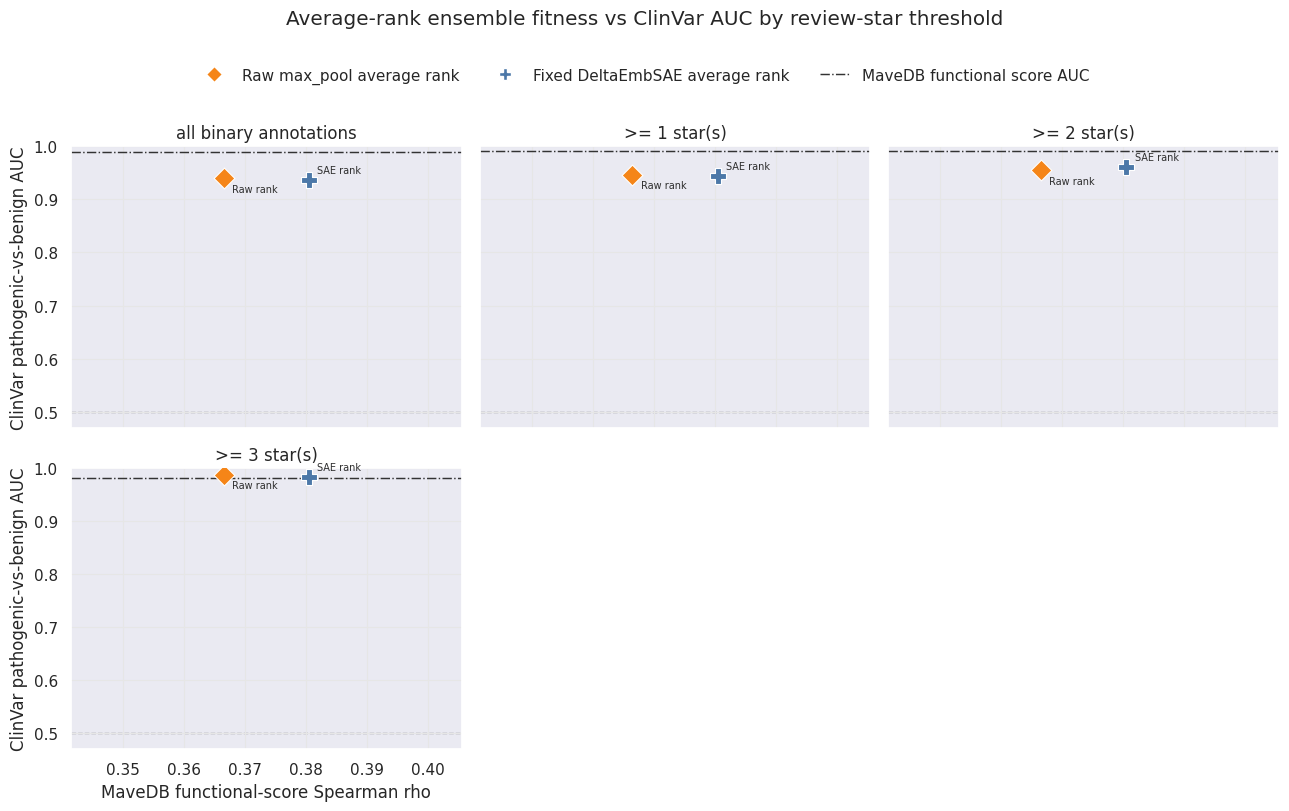

,review_filter,method_label,n_component_model_layers,spearman_rho,auc,functional_score_auc,n_variants
0,all binary annotations,Raw max_pool average rank,147,0.366,0.940,0.989,496
1,all binary annotations,Fixed DeltaEmbSAE average rank,147,0.380,0.937,0.989,496
2,>= 1 star(s),Raw max_pool average rank,147,0.366,0.947,0.991,491
3,>= 1 star(s),Fixed DeltaEmbSAE average rank,147,0.380,0.944,0.991,491
4,>= 2 star(s),Raw max_pool average rank,147,0.366,0.955,0.991,282
5,>= 2 star(s),Fixed DeltaEmbSAE average rank,147,0.380,0.961,0.991,282
6,>= 3 star(s),Raw max_pool average rank,147,0.366,0.987,0.982,132
7,>= 3 star(s),Fixed DeltaEmbSAE average rank,147,0.380,0.982,0.982,132
8,>= 4 star(s),Raw max_pool average rank,147,0.366,NaN,NaN,0
9,>= 4 star(s),Fixed DeltaEmbSAE average rank,147,0.380,NaN,NaN,0


In [17]:
from matplotlib.lines import Line2D

AVERAGE_RANK_ENSEMBLE_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_average_rank_ensemble_metrics_by_review_stars.csv"
AVERAGE_RANK_ENSEMBLE_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_average_rank_ensemble_spearman_auc_by_review_stars.png"
AVERAGE_RANK_ENSEMBLE_FITNESS_DIR = TABLE_DIR / "average_rank_ensemble_fitness"
AVERAGE_RANK_ENSEMBLE_FITNESS_DIR.mkdir(parents=True, exist_ok=True)


def _load_ensemble_metrics_table():
    if "spearman_auc_df" in globals() and isinstance(spearman_auc_df, pd.DataFrame) and not spearman_auc_df.empty:
        metrics_df = spearman_auc_df.copy()
    elif SPEARMAN_AUC_TABLE_PATH.is_file():
        metrics_df = pd.read_csv(SPEARMAN_AUC_TABLE_PATH)
    else:
        raise FileNotFoundError(f"Missing benchmark metrics table: {SPEARMAN_AUC_TABLE_PATH}")
    metrics_df["layer"] = pd.to_numeric(metrics_df["layer"], errors="coerce")
    metrics_df["auc"] = pd.to_numeric(metrics_df["auc"], errors="coerce")
    metrics_df["spearman_rho"] = pd.to_numeric(metrics_df.get("spearman_rho", np.nan), errors="coerce")
    return metrics_df


def _review_star_specs():
    return [(0, "all binary annotations")] + [(int(stars), f">= {int(stars)} star(s)") for stars in CLINVAR_REVIEW_STAR_THRESHOLDS]


def _ensemble_source_rows(metrics_df, benchmark, method, embedding_type=EMBEDDING_TYPE, model_short_prefix=None):
    rows = metrics_df[
        metrics_df["benchmark"].eq(benchmark)
        & metrics_df["method"].eq(method)
        & metrics_df["embedding_type"].eq(embedding_type)
        & np.isfinite(metrics_df["layer"])
        & metrics_df["layer"].gt(0)
    ].copy()
    if model_short_prefix is not None:
        rows = rows[rows["model_short"].astype(str).str.startswith(model_short_prefix)].copy()
    return rows.sort_values(["benchmark", "model_short", "layer"]).reset_index(drop=True)


def _load_ensemble_fitness_series(row):
    fitness_path = _as_existing_path(row.get("fitness_path", ""))
    if fitness_path is None:
        fitness_df = _fitness_dataframe_for_metrics_row(row, annotation_map={})
    else:
        fitness_df = pd.read_csv(fitness_path)
    fitness_df = fitness_df[["SequenceIndex", "fitness"]].copy()
    fitness_df["SequenceIndex"] = fitness_df["SequenceIndex"].astype(str)
    fitness_df["fitness"] = pd.to_numeric(fitness_df["fitness"], errors="coerce")
    fitness_df = fitness_df.dropna(subset=["fitness"])
    series_name = f"{row.get('model_short', row.get('model', 'model'))}_L{int(row['layer'])}"
    return fitness_df.groupby("SequenceIndex")["fitness"].mean().rename(series_name)


def _aggregate_fitness_rows(source_rows, aggregation):
    if source_rows.empty:
        raise ValueError("No source rows were available for the requested ensemble.")
    series_list = []
    for _, row in source_rows.iterrows():
        fitness_series = _load_ensemble_fitness_series(row)
        if aggregation == "rank_mean":
            fitness_series = fitness_series.rank(method="average", ascending=True)
        elif aggregation != "fitness_mean":
            raise ValueError(f"Unsupported aggregation: {aggregation}")
        series_list.append(fitness_series)
    matrix = pd.concat(series_list, axis=1)
    fitness = matrix.mean(axis=1, skipna=True)
    output_df = pd.DataFrame({
        "SequenceIndex": matrix.index.astype(str),
        "fitness": fitness.to_numpy(dtype=float),
        "n_component_model_layers": matrix.notna().sum(axis=1).to_numpy(dtype=int),
    })
    if aggregation == "rank_mean":
        output_df["average_rank"] = output_df["fitness"]
    else:
        output_df["mean_fitness"] = output_df["fitness"]
    return output_df[output_df["n_component_model_layers"].gt(0)].reset_index(drop=True), len(series_list)


def _ensemble_metrics_by_review_stars(ensemble_specs):
    rows = []
    for min_review_stars, review_filter in _review_star_specs():
        annotation_map = _clinvar_binary_annotation_map(min_review_stars=min_review_stars)
        functional_auc = _classification_metrics_for_fitness(_functional_score_fitness_dataframe(annotation_map))["auc"]
        for spec in ensemble_specs:
            fitness_df = spec["fitness_df"].copy()
            fitness_df["annotation"] = fitness_df["SequenceIndex"].astype(str).map(annotation_map)
            spearman_rho, n_score_sequences = _spearman_for_fitness_dataframe(fitness_df)
            auc_metrics = _classification_metrics_for_fitness(fitness_df)
            rows.append({
                "dataset": DATASET_NAME,
                "review_filter": review_filter,
                "min_review_stars": min_review_stars,
                "method_label": spec["method_label"],
                "short_label": spec["short_label"],
                "benchmark": spec["benchmark"],
                "method": spec["method"],
                "embedding_type": spec["embedding_type"],
                "aggregation": spec["aggregation"],
                "model_filter": spec.get("model_filter", "all models"),
                "n_component_model_layers": spec["n_component_model_layers"],
                "n_score_sequences": n_score_sequences,
                "spearman_rho": spearman_rho,
                "functional_score_auc": functional_auc,
                "fitness_path": str(spec["fitness_path"]),
                **auc_metrics,
            })
    return pd.DataFrame(rows)


def _plot_ensemble_review_star_panels(metrics_df, output_path, title, marker_specs=None):
    plot_df = metrics_df[np.isfinite(metrics_df["spearman_rho"]) & np.isfinite(metrics_df["auc"])].copy()
    if plot_df.empty:
        print("No finite ensemble Spearman/AUC rows were available to plot.")
        return None
    marker_specs = marker_specs or {}
    review_order = [label for _, label in _review_star_specs() if label in set(plot_df["review_filter"])]
    ncols = min(3, len(review_order))
    nrows = int(np.ceil(len(review_order) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.35 * ncols, 3.75 * nrows), sharex=True, sharey=True, squeeze=False)
    axes_flat = axes.ravel()
    x_values = plot_df["spearman_rho"].to_numpy(dtype=float)
    y_values = np.concatenate([plot_df["auc"].to_numpy(dtype=float), plot_df["functional_score_auc"].dropna().to_numpy(dtype=float)])
    x_pad = max(0.025, 0.12 * (np.nanmax(x_values) - np.nanmin(x_values)))
    y_pad = max(0.025, 0.12 * (np.nanmax(y_values) - np.nanmin(y_values)))
    xlim = (max(-1.0, np.nanmin(x_values) - x_pad), min(1.0, np.nanmax(x_values) + x_pad))
    ylim = (max(0.0, min(np.nanmin(y_values) - y_pad, 0.47)), min(1.0, max(np.nanmax(y_values) + y_pad, 0.53)))
    for ax, review_filter in zip(axes_flat, review_order):
        panel_df = plot_df[plot_df["review_filter"].eq(review_filter)]
        for _, row in panel_df.iterrows():
            spec = marker_specs.get(row["method_label"], {})
            ax.scatter(
                row["spearman_rho"],
                row["auc"],
                s=spec.get("size", 115),
                marker=spec.get("marker", "o"),
                color=spec.get("color", "0.35"),
                edgecolors="white",
                linewidths=0.8,
                zorder=4,
            )
            ax.annotate(
                row["short_label"],
                (row["spearman_rho"], row["auc"]),
                xytext=spec.get("offset", (6, -9)),
                textcoords="offset points",
                fontsize=7,
                color="0.18",
            )
        functional_auc_values = panel_df["functional_score_auc"].dropna().unique()
        if len(functional_auc_values):
            ax.axhline(functional_auc_values[0], color="0.20", linestyle="-.", linewidth=1.05, zorder=1)
        ax.axhline(0.5, color="0.35", linestyle="--", linewidth=0.9, zorder=0)
        ax.axvline(0.0, color="0.72", linestyle=":", linewidth=0.9, zorder=0)
        ax.set_title(review_filter)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(axis="both", color="0.90", linewidth=0.8)
    for ax in axes_flat[len(review_order):]:
        ax.axis("off")
    for ax in axes[-1, :]:
        ax.set_xlabel("MaveDB functional-score Spearman rho")
    for ax in axes[:, 0]:
        ax.set_ylabel("ClinVar pathogenic-vs-benign AUC")
    handles = [
        Line2D([0], [0], marker=spec.get("marker", "o"), color="none", markerfacecolor=spec.get("color", "0.35"), markeredgecolor="white", markersize=8, label=label)
        for label, spec in marker_specs.items()
    ]
    handles.append(Line2D([0], [0], color="0.20", linestyle="-.", linewidth=1.05, label="MaveDB functional score AUC"))
    fig.legend(handles=handles, loc="upper center", ncol=min(len(handles), 3), frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(title, y=1.08)
    fig.tight_layout()
    fig.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
    return fig


ensemble_source_metrics_df = _load_ensemble_metrics_table()
average_rank_ensemble_specs = []
for method_label, short_label, benchmark, method, fitness_filename in [
    ("Raw max_pool average rank", "Raw rank", "Raw embeddings", "raw ESM", "raw_max_pool_average_rank_fitness.csv"),
    ("Fixed DeltaEmbSAE average rank", "SAE rank", "Fixed DeltaEmbSAE", "DeltaEmbSAE", "fixed_deltaembsae_average_rank_fitness.csv"),
]:
    source_rows = _ensemble_source_rows(ensemble_source_metrics_df, benchmark=benchmark, method=method, embedding_type=EMBEDDING_TYPE)
    fitness_df, n_components = _aggregate_fitness_rows(source_rows, aggregation="rank_mean")
    fitness_path = AVERAGE_RANK_ENSEMBLE_FITNESS_DIR / fitness_filename
    fitness_df.to_csv(fitness_path, index=False)
    average_rank_ensemble_specs.append({
        "method_label": method_label,
        "short_label": short_label,
        "benchmark": benchmark,
        "method": method,
        "embedding_type": EMBEDDING_TYPE,
        "aggregation": "rank_mean",
        "model_filter": "all non-layer-0 model/layers",
        "n_component_model_layers": n_components,
        "fitness_df": fitness_df,
        "fitness_path": fitness_path,
    })

average_rank_ensemble_metrics_by_review_stars_df = _ensemble_metrics_by_review_stars(average_rank_ensemble_specs)
average_rank_ensemble_metrics_by_review_stars_df.to_csv(AVERAGE_RANK_ENSEMBLE_TABLE_PATH, index=False)
average_rank_marker_specs = {
    "Raw max_pool average rank": {"marker": "D", "size": 112, "color": "#f58518", "offset": (6, -10)},
    "Fixed DeltaEmbSAE average rank": {"marker": "P", "size": 135, "color": "#4c78a8", "offset": (6, 5)},
}
average_rank_fig = _plot_ensemble_review_star_panels(
    average_rank_ensemble_metrics_by_review_stars_df,
    AVERAGE_RANK_ENSEMBLE_FIGURE_PATH,
    "Average-rank ensemble fitness vs ClinVar AUC by review-star threshold",
    marker_specs=average_rank_marker_specs,
)
if average_rank_fig is not None:
    plt.show()
display(
    average_rank_ensemble_metrics_by_review_stars_df[
        ["review_filter", "method_label", "n_component_model_layers", "spearman_rho", "auc", "functional_score_auc", "n_variants"]
    ].assign(
        spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
        auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
        functional_score_auc=lambda df: pd.to_numeric(df["functional_score_auc"], errors="coerce").round(3),
    )
)


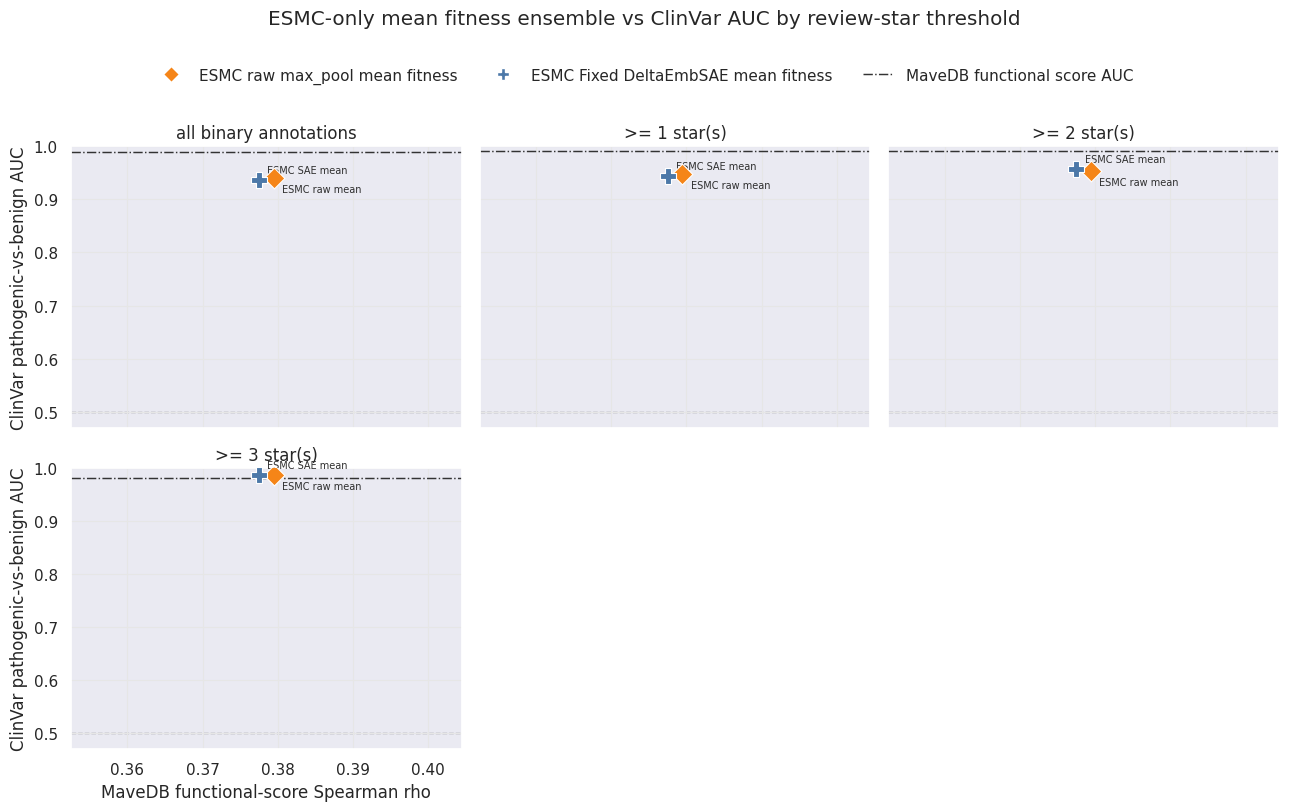

,review_filter,method_label,n_component_model_layers,spearman_rho,auc,functional_score_auc,n_variants
0,all binary annotations,ESMC raw max_pool mean fitness,66,0.379,0.940,0.989,496
1,all binary annotations,ESMC Fixed DeltaEmbSAE mean fitness,66,0.378,0.937,0.989,496
2,>= 1 star(s),ESMC raw max_pool mean fitness,66,0.379,0.948,0.991,491
3,>= 1 star(s),ESMC Fixed DeltaEmbSAE mean fitness,66,0.378,0.944,0.991,491
4,>= 2 star(s),ESMC raw max_pool mean fitness,66,0.379,0.954,0.991,282
5,>= 2 star(s),ESMC Fixed DeltaEmbSAE mean fitness,66,0.378,0.958,0.991,282
6,>= 3 star(s),ESMC raw max_pool mean fitness,66,0.379,0.986,0.982,132
7,>= 3 star(s),ESMC Fixed DeltaEmbSAE mean fitness,66,0.378,0.987,0.982,132
8,>= 4 star(s),ESMC raw max_pool mean fitness,66,0.379,NaN,NaN,0
9,>= 4 star(s),ESMC Fixed DeltaEmbSAE mean fitness,66,0.378,NaN,NaN,0


In [18]:
ESMC_MEAN_FITNESS_ENSEMBLE_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_esmc_mean_fitness_ensemble_metrics_by_review_stars.csv"
ESMC_MEAN_FITNESS_ENSEMBLE_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_esmc_mean_fitness_ensemble_spearman_auc_by_review_stars.png"
ESMC_MEAN_FITNESS_ENSEMBLE_FITNESS_DIR = TABLE_DIR / "esmc_mean_fitness_ensemble_fitness"
ESMC_MEAN_FITNESS_ENSEMBLE_FITNESS_DIR.mkdir(parents=True, exist_ok=True)

esmc_mean_fitness_ensemble_specs = []
for method_label, short_label, benchmark, method, fitness_filename in [
    ("ESMC raw max_pool mean fitness", "ESMC raw mean", "Raw embeddings", "raw ESM", "esmc_raw_max_pool_mean_fitness.csv"),
    ("ESMC Fixed DeltaEmbSAE mean fitness", "ESMC SAE mean", "Fixed DeltaEmbSAE", "DeltaEmbSAE", "esmc_fixed_deltaembsae_mean_fitness.csv"),
]:
    source_rows = _ensemble_source_rows(
        ensemble_source_metrics_df,
        benchmark=benchmark,
        method=method,
        embedding_type=EMBEDDING_TYPE,
        model_short_prefix="ESMC-",
    )
    fitness_df, n_components = _aggregate_fitness_rows(source_rows, aggregation="fitness_mean")
    fitness_path = ESMC_MEAN_FITNESS_ENSEMBLE_FITNESS_DIR / fitness_filename
    fitness_df.to_csv(fitness_path, index=False)
    esmc_mean_fitness_ensemble_specs.append({
        "method_label": method_label,
        "short_label": short_label,
        "benchmark": benchmark,
        "method": method,
        "embedding_type": EMBEDDING_TYPE,
        "aggregation": "fitness_mean",
        "model_filter": "ESMC non-layer-0 model/layers",
        "n_component_model_layers": n_components,
        "fitness_df": fitness_df,
        "fitness_path": fitness_path,
    })

esmc_mean_fitness_ensemble_metrics_by_review_stars_df = _ensemble_metrics_by_review_stars(esmc_mean_fitness_ensemble_specs)
esmc_mean_fitness_ensemble_metrics_by_review_stars_df.to_csv(ESMC_MEAN_FITNESS_ENSEMBLE_TABLE_PATH, index=False)
esmc_mean_fitness_marker_specs = {
    "ESMC raw max_pool mean fitness": {"marker": "D", "size": 112, "color": "#f58518", "offset": (6, -10)},
    "ESMC Fixed DeltaEmbSAE mean fitness": {"marker": "P", "size": 135, "color": "#4c78a8", "offset": (6, 5)},
}
esmc_mean_fitness_fig = _plot_ensemble_review_star_panels(
    esmc_mean_fitness_ensemble_metrics_by_review_stars_df,
    ESMC_MEAN_FITNESS_ENSEMBLE_FIGURE_PATH,
    "ESMC-only mean fitness ensemble vs ClinVar AUC by review-star threshold",
    marker_specs=esmc_mean_fitness_marker_specs,
)
if esmc_mean_fitness_fig is not None:
    plt.show()
display(
    esmc_mean_fitness_ensemble_metrics_by_review_stars_df[
        ["review_filter", "method_label", "n_component_model_layers", "spearman_rho", "auc", "functional_score_auc", "n_variants"]
    ].assign(
        spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
        auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
        functional_score_auc=lambda df: pd.to_numeric(df["functional_score_auc"], errors="coerce").round(3),
    )
)


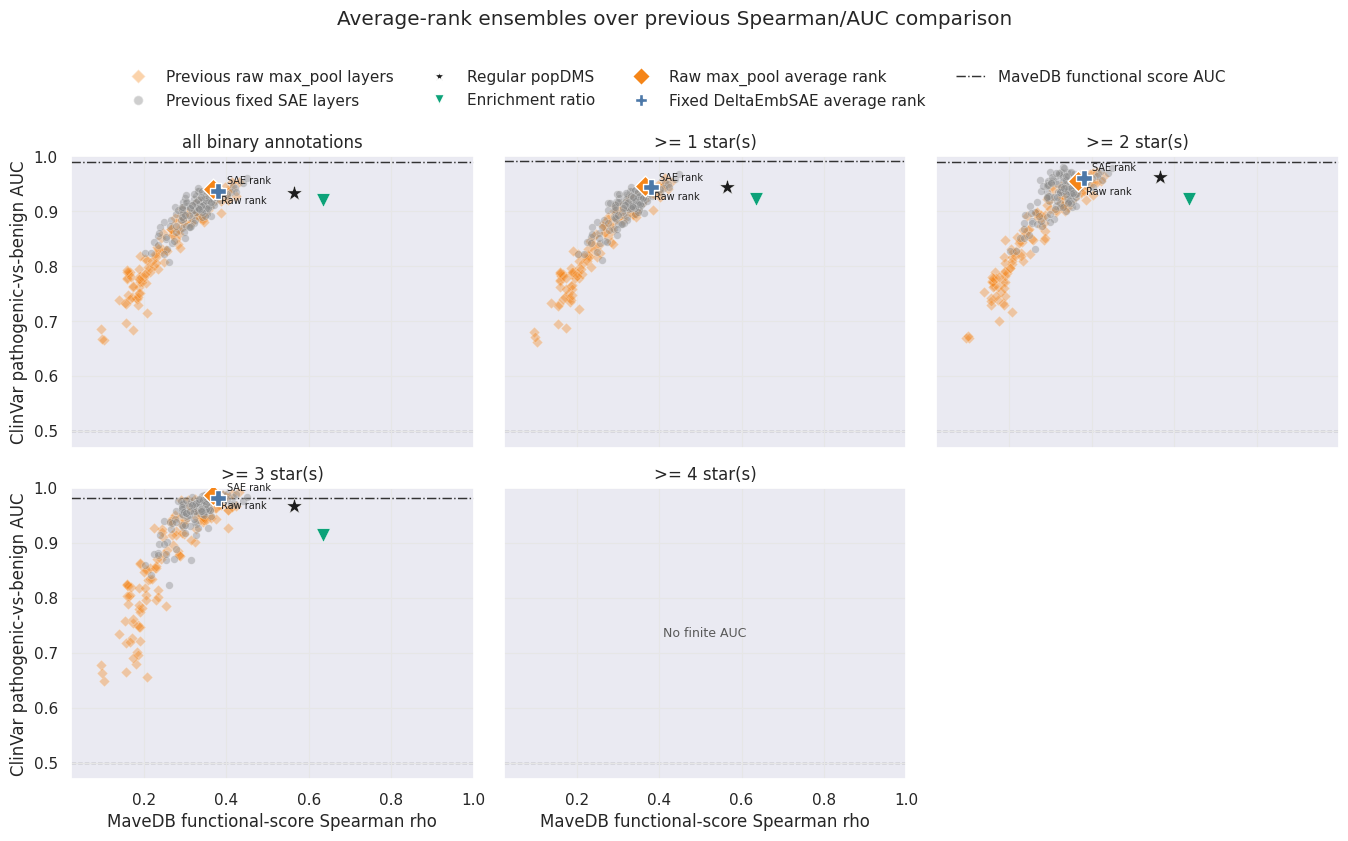

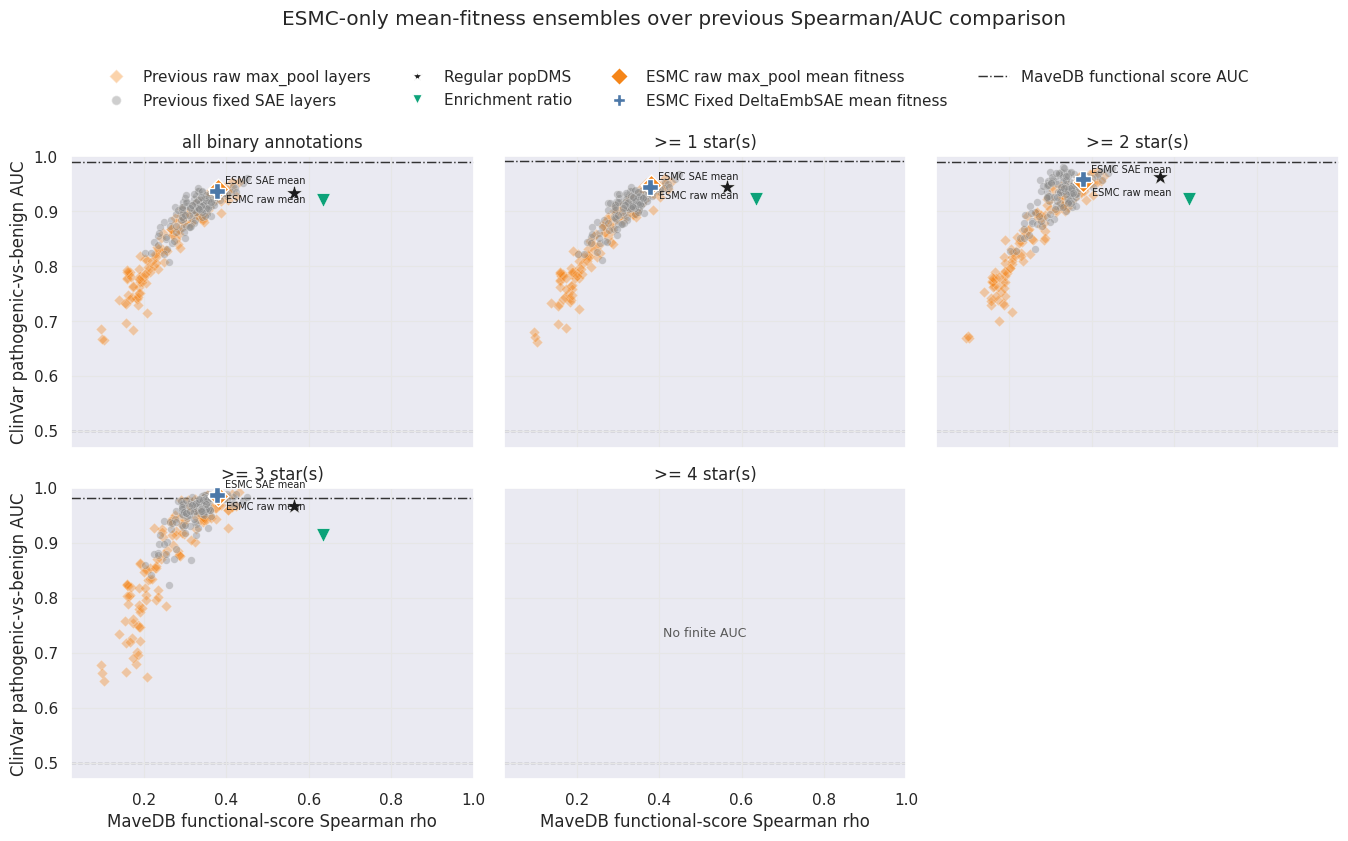

,ensemble_family,review_filter,method_label,n_component_model_layers,spearman_rho,auc,functional_score_auc,n_variants
0,average rank,all binary annotations,Raw max_pool average rank,147,0.366,0.940,0.989,496
1,average rank,all binary annotations,Fixed DeltaEmbSAE average rank,147,0.380,0.937,0.989,496
2,average rank,>= 1 star(s),Raw max_pool average rank,147,0.366,0.947,0.991,491
3,average rank,>= 1 star(s),Fixed DeltaEmbSAE average rank,147,0.380,0.944,0.991,491
4,average rank,>= 2 star(s),Raw max_pool average rank,147,0.366,0.955,0.991,282
5,average rank,>= 2 star(s),Fixed DeltaEmbSAE average rank,147,0.380,0.961,0.991,282
6,average rank,>= 3 star(s),Raw max_pool average rank,147,0.366,0.987,0.982,132
7,average rank,>= 3 star(s),Fixed DeltaEmbSAE average rank,147,0.380,0.982,0.982,132
8,average rank,>= 4 star(s),Raw max_pool average rank,147,0.366,NaN,NaN,0
9,average rank,>= 4 star(s),Fixed DeltaEmbSAE average rank,147,0.380,NaN,NaN,0


In [19]:
COMBINED_AVERAGE_RANK_ENSEMBLE_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_average_rank_ensemble_with_previous_spearman_auc_by_review_stars.png"
COMBINED_ESMC_MEAN_FITNESS_ENSEMBLE_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_esmc_mean_fitness_ensemble_with_previous_spearman_auc_by_review_stars.png"
COMBINED_ENSEMBLE_WITH_PREVIOUS_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_ensemble_with_previous_metrics_by_review_stars.csv"

if "AVERAGE_RANK_ENSEMBLE_TABLE_PATH" not in globals():
    AVERAGE_RANK_ENSEMBLE_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_average_rank_ensemble_metrics_by_review_stars.csv"
if "ESMC_MEAN_FITNESS_ENSEMBLE_TABLE_PATH" not in globals():
    ESMC_MEAN_FITNESS_ENSEMBLE_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_esmc_mean_fitness_ensemble_metrics_by_review_stars.csv"


def _combined_review_star_label(min_review_stars):
    min_review_stars = int(min_review_stars)
    return "all binary annotations" if min_review_stars == 0 else f">= {min_review_stars} star(s)"


def _load_previous_metrics_for_combined_ensemble_plot():
    frames = []
    if "spearman_auc_df" in globals() and isinstance(spearman_auc_df, pd.DataFrame) and not spearman_auc_df.empty:
        all_binary_df = spearman_auc_df.copy()
    elif SPEARMAN_AUC_TABLE_PATH.is_file():
        all_binary_df = pd.read_csv(SPEARMAN_AUC_TABLE_PATH)
    else:
        raise FileNotFoundError(f"Missing benchmark metrics table: {SPEARMAN_AUC_TABLE_PATH}")
    all_binary_df["min_review_stars"] = 0
    frames.append(all_binary_df)

    if SPEARMAN_AUC_STAR_COMBINED_TABLE_PATH.is_file():
        frames.append(pd.read_csv(SPEARMAN_AUC_STAR_COMBINED_TABLE_PATH))
    else:
        star_frames = []
        for min_review_stars in CLINVAR_REVIEW_STAR_THRESHOLDS:
            star_path = TABLE_DIR / SPEARMAN_AUC_STAR_TABLE_TEMPLATE.format(stars=min_review_stars)
            if star_path.is_file():
                star_df = pd.read_csv(star_path)
                star_df["min_review_stars"] = min_review_stars
                star_frames.append(star_df)
        if star_frames:
            frames.append(pd.concat(star_frames, ignore_index=True, sort=False))

    previous_df = pd.concat(frames, ignore_index=True, sort=False)
    previous_df["min_review_stars"] = pd.to_numeric(previous_df["min_review_stars"], errors="coerce").fillna(0).astype(int)
    previous_df["review_filter"] = previous_df["min_review_stars"].map(_combined_review_star_label)
    previous_df["auc"] = pd.to_numeric(previous_df["auc"], errors="coerce")
    previous_df["spearman_rho"] = pd.to_numeric(previous_df["spearman_rho"], errors="coerce")
    if "plot_group" not in previous_df.columns:
        previous_df["plot_group"] = previous_df["benchmark"]
    return previous_df


def _load_combined_ensemble_metrics(table_path, variable_name):
    if variable_name in globals() and isinstance(globals()[variable_name], pd.DataFrame) and not globals()[variable_name].empty:
        ensemble_df = globals()[variable_name].copy()
    elif table_path.is_file():
        ensemble_df = pd.read_csv(table_path)
    else:
        raise FileNotFoundError(f"Missing ensemble metrics table: {table_path}. Run the preceding ensemble cell first.")
    ensemble_df["min_review_stars"] = pd.to_numeric(ensemble_df["min_review_stars"], errors="coerce").fillna(0).astype(int)
    ensemble_df["review_filter"] = ensemble_df["min_review_stars"].map(_combined_review_star_label)
    ensemble_df["auc"] = pd.to_numeric(ensemble_df["auc"], errors="coerce")
    ensemble_df["spearman_rho"] = pd.to_numeric(ensemble_df["spearman_rho"], errors="coerce")
    ensemble_df["functional_score_auc"] = pd.to_numeric(ensemble_df.get("functional_score_auc", np.nan), errors="coerce")
    return ensemble_df


def _combined_axis_limits(previous_df, ensemble_df):
    previous_finite = previous_df[np.isfinite(previous_df["spearman_rho"]) & np.isfinite(previous_df["auc"])]
    ensemble_finite = ensemble_df[np.isfinite(ensemble_df["spearman_rho"]) & np.isfinite(ensemble_df["auc"])]
    x_values = pd.concat([previous_finite["spearman_rho"], ensemble_finite["spearman_rho"]], ignore_index=True).to_numpy(dtype=float)
    y_values = pd.concat([previous_finite["auc"], ensemble_finite["auc"], ensemble_df["functional_score_auc"].dropna()], ignore_index=True).to_numpy(dtype=float)
    x_values = x_values[np.isfinite(x_values)]
    y_values = y_values[np.isfinite(y_values)]
    if len(x_values) == 0:
        x_values = np.asarray([0.0])
    if len(y_values) == 0:
        y_values = np.asarray([0.5])
    x_pad = max(0.025, 0.08 * (float(np.nanmax(x_values)) - float(np.nanmin(x_values))))
    y_pad = max(0.025, 0.08 * (float(np.nanmax(y_values)) - float(np.nanmin(y_values))))
    xlim = (max(-1.0, float(np.nanmin(x_values)) - x_pad), min(1.0, float(np.nanmax(x_values)) + x_pad))
    ylim = (max(0.0, min(float(np.nanmin(y_values)) - y_pad, 0.47)), min(1.0, max(float(np.nanmax(y_values)) + y_pad, 0.53)))
    return xlim, ylim


def _plot_ensemble_with_previous(previous_df, ensemble_df, output_path, title, ensemble_marker_specs):
    review_order = [_combined_review_star_label(0)] + [_combined_review_star_label(stars) for stars in CLINVAR_REVIEW_STAR_THRESHOLDS]
    review_order = [label for label in review_order if label in set(previous_df["review_filter"]) or label in set(ensemble_df["review_filter"])]
    ncols = min(3, max(1, len(review_order)))
    nrows = int(np.ceil(len(review_order) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.55 * ncols, 3.85 * nrows), sharex=True, sharey=True, squeeze=False)
    axes_flat = axes.ravel()
    xlim, ylim = _combined_axis_limits(previous_df, ensemble_df)
    previous_marker_specs = {
        "Raw embeddings": {"marker": "D", "size": 30, "color": "#f58518", "label": "Previous raw max_pool layers", "alpha": 0.36},
        "Fixed DeltaEmbSAE": {"marker": "o", "size": 31, "color": "0.55", "label": "Previous fixed SAE layers", "alpha": 0.42},
        "Regular popDMS": {"marker": "*", "size": 145, "color": "#111111", "label": "Regular popDMS", "alpha": 0.95},
        "Enrichment ratio": {"marker": "v", "size": 95, "color": "#009e73", "label": "Enrichment ratio", "alpha": 0.95},
    }

    for ax, review_filter in zip(axes_flat, review_order):
        panel_previous = previous_df[previous_df["review_filter"].eq(review_filter)].copy()
        panel_previous = panel_previous[np.isfinite(panel_previous["spearman_rho"]) & np.isfinite(panel_previous["auc"])]
        panel_ensemble = ensemble_df[ensemble_df["review_filter"].eq(review_filter)].copy()
        for benchmark, spec in previous_marker_specs.items():
            group_df = panel_previous[panel_previous["benchmark"].eq(benchmark)]
            if group_df.empty:
                continue
            ax.scatter(
                group_df["spearman_rho"],
                group_df["auc"],
                s=spec["size"],
                marker=spec["marker"],
                color=spec["color"],
                alpha=spec["alpha"],
                edgecolors="white",
                linewidths=0.35,
                zorder=2,
            )
        functional_auc = panel_previous.loc[panel_previous["benchmark"].eq("DMS functional score"), "auc"].dropna()
        if functional_auc.empty:
            functional_auc = panel_ensemble["functional_score_auc"].dropna()
        if not functional_auc.empty:
            ax.axhline(float(functional_auc.iloc[0]), color="0.20", linestyle="-.", linewidth=1.05, zorder=1)

        finite_ensemble = panel_ensemble[np.isfinite(panel_ensemble["spearman_rho"]) & np.isfinite(panel_ensemble["auc"])]
        for _, row in finite_ensemble.iterrows():
            spec = ensemble_marker_specs.get(row["method_label"], {})
            ax.scatter(
                row["spearman_rho"],
                row["auc"],
                s=spec.get("size", 145),
                marker=spec.get("marker", "P"),
                color=spec.get("color", "#4c78a8"),
                edgecolors="white",
                linewidths=1.0,
                zorder=5,
            )
            ax.annotate(
                row.get("short_label", row["method_label"]),
                (row["spearman_rho"], row["auc"]),
                xytext=spec.get("offset", (6, -9)),
                textcoords="offset points",
                fontsize=7,
                color="0.12",
            )
        if panel_previous.empty and finite_ensemble.empty:
            ax.text(0.5, 0.5, "No finite AUC", transform=ax.transAxes, ha="center", va="center", color="0.35", fontsize=9)
        ax.axhline(0.5, color="0.35", linestyle="--", linewidth=0.9, zorder=0)
        ax.axvline(0.0, color="0.72", linestyle=":", linewidth=0.9, zorder=0)
        ax.set_title(review_filter)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(axis="both", color="0.90", linewidth=0.8)

    for ax in axes_flat[len(review_order):]:
        ax.axis("off")
    for ax in axes[-1, :]:
        ax.set_xlabel("MaveDB functional-score Spearman rho")
    for ax in axes[:, 0]:
        ax.set_ylabel("ClinVar pathogenic-vs-benign AUC")
    handles = [
        Line2D([0], [0], marker=spec["marker"], color="none", markerfacecolor=spec["color"], markeredgecolor="white", markersize=7, alpha=spec["alpha"], label=spec["label"])
        for spec in previous_marker_specs.values()
    ]
    handles += [
        Line2D([0], [0], marker=spec.get("marker", "P"), color="none", markerfacecolor=spec.get("color", "#4c78a8"), markeredgecolor="white", markersize=9, label=label)
        for label, spec in ensemble_marker_specs.items()
    ]
    handles.append(Line2D([0], [0], color="0.20", linestyle="-.", linewidth=1.05, label="MaveDB functional score AUC"))
    fig.legend(handles=handles, loc="upper center", ncol=min(len(handles), 4), frameon=False, bbox_to_anchor=(0.5, 1.03))
    fig.suptitle(title, y=1.09)
    fig.tight_layout()
    fig.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
    return fig


if "average_rank_marker_specs" not in globals():
    average_rank_marker_specs = {
        "Raw max_pool average rank": {"marker": "D", "size": 112, "color": "#f58518", "offset": (6, -10)},
        "Fixed DeltaEmbSAE average rank": {"marker": "P", "size": 135, "color": "#4c78a8", "offset": (6, 5)},
    }
if "esmc_mean_fitness_marker_specs" not in globals():
    esmc_mean_fitness_marker_specs = {
        "ESMC raw max_pool mean fitness": {"marker": "D", "size": 112, "color": "#f58518", "offset": (6, -10)},
        "ESMC Fixed DeltaEmbSAE mean fitness": {"marker": "P", "size": 135, "color": "#4c78a8", "offset": (6, 5)},
    }

previous_metrics_for_combined_ensemble_plot_df = _load_previous_metrics_for_combined_ensemble_plot()
average_rank_ensemble_for_combined_df = _load_combined_ensemble_metrics(
    AVERAGE_RANK_ENSEMBLE_TABLE_PATH,
    "average_rank_ensemble_metrics_by_review_stars_df",
)
esmc_mean_fitness_ensemble_for_combined_df = _load_combined_ensemble_metrics(
    ESMC_MEAN_FITNESS_ENSEMBLE_TABLE_PATH,
    "esmc_mean_fitness_ensemble_metrics_by_review_stars_df",
)

average_rank_with_previous_fig = _plot_ensemble_with_previous(
    previous_metrics_for_combined_ensemble_plot_df,
    average_rank_ensemble_for_combined_df,
    COMBINED_AVERAGE_RANK_ENSEMBLE_FIGURE_PATH,
    "Average-rank ensembles over previous Spearman/AUC comparison",
    average_rank_marker_specs,
)
if average_rank_with_previous_fig is not None:
    plt.show()

esmc_mean_fitness_with_previous_fig = _plot_ensemble_with_previous(
    previous_metrics_for_combined_ensemble_plot_df,
    esmc_mean_fitness_ensemble_for_combined_df,
    COMBINED_ESMC_MEAN_FITNESS_ENSEMBLE_FIGURE_PATH,
    "ESMC-only mean-fitness ensembles over previous Spearman/AUC comparison",
    esmc_mean_fitness_marker_specs,
)
if esmc_mean_fitness_with_previous_fig is not None:
    plt.show()

combined_ensemble_with_previous_summary_df = pd.concat(
    [
        average_rank_ensemble_for_combined_df.assign(ensemble_family="average rank"),
        esmc_mean_fitness_ensemble_for_combined_df.assign(ensemble_family="ESMC mean fitness"),
    ],
    ignore_index=True,
    sort=False,
)
combined_ensemble_with_previous_summary_df.to_csv(COMBINED_ENSEMBLE_WITH_PREVIOUS_TABLE_PATH, index=False)
display(
    combined_ensemble_with_previous_summary_df[
        ["ensemble_family", "review_filter", "method_label", "n_component_model_layers", "spearman_rho", "auc", "functional_score_auc", "n_variants"]
    ].assign(
        spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
        auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
        functional_score_auc=lambda df: pd.to_numeric(df["functional_score_auc"], errors="coerce").round(3),
    )
)


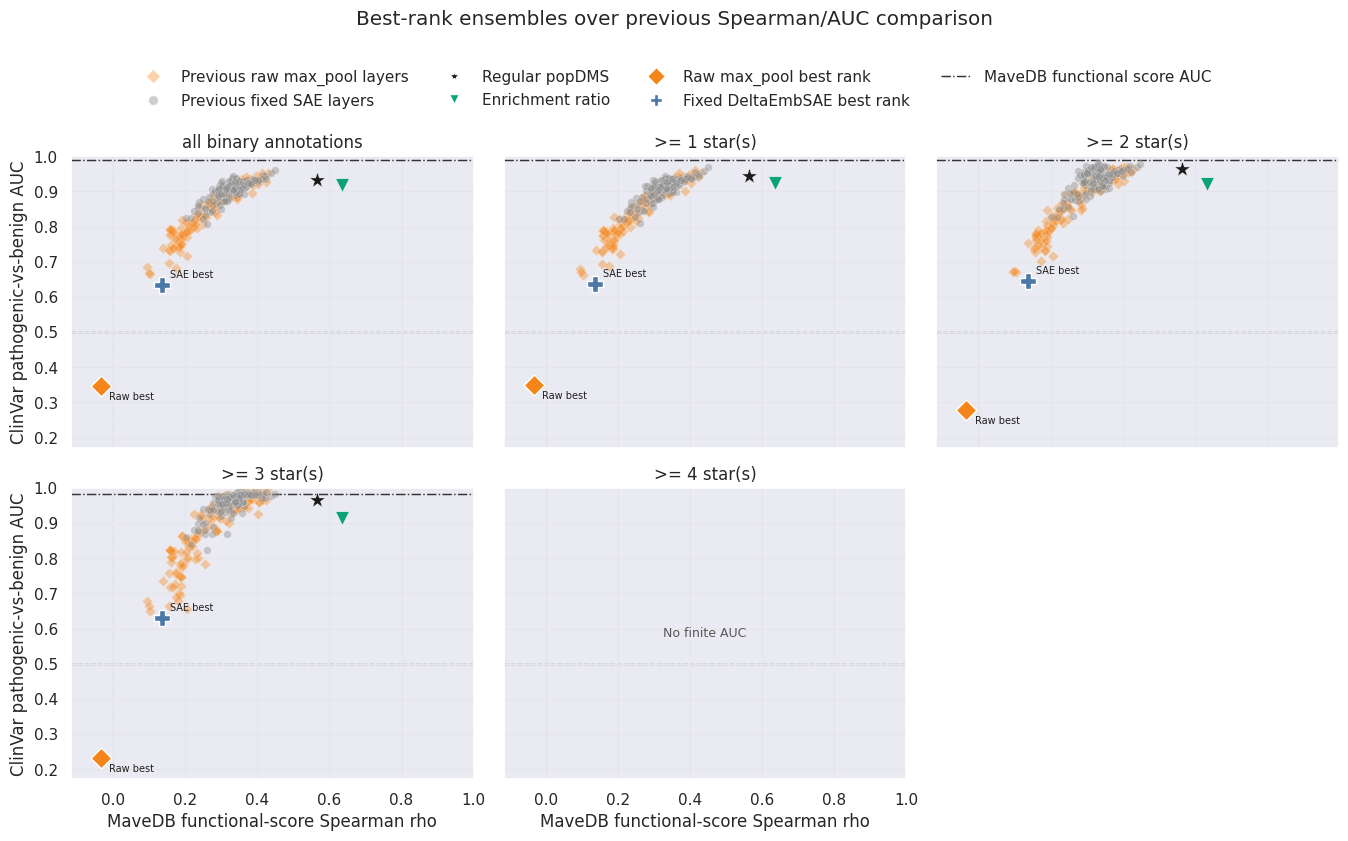

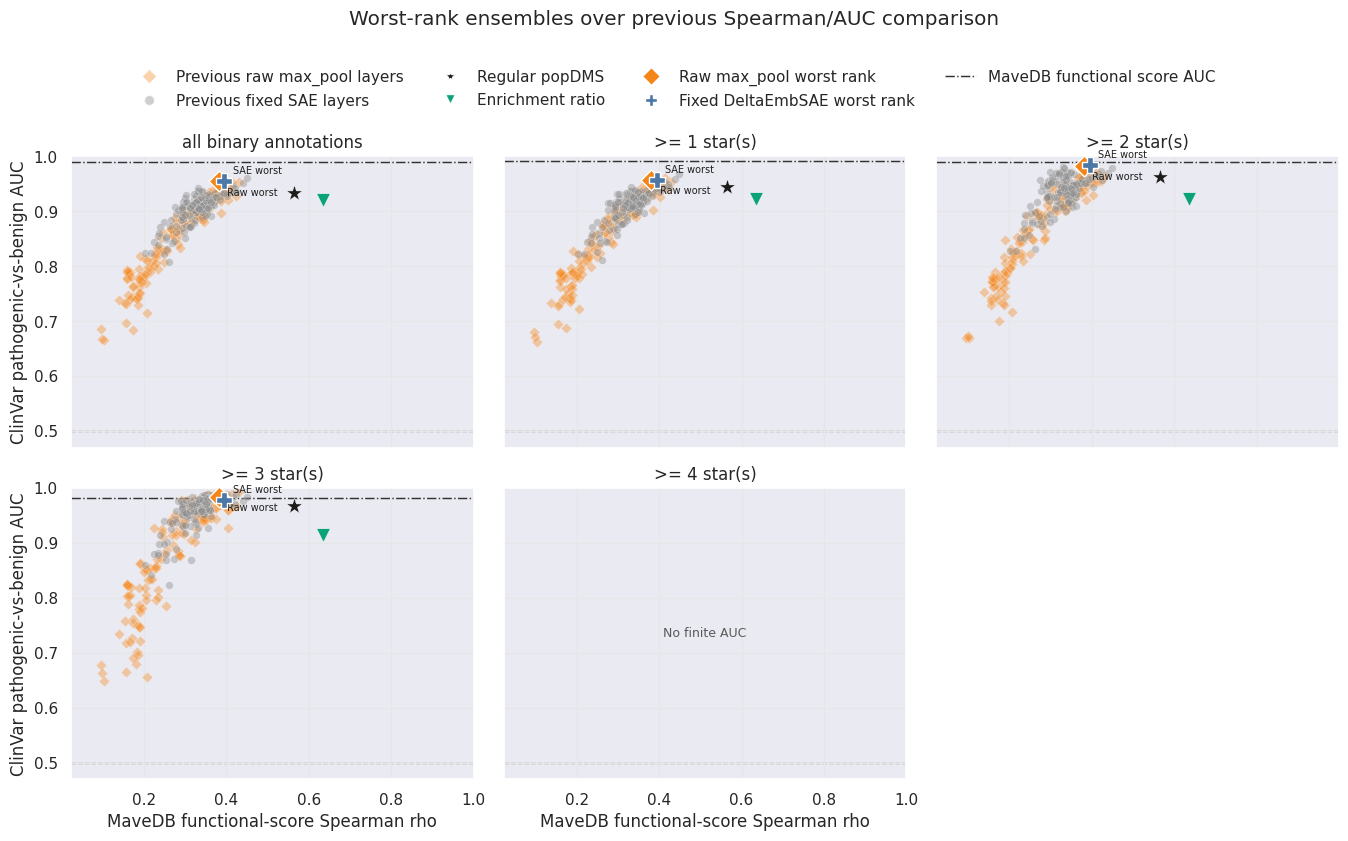

,review_filter,method_label,aggregation,n_component_model_layers,spearman_rho,auc,functional_score_auc,n_variants
0,all binary annotations,Raw max_pool best rank,best_rank,147,-0.034,0.347,0.989,496
1,all binary annotations,Fixed DeltaEmbSAE best rank,best_rank,147,0.136,0.635,0.989,496
2,all binary annotations,Raw max_pool worst rank,worst_rank,147,0.381,0.954,0.989,496
3,all binary annotations,Fixed DeltaEmbSAE worst rank,worst_rank,147,0.395,0.956,0.989,496
4,>= 1 star(s),Raw max_pool best rank,best_rank,147,-0.034,0.349,0.991,491
5,>= 1 star(s),Fixed DeltaEmbSAE best rank,best_rank,147,0.136,0.638,0.991,491
6,>= 1 star(s),Raw max_pool worst rank,worst_rank,147,0.381,0.957,0.991,491
7,>= 1 star(s),Fixed DeltaEmbSAE worst rank,worst_rank,147,0.395,0.957,0.991,491
8,>= 2 star(s),Raw max_pool best rank,best_rank,147,-0.034,0.280,0.991,282
9,>= 2 star(s),Fixed DeltaEmbSAE best rank,best_rank,147,0.136,0.646,0.991,282


In [20]:
BEST_WORST_RANK_ENSEMBLE_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_best_worst_rank_ensemble_metrics_by_review_stars.csv"
BEST_RANK_ENSEMBLE_WITH_PREVIOUS_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_best_rank_ensemble_with_previous_spearman_auc_by_review_stars.png"
WORST_RANK_ENSEMBLE_WITH_PREVIOUS_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_worst_rank_ensemble_with_previous_spearman_auc_by_review_stars.png"
BEST_WORST_RANK_ENSEMBLE_FITNESS_DIR = TABLE_DIR / "best_worst_rank_ensemble_fitness"
BEST_WORST_RANK_ENSEMBLE_FITNESS_DIR.mkdir(parents=True, exist_ok=True)

required_best_worst_helpers = [
    "_load_ensemble_metrics_table",
    "_ensemble_source_rows",
    "_load_ensemble_fitness_series",
    "_ensemble_metrics_by_review_stars",
    "_plot_ensemble_with_previous",
    "_load_previous_metrics_for_combined_ensemble_plot",
]
missing_best_worst_helpers = [name for name in required_best_worst_helpers if name not in globals()]
if missing_best_worst_helpers:
    raise RuntimeError(
        "Run the average-rank and combined-with-previous plotting cells above before this cell. "
        f"Missing helper(s): {', '.join(missing_best_worst_helpers)}"
    )


def _best_worst_rank_fitness_dataframe(source_rows, rank_mode):
    if source_rows.empty:
        raise ValueError("No source rows were available for the requested best/worst rank ensemble.")
    score_series = [_load_ensemble_fitness_series(row) for _, row in source_rows.iterrows()]
    score_matrix = pd.concat(score_series, axis=1)
    rank_matrix = score_matrix.rank(method="average", ascending=True)
    if rank_mode == "best_rank":
        selected_rank = rank_matrix.max(axis=1, skipna=True)
    elif rank_mode == "worst_rank":
        selected_rank = rank_matrix.min(axis=1, skipna=True)
    else:
        raise ValueError(f"Unsupported rank_mode: {rank_mode}")
    average_score = score_matrix.mean(axis=1, skipna=True)
    n_components = score_matrix.notna().sum(axis=1)
    fitness_df = pd.DataFrame({
        "SequenceIndex": score_matrix.index.astype(str),
        "selected_rank": selected_rank.to_numpy(dtype=float),
        "average_score": average_score.to_numpy(dtype=float),
        "n_component_model_layers": n_components.to_numpy(dtype=int),
    })
    fitness_df = fitness_df[fitness_df["n_component_model_layers"].gt(0)].dropna(subset=["selected_rank", "average_score"]).copy()
    fitness_df = fitness_df.sort_values(["selected_rank", "average_score", "SequenceIndex"], ascending=[True, True, True]).reset_index(drop=True)
    fitness_df["fitness"] = np.arange(1, len(fitness_df) + 1, dtype=float)
    fitness_df[f"{rank_mode}_with_average_score_tiebreak"] = fitness_df["fitness"]
    return fitness_df[[
        "SequenceIndex",
        "fitness",
        f"{rank_mode}_with_average_score_tiebreak",
        "selected_rank",
        "average_score",
        "n_component_model_layers",
    ]], len(score_series)


best_worst_rank_source_metrics_df = _load_ensemble_metrics_table()
best_worst_rank_ensemble_specs = []
for rank_mode, rank_label in [("best_rank", "best rank"), ("worst_rank", "worst rank")]:
    for method_label, short_label, benchmark, method, filename_stem in [
        (f"Raw max_pool {rank_label}", f"Raw {rank_label.split()[0]}", "Raw embeddings", "raw ESM", f"raw_max_pool_{rank_mode}"),
        (f"Fixed DeltaEmbSAE {rank_label}", f"SAE {rank_label.split()[0]}", "Fixed DeltaEmbSAE", "DeltaEmbSAE", f"fixed_deltaembsae_{rank_mode}"),
    ]:
        source_rows = _ensemble_source_rows(best_worst_rank_source_metrics_df, benchmark=benchmark, method=method, embedding_type=EMBEDDING_TYPE)
        fitness_df, n_components = _best_worst_rank_fitness_dataframe(source_rows, rank_mode=rank_mode)
        fitness_path = BEST_WORST_RANK_ENSEMBLE_FITNESS_DIR / f"{filename_stem}_fitness.csv"
        fitness_df.to_csv(fitness_path, index=False)
        best_worst_rank_ensemble_specs.append({
            "method_label": method_label,
            "short_label": short_label,
            "benchmark": benchmark,
            "method": method,
            "embedding_type": EMBEDDING_TYPE,
            "aggregation": rank_mode,
            "model_filter": "all non-layer-0 model/layers",
            "n_component_model_layers": n_components,
            "fitness_df": fitness_df,
            "fitness_path": fitness_path,
        })

best_worst_rank_ensemble_metrics_by_review_stars_df = _ensemble_metrics_by_review_stars(best_worst_rank_ensemble_specs)
best_worst_rank_ensemble_metrics_by_review_stars_df.to_csv(BEST_WORST_RANK_ENSEMBLE_TABLE_PATH, index=False)

best_rank_marker_specs = {
    "Raw max_pool best rank": {"marker": "D", "size": 112, "color": "#f58518", "offset": (6, -10)},
    "Fixed DeltaEmbSAE best rank": {"marker": "P", "size": 135, "color": "#4c78a8", "offset": (6, 5)},
}
worst_rank_marker_specs = {
    "Raw max_pool worst rank": {"marker": "D", "size": 112, "color": "#f58518", "offset": (6, -10)},
    "Fixed DeltaEmbSAE worst rank": {"marker": "P", "size": 135, "color": "#4c78a8", "offset": (6, 5)},
}

previous_metrics_for_best_worst_rank_df = (
    previous_metrics_for_combined_ensemble_plot_df.copy()
    if "previous_metrics_for_combined_ensemble_plot_df" in globals()
    else _load_previous_metrics_for_combined_ensemble_plot()
)
best_rank_ensemble_for_combined_df = best_worst_rank_ensemble_metrics_by_review_stars_df[
    best_worst_rank_ensemble_metrics_by_review_stars_df["aggregation"].eq("best_rank")
].copy()
worst_rank_ensemble_for_combined_df = best_worst_rank_ensemble_metrics_by_review_stars_df[
    best_worst_rank_ensemble_metrics_by_review_stars_df["aggregation"].eq("worst_rank")
].copy()

best_rank_with_previous_fig = _plot_ensemble_with_previous(
    previous_metrics_for_best_worst_rank_df,
    best_rank_ensemble_for_combined_df,
    BEST_RANK_ENSEMBLE_WITH_PREVIOUS_FIGURE_PATH,
    "Best-rank ensembles over previous Spearman/AUC comparison",
    best_rank_marker_specs,
)
if best_rank_with_previous_fig is not None:
    plt.show()

worst_rank_with_previous_fig = _plot_ensemble_with_previous(
    previous_metrics_for_best_worst_rank_df,
    worst_rank_ensemble_for_combined_df,
    WORST_RANK_ENSEMBLE_WITH_PREVIOUS_FIGURE_PATH,
    "Worst-rank ensembles over previous Spearman/AUC comparison",
    worst_rank_marker_specs,
)
if worst_rank_with_previous_fig is not None:
    plt.show()

display(
    best_worst_rank_ensemble_metrics_by_review_stars_df[
        ["review_filter", "method_label", "aggregation", "n_component_model_layers", "spearman_rho", "auc", "functional_score_auc", "n_variants"]
    ].assign(
        spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
        auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
        functional_score_auc=lambda df: pd.to_numeric(df["functional_score_auc"], errors="coerce").round(3),
    )
)


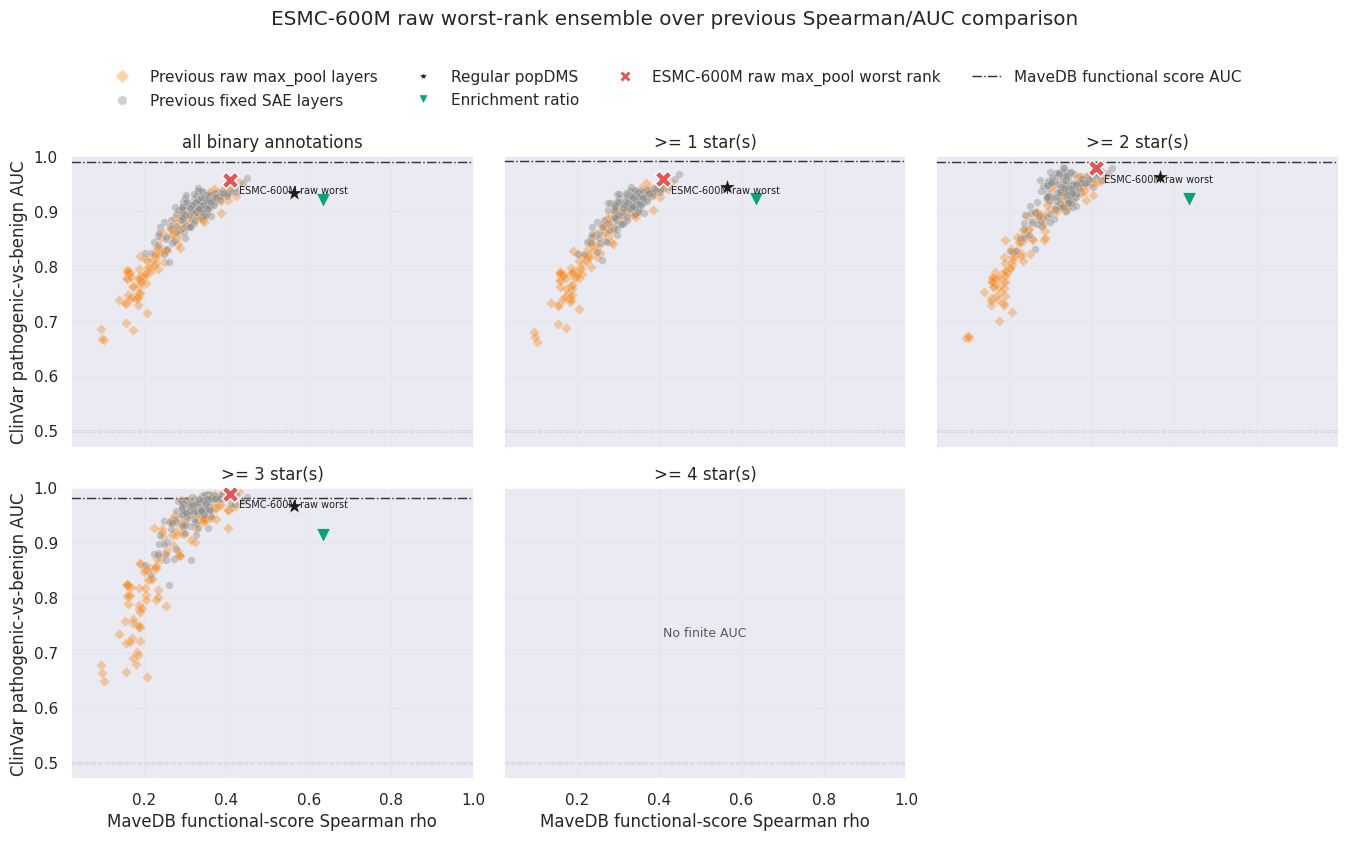

,review_filter,method_label,model_filter,n_component_model_layers,spearman_rho,auc,functional_score_auc,n_variants
0,all binary annotations,ESMC-600M raw max_pool worst rank,ESMC-600M non-layer-0 raw max_pool layers,36,0.41,0.957,0.989,496
1,>= 1 star(s),ESMC-600M raw max_pool worst rank,ESMC-600M non-layer-0 raw max_pool layers,36,0.41,0.958,0.991,491
2,>= 2 star(s),ESMC-600M raw max_pool worst rank,ESMC-600M non-layer-0 raw max_pool layers,36,0.41,0.978,0.991,282
3,>= 3 star(s),ESMC-600M raw max_pool worst rank,ESMC-600M non-layer-0 raw max_pool layers,36,0.41,0.989,0.982,132
4,>= 4 star(s),ESMC-600M raw max_pool worst rank,ESMC-600M non-layer-0 raw max_pool layers,36,0.41,NaN,NaN,0


In [21]:
ESMC_600M_WORST_RAW_RANK_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_esmc_600m_worst_raw_rank_metrics_by_review_stars.csv"
ESMC_600M_WORST_RAW_RANK_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_esmc_600m_worst_raw_rank_with_previous_spearman_auc_by_review_stars.png"
ESMC_600M_WORST_RAW_RANK_FITNESS_PATH = TABLE_DIR / "best_worst_rank_ensemble_fitness" / "esmc_600m_raw_max_pool_worst_rank_fitness.csv"
ESMC_600M_WORST_RAW_RANK_FITNESS_PATH.parent.mkdir(parents=True, exist_ok=True)

required_esmc_600m_worst_helpers = [
    "_load_ensemble_metrics_table",
    "_ensemble_source_rows",
    "_best_worst_rank_fitness_dataframe",
    "_ensemble_metrics_by_review_stars",
    "_plot_ensemble_with_previous",
    "_load_previous_metrics_for_combined_ensemble_plot",
]
missing_esmc_600m_worst_helpers = [name for name in required_esmc_600m_worst_helpers if name not in globals()]
if missing_esmc_600m_worst_helpers:
    raise RuntimeError(
        "Run the average-rank, combined-with-previous, and best/worst rank cells above before this cell. "
        f"Missing helper(s): {', '.join(missing_esmc_600m_worst_helpers)}"
    )

esmc_600m_worst_source_metrics_df = _load_ensemble_metrics_table()
esmc_600m_worst_raw_source_rows = _ensemble_source_rows(
    esmc_600m_worst_source_metrics_df,
    benchmark="Raw embeddings",
    method="raw ESM",
    embedding_type=EMBEDDING_TYPE,
)
esmc_600m_worst_raw_source_rows = esmc_600m_worst_raw_source_rows[
    esmc_600m_worst_raw_source_rows["model_short"].eq("ESMC-600M")
].copy()

esmc_600m_worst_raw_fitness_df, esmc_600m_worst_raw_n_components = _best_worst_rank_fitness_dataframe(
    esmc_600m_worst_raw_source_rows,
    rank_mode="worst_rank",
)
esmc_600m_worst_raw_fitness_df.to_csv(ESMC_600M_WORST_RAW_RANK_FITNESS_PATH, index=False)
esmc_600m_worst_raw_rank_specs = [{
    "method_label": "ESMC-600M raw max_pool worst rank",
    "short_label": "ESMC-600M raw worst",
    "benchmark": "Raw embeddings",
    "method": "raw ESM",
    "embedding_type": EMBEDDING_TYPE,
    "aggregation": "worst_rank",
    "model_filter": "ESMC-600M non-layer-0 raw max_pool layers",
    "n_component_model_layers": esmc_600m_worst_raw_n_components,
    "fitness_df": esmc_600m_worst_raw_fitness_df,
    "fitness_path": ESMC_600M_WORST_RAW_RANK_FITNESS_PATH,
}]
esmc_600m_worst_raw_rank_metrics_by_review_stars_df = _ensemble_metrics_by_review_stars(esmc_600m_worst_raw_rank_specs)
esmc_600m_worst_raw_rank_metrics_by_review_stars_df.to_csv(ESMC_600M_WORST_RAW_RANK_TABLE_PATH, index=False)

esmc_600m_worst_raw_marker_specs = {
    "ESMC-600M raw max_pool worst rank": {"marker": "X", "size": 145, "color": "#e45756", "offset": (6, -10)},
}
previous_metrics_for_esmc_600m_worst_raw_df = (
    previous_metrics_for_combined_ensemble_plot_df.copy()
    if "previous_metrics_for_combined_ensemble_plot_df" in globals()
    else _load_previous_metrics_for_combined_ensemble_plot()
)
esmc_600m_worst_raw_fig = _plot_ensemble_with_previous(
    previous_metrics_for_esmc_600m_worst_raw_df,
    esmc_600m_worst_raw_rank_metrics_by_review_stars_df,
    ESMC_600M_WORST_RAW_RANK_FIGURE_PATH,
    "ESMC-600M raw worst-rank ensemble over previous Spearman/AUC comparison",
    esmc_600m_worst_raw_marker_specs,
)
if esmc_600m_worst_raw_fig is not None:
    plt.show()

display(
    esmc_600m_worst_raw_rank_metrics_by_review_stars_df[
        ["review_filter", "method_label", "model_filter", "n_component_model_layers", "spearman_rho", "auc", "functional_score_auc", "n_variants"]
    ].assign(
        spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
        auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
        functional_score_auc=lambda df: pd.to_numeric(df["functional_score_auc"], errors="coerce").round(3),
    )
)


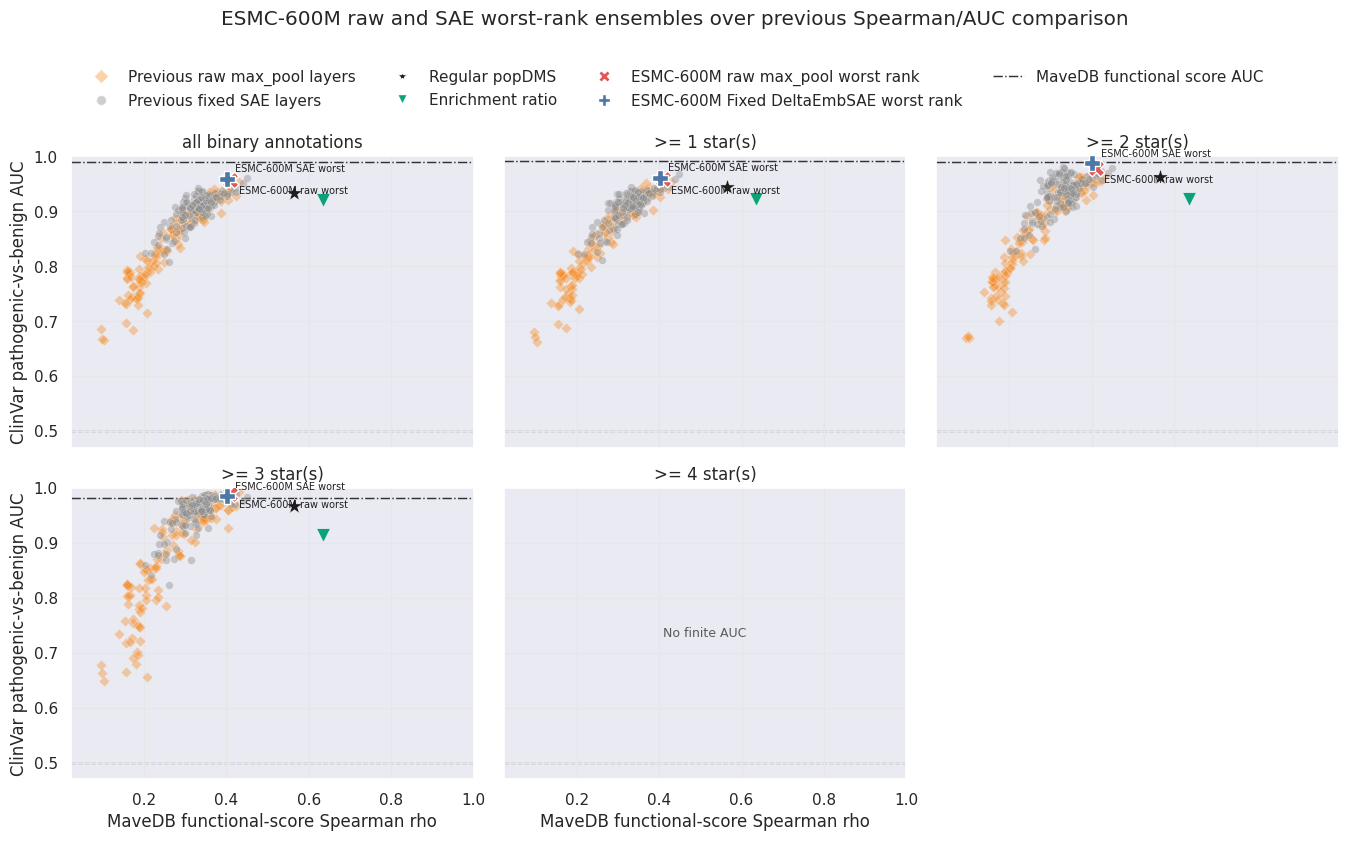

,review_filter,method_label,model_filter,n_component_model_layers,spearman_rho,auc,functional_score_auc,n_variants
0,all binary annotations,ESMC-600M raw max_pool worst rank,ESMC-600M non-layer-0 model/layers,36,0.410,0.957,0.989,496
1,all binary annotations,ESMC-600M Fixed DeltaEmbSAE worst rank,ESMC-600M non-layer-0 model/layers,36,0.401,0.959,0.989,496
2,>= 1 star(s),ESMC-600M raw max_pool worst rank,ESMC-600M non-layer-0 model/layers,36,0.410,0.958,0.991,491
3,>= 1 star(s),ESMC-600M Fixed DeltaEmbSAE worst rank,ESMC-600M non-layer-0 model/layers,36,0.401,0.961,0.991,491
4,>= 2 star(s),ESMC-600M raw max_pool worst rank,ESMC-600M non-layer-0 model/layers,36,0.410,0.978,0.991,282
5,>= 2 star(s),ESMC-600M Fixed DeltaEmbSAE worst rank,ESMC-600M non-layer-0 model/layers,36,0.401,0.987,0.991,282
6,>= 3 star(s),ESMC-600M raw max_pool worst rank,ESMC-600M non-layer-0 model/layers,36,0.410,0.989,0.982,132
7,>= 3 star(s),ESMC-600M Fixed DeltaEmbSAE worst rank,ESMC-600M non-layer-0 model/layers,36,0.401,0.985,0.982,132
8,>= 4 star(s),ESMC-600M raw max_pool worst rank,ESMC-600M non-layer-0 model/layers,36,0.410,NaN,NaN,0
9,>= 4 star(s),ESMC-600M Fixed DeltaEmbSAE worst rank,ESMC-600M non-layer-0 model/layers,36,0.401,NaN,NaN,0


In [22]:
ESMC_600M_WORST_RAW_SAE_RANK_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_esmc_600m_worst_raw_sae_rank_metrics_by_review_stars.csv"
ESMC_600M_WORST_RAW_SAE_RANK_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_esmc_600m_worst_raw_sae_rank_with_previous_spearman_auc_by_review_stars.png"
ESMC_600M_WORST_RAW_SAE_RANK_FITNESS_DIR = TABLE_DIR / "best_worst_rank_ensemble_fitness"
ESMC_600M_WORST_RAW_SAE_RANK_FITNESS_DIR.mkdir(parents=True, exist_ok=True)

required_esmc_600m_worst_raw_sae_helpers = [
    "_load_ensemble_metrics_table",
    "_ensemble_source_rows",
    "_best_worst_rank_fitness_dataframe",
    "_ensemble_metrics_by_review_stars",
    "_plot_ensemble_with_previous",
    "_load_previous_metrics_for_combined_ensemble_plot",
]
missing_esmc_600m_worst_raw_sae_helpers = [name for name in required_esmc_600m_worst_raw_sae_helpers if name not in globals()]
if missing_esmc_600m_worst_raw_sae_helpers:
    raise RuntimeError(
        "Run the average-rank, combined-with-previous, and best/worst rank cells above before this cell. "
        f"Missing helper(s): {', '.join(missing_esmc_600m_worst_raw_sae_helpers)}"
    )

esmc_600m_worst_raw_sae_source_metrics_df = _load_ensemble_metrics_table()
esmc_600m_worst_raw_sae_specs = []
for method_label, short_label, benchmark, method, filename_stem in [
    ("ESMC-600M raw max_pool worst rank", "ESMC-600M raw worst", "Raw embeddings", "raw ESM", "esmc_600m_raw_max_pool_worst_rank"),
    ("ESMC-600M Fixed DeltaEmbSAE worst rank", "ESMC-600M SAE worst", "Fixed DeltaEmbSAE", "DeltaEmbSAE", "esmc_600m_fixed_deltaembsae_worst_rank"),
]:
    source_rows = _ensemble_source_rows(
        esmc_600m_worst_raw_sae_source_metrics_df,
        benchmark=benchmark,
        method=method,
        embedding_type=EMBEDDING_TYPE,
    )
    source_rows = source_rows[source_rows["model_short"].eq("ESMC-600M")].copy()
    fitness_df, n_components = _best_worst_rank_fitness_dataframe(source_rows, rank_mode="worst_rank")
    fitness_path = ESMC_600M_WORST_RAW_SAE_RANK_FITNESS_DIR / f"{filename_stem}_fitness.csv"
    fitness_df.to_csv(fitness_path, index=False)
    esmc_600m_worst_raw_sae_specs.append({
        "method_label": method_label,
        "short_label": short_label,
        "benchmark": benchmark,
        "method": method,
        "embedding_type": EMBEDDING_TYPE,
        "aggregation": "worst_rank",
        "model_filter": "ESMC-600M non-layer-0 model/layers",
        "n_component_model_layers": n_components,
        "fitness_df": fitness_df,
        "fitness_path": fitness_path,
    })

esmc_600m_worst_raw_sae_rank_metrics_by_review_stars_df = _ensemble_metrics_by_review_stars(esmc_600m_worst_raw_sae_specs)
esmc_600m_worst_raw_sae_rank_metrics_by_review_stars_df.to_csv(ESMC_600M_WORST_RAW_SAE_RANK_TABLE_PATH, index=False)

esmc_600m_worst_raw_sae_marker_specs = {
    "ESMC-600M raw max_pool worst rank": {"marker": "X", "size": 145, "color": "#e45756", "offset": (6, -10)},
    "ESMC-600M Fixed DeltaEmbSAE worst rank": {"marker": "P", "size": 145, "color": "#4c78a8", "offset": (6, 5)},
}
previous_metrics_for_esmc_600m_worst_raw_sae_df = (
    previous_metrics_for_combined_ensemble_plot_df.copy()
    if "previous_metrics_for_combined_ensemble_plot_df" in globals()
    else _load_previous_metrics_for_combined_ensemble_plot()
)
esmc_600m_worst_raw_sae_fig = _plot_ensemble_with_previous(
    previous_metrics_for_esmc_600m_worst_raw_sae_df,
    esmc_600m_worst_raw_sae_rank_metrics_by_review_stars_df,
    ESMC_600M_WORST_RAW_SAE_RANK_FIGURE_PATH,
    "ESMC-600M raw and SAE worst-rank ensembles over previous Spearman/AUC comparison",
    esmc_600m_worst_raw_sae_marker_specs,
)
if esmc_600m_worst_raw_sae_fig is not None:
    plt.show()

display(
    esmc_600m_worst_raw_sae_rank_metrics_by_review_stars_df[
        ["review_filter", "method_label", "model_filter", "n_component_model_layers", "spearman_rho", "auc", "functional_score_auc", "n_variants"]
    ].assign(
        spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
        auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
        functional_score_auc=lambda df: pd.to_numeric(df["functional_score_auc"], errors="coerce").round(3),
    )
)


## Best SAE With Shuffled-Frequency Inference (Control)

This control re-runs popDMS inference for the single best fixed DeltaEmbSAE model/layer (the one with the highest ClinVar pathogenic-vs-benign AUC), but with the per-variant frequencies **completely shuffled within each timepoint**. Concretely, within every (replicate, generation) the `Frequency` values are randomly permuted among variants, so each variant is assigned a random abundance while each timepoint's frequency histogram and the per-timepoint normalization $w_\alpha = f_\alpha / \sum_\beta f_\beta$ are left unchanged.

This breaks the link between a variant's identity (its SAE feature vector) and its measured abundance trajectory, so it isolates how much of the SAE's apparent performance actually depends on the real frequency dynamics rather than on the geometry of the feature space alone. The figure reproduces the previous plot (ESMC-600M raw and SAE worst-rank ensembles over the previous Spearman/AUC comparison) and adds the shuffled-frequency best-SAE control as a single point.

Best fixed DeltaEmbSAE: ESMC-600M Layer_36 (ClinVar AUC=0.961, MaveDB Spearman=0.449)
Loaded cached shuffled-frequency control fitness from /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/best_sae_shuffled_frequency_control/best_sae_shuffled_frequency_control_seed42_fitness.csv


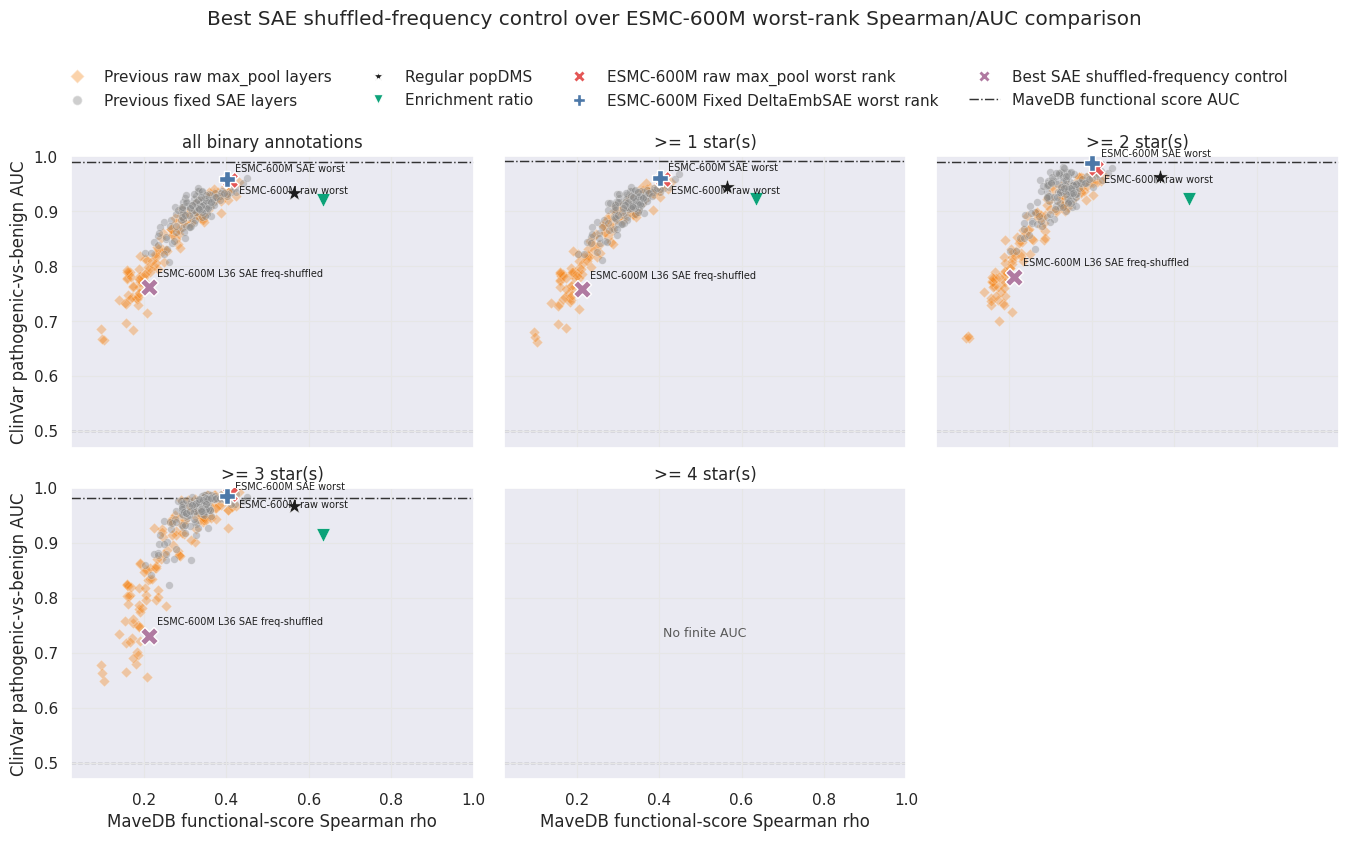

,review_filter,method_label,short_label,model_filter,spearman_rho,auc,functional_score_auc,n_variants
0,all binary annotations,Best SAE shuffled-frequency control,ESMC-600M L36 SAE freq-shuffled,best fixed SAE (ESMC-600M Layer_36); frequenci...,0.212,0.762,0.989,496
1,>= 1 star(s),Best SAE shuffled-frequency control,ESMC-600M L36 SAE freq-shuffled,best fixed SAE (ESMC-600M Layer_36); frequenci...,0.212,0.758,0.991,491
2,>= 2 star(s),Best SAE shuffled-frequency control,ESMC-600M L36 SAE freq-shuffled,best fixed SAE (ESMC-600M Layer_36); frequenci...,0.212,0.781,0.991,282
3,>= 3 star(s),Best SAE shuffled-frequency control,ESMC-600M L36 SAE freq-shuffled,best fixed SAE (ESMC-600M Layer_36); frequenci...,0.212,0.731,0.982,132
4,>= 4 star(s),Best SAE shuffled-frequency control,ESMC-600M L36 SAE freq-shuffled,best fixed SAE (ESMC-600M Layer_36); frequenci...,0.212,NaN,NaN,0


In [23]:
from popDMS import mini_infer_esm

# Best fixed DeltaEmbSAE model/layer, re-scored with popDMS inference run on
# frequencies that are completely shuffled WITHIN each timepoint: inside every
# (replicate, generation) the per-variant Frequency values are randomly permuted
# among variants. Each timepoint's frequency histogram / normalization is kept,
# but the variant-identity <-> abundance link is destroyed (negative control).
SHUFFLED_FREQ_CONTROL_SEED = 42
FORCE_RECOMPUTE_SHUFFLED_FREQ_CONTROL = False
SHUFFLED_FREQ_CONTROL_FITNESS_DIR = TABLE_DIR / "best_sae_shuffled_frequency_control"
SHUFFLED_FREQ_CONTROL_FITNESS_DIR.mkdir(parents=True, exist_ok=True)
SHUFFLED_FREQ_CONTROL_FITNESS_PATH = SHUFFLED_FREQ_CONTROL_FITNESS_DIR / f"best_sae_shuffled_frequency_control_seed{SHUFFLED_FREQ_CONTROL_SEED}_fitness.csv"
SHUFFLED_FREQ_CONTROL_TABLE_PATH = TABLE_DIR / "BRCA1_plm_layer_best_sae_shuffled_frequency_control_metrics_by_review_stars.csv"
SHUFFLED_FREQ_CONTROL_FIGURE_PATH = FIGURE_DIR / "BRCA1_plm_layer_best_sae_shuffled_frequency_control_spearman_auc_by_review_stars.png"

required_shuffled_control_helpers = [
    "_load_ensemble_metrics_table",
    "_ensemble_metrics_by_review_stars",
    "_plot_ensemble_with_previous",
    "_fitness_for_feature_mapping",
    "esmc_600m_worst_raw_sae_rank_metrics_by_review_stars_df",
    "esmc_600m_worst_raw_sae_marker_specs",
    "previous_metrics_for_esmc_600m_worst_raw_sae_df",
]
missing_shuffled_control_helpers = [name for name in required_shuffled_control_helpers if name not in globals()]
if missing_shuffled_control_helpers:
    raise RuntimeError(
        "Run the benchmark, ensemble, and ESMC-600M worst-rank cells above before this control cell. "
        f"Missing: {', '.join(missing_shuffled_control_helpers)}"
    )


def _best_fixed_sae_benchmark_row():
    metrics_df = _load_ensemble_metrics_table()
    fixed_df = metrics_df[
        metrics_df["benchmark"].eq("Fixed DeltaEmbSAE")
        & metrics_df["method"].eq("DeltaEmbSAE")
        & metrics_df["embedding_type"].eq(EMBEDDING_TYPE)
        & np.isfinite(metrics_df["auc"])
    ].copy()
    if fixed_df.empty:
        raise RuntimeError("No Fixed DeltaEmbSAE benchmark rows are available to select the best SAE.")
    return fixed_df.sort_values(["auc", "spearman_rho"], ascending=[False, False]).iloc[0]


def _shuffle_frequencies_within_timepoints(sequence_dataframe, seed):
    rng = np.random.default_rng(seed)
    shuffled = sequence_dataframe.copy()
    shuffled["Frequency"] = (
        shuffled.groupby(["Replicate", "Generation"])["Frequency"]
        .transform(lambda values: rng.permutation(values.to_numpy()))
    )
    return shuffled


best_sae_row = _best_fixed_sae_benchmark_row()
best_sae_model_short = str(best_sae_row.get("model_short", ""))
best_sae_layer = int(pd.to_numeric(best_sae_row.get("layer"), errors="coerce"))
print(
    f"Best fixed DeltaEmbSAE: {best_sae_model_short} Layer_{best_sae_layer} "
    f"(ClinVar AUC={float(best_sae_row['auc']):.3f}, MaveDB Spearman={float(best_sae_row['spearman_rho']):.3f})"
)

if SHUFFLED_FREQ_CONTROL_FITNESS_PATH.is_file() and not FORCE_RECOMPUTE_SHUFFLED_FREQ_CONTROL:
    shuffled_control_fitness_df = pd.read_csv(SHUFFLED_FREQ_CONTROL_FITNESS_PATH)
    shuffled_control_fitness_df["SequenceIndex"] = shuffled_control_fitness_df["SequenceIndex"].astype(str)
    print(f"Loaded cached shuffled-frequency control fitness from {SHUFFLED_FREQ_CONTROL_FITNESS_PATH}")
else:
    best_sae_feature_path = _as_existing_path(best_sae_row.get("feature_path"))
    if best_sae_feature_path is None:
        raise FileNotFoundError(f"Missing SAE feature cache for the best SAE: {best_sae_row.get('feature_path')}")
    best_sae_seq_to_features = _load_pickle(best_sae_feature_path)
    aligned_sequence_dataframe, best_sae_seq_to_features = esmDMS._drop_missing_features(
        runner.sequence_dataframe, best_sae_seq_to_features, "Shuffled-frequency control"
    )
    esmDMS._require_vector_features(best_sae_seq_to_features, "Shuffled-frequency control")
    shuffled_sequence_dataframe = _shuffle_frequencies_within_timepoints(
        aligned_sequence_dataframe, SHUFFLED_FREQ_CONTROL_SEED
    )
    print(
        f"Running popDMS inference on shuffled frequencies "
        f"(feature dim {len(next(iter(best_sae_seq_to_features.values())))}); this can take several minutes..."
    )
    shuffled_inference_result = mini_infer_esm(shuffled_sequence_dataframe, best_sae_seq_to_features)
    shuffled_control_fitness_df = _fitness_for_feature_mapping(
        best_sae_seq_to_features, shuffled_inference_result, annotation_map={}, norm_scheme=NORM_SCHEME
    )[["SequenceIndex", "fitness"]]
    shuffled_control_fitness_df.to_csv(SHUFFLED_FREQ_CONTROL_FITNESS_PATH, index=False)

shuffled_control_specs = [{
    "method_label": "Best SAE shuffled-frequency control",
    "short_label": f"{best_sae_model_short} L{best_sae_layer} SAE freq-shuffled",
    "benchmark": "Fixed DeltaEmbSAE",
    "method": "DeltaEmbSAE",
    "embedding_type": EMBEDDING_TYPE,
    "aggregation": "shuffled_frequency_control",
    "model_filter": (
        f"best fixed SAE ({best_sae_model_short} Layer_{best_sae_layer}); frequencies shuffled "
        f"within each replicate x generation (seed={SHUFFLED_FREQ_CONTROL_SEED})"
    ),
    "n_component_model_layers": 1,
    "fitness_df": shuffled_control_fitness_df,
    "fitness_path": SHUFFLED_FREQ_CONTROL_FITNESS_PATH,
}]
shuffled_control_metrics_by_review_stars_df = _ensemble_metrics_by_review_stars(shuffled_control_specs)
shuffled_control_metrics_by_review_stars_df.to_csv(SHUFFLED_FREQ_CONTROL_TABLE_PATH, index=False)

# Copy the previous (last) plot and add the shuffled-frequency best-SAE control dot.
shuffled_control_marker_specs = dict(esmc_600m_worst_raw_sae_marker_specs)
shuffled_control_marker_specs["Best SAE shuffled-frequency control"] = {
    "marker": "X", "size": 170, "color": "#b07aa1", "offset": (6, 8)
}
shuffled_control_ensemble_df = pd.concat(
    [esmc_600m_worst_raw_sae_rank_metrics_by_review_stars_df, shuffled_control_metrics_by_review_stars_df],
    ignore_index=True,
    sort=False,
)
shuffled_control_fig = _plot_ensemble_with_previous(
    previous_metrics_for_esmc_600m_worst_raw_sae_df,
    shuffled_control_ensemble_df,
    SHUFFLED_FREQ_CONTROL_FIGURE_PATH,
    "Best SAE shuffled-frequency control over ESMC-600M worst-rank Spearman/AUC comparison",
    shuffled_control_marker_specs,
)
if shuffled_control_fig is not None:
    plt.show()

display(
    shuffled_control_metrics_by_review_stars_df[
        ["review_filter", "method_label", "short_label", "model_filter", "spearman_rho", "auc", "functional_score_auc", "n_variants"]
    ].assign(
        spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
        auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
        functional_score_auc=lambda df: pd.to_numeric(df["functional_score_auc"], errors="coerce").round(3),
    )
)